In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [12]:
from pathlib import Path

DATA_PATH = Path("/content/microbiology_cultures_cohort.csv")

print("Dataset will be loaded from:")
print(DATA_PATH)

Dataset will be loaded from:
/content/microbiology_cultures_cohort.csv


In [13]:
if DATA_PATH.exists():
    print(" Dataset found successfully!")
else:
    print(" Dataset not found!")

❌ Dataset not found!


In [14]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'doi_10_5061_dryad_jq2bvq8kp__v20251022.zip', 'sample_data']


In [15]:
import zipfile
from pathlib import Path

ZIP_PATH = Path("/content/doi_10_5061_dryad_jq2bvq8kp__v20251022.zip")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_file:
    matches = [
        name for name in zip_file.namelist()
        if "microbiology_cultures_cohort.csv" in name
    ]

print("Found files:")
for file in matches:
    print(file)

Found files:
microbiology_cultures_cohort.csv


In [16]:
import zipfile
from pathlib import Path

ZIP_PATH = Path("/content/doi_10_5061_dryad_jq2bvq8kp__v20251022.zip")
DATA_PATH = Path("/content/microbiology_cultures_cohort.csv")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_file:
    zip_file.extract("microbiology_cultures_cohort.csv", "/content")

print("Extracted successfully!")
print("File exists:", DATA_PATH.exists())

Extracted successfully!
File exists: True


In [17]:
import os

size_mb = os.path.getsize(DATA_PATH) / (1024 * 1024)

print(f"File size: {size_mb:.2f} MB")

File size: 245.11 MB


In [18]:
sample = pd.read_csv(DATA_PATH, nrows=5)

sample

,anon_id,pat_enc_csn_id_coded,order_proc_id_coded,order_time_jittered_utc,ordering_mode,culture_description,was_positive,organism,antibiotic,susceptibility
0,JC2744063,131368600230,928257722,2023-12-23 22:29:00+00:00,Inpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ertapenem,Susceptible
1,JC1713666,131300064625,697566032,2020-12-27 00:40:00+00:00,Inpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ertapenem,Susceptible
2,JC1669304,131272997044,620809641,2019-07-02 19:54:00+00:00,Inpatient,BLOOD,1,KLEBSIELLA PNEUMONIAE,Ertapenem,Susceptible
3,JC1697441,131208305006,510635146,2016-12-01 13:59:00+00:00,Inpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ertapenem,Susceptible
4,JC600786,131344486993,834128837,2022-11-18 19:35:00+00:00,Outpatient,URINE,1,KLEBSIELLA PNEUMONIAE,Ertapenem,Susceptible


In [19]:
print(sample.columns.tolist())

['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'order_time_jittered_utc', 'ordering_mode', 'culture_description', 'was_positive', 'organism', 'antibiotic', 'susceptibility']


In [20]:
dtype_map = {
    "anon_id": "string",
    "pat_enc_csn_id_coded": "string",
    "order_proc_id_coded": "string",
    "ordering_mode": "category",
    "culture_description": "category",
    "was_positive": "Int8",
    "organism": "category",
    "antibiotic": "category",
    "susceptibility": "category"
}

df = pd.read_csv(
    DATA_PATH,
    dtype=dtype_map,
    low_memory=False
)

print(" Full dataset loaded successfully!")

print("\nShape:")
print(df.shape)

print("\nMemory usage:")
print(f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

✅ Full dataset loaded successfully!

Shape:
(2241050, 10)

Memory usage:
552.50 MB


In [21]:
print("Unique patients:")
print(df["anon_id"].nunique())

print("\nUnique cultures:")
print(df["order_proc_id_coded"].nunique())

print("\nSusceptibility results:")
print(df["susceptibility"].value_counts(dropna=False))

print("\nCulture types:")
print(df["culture_description"].value_counts().head(15))

print("\nMost common organisms:")
print(df["organism"].value_counts().head(15))

Unique patients:
283715

Unique cultures:
751075

Susceptibility results:
susceptibility
Susceptible     1289258
Null             634468
Resistant        265071
Intermediate      47651
Inconclusive       2670
Synergism          1932
Name: count, dtype: int64

Culture types:
culture_description
URINE          1516950
BLOOD           435774
RESPIRATORY     288326
Name: count, dtype: int64

Most common organisms:
organism
ESCHERICHIA COLI                          874897
Null                                      632308
KLEBSIELLA PNEUMONIAE                     151964
STAPHYLOCOCCUS AUREUS                      82519
PROTEUS MIRABILIS                          67938
ENTEROCOCCUS SPECIES                       64511
PSEUDOMONAS AERUGINOSA                     48959
MUCOID PSEUDOMONAS AERUGINOSA              33037
KLEBSIELLA OXYTOCA                         25066
ENTEROBACTER CLOACAE COMPLEX               24042
COAG NEGATIVE STAPHYLOCOCCUS               20866
STAPH AUREUS {MRSA}                   

In [22]:
ecoli_urine = df[
    (df["culture_description"] == "URINE") &
    (df["was_positive"] == 1) &
    (df["organism"] == "ESCHERICHIA COLI") &
    (df["susceptibility"].isin(["Susceptible", "Resistant"]))
].copy()

print(" E. coli urine cohort created")

print("\nAST rows:")
print(len(ecoli_urine))

print("\nUnique patients:")
print(ecoli_urine["anon_id"].nunique())

print("\nUnique cultures:")
print(ecoli_urine["order_proc_id_coded"].nunique())

print("\nUnique antibiotics:")
print(ecoli_urine["antibiotic"].nunique())

print("\nSusceptibility distribution:")
print(ecoli_urine["susceptibility"].value_counts())

 E. coli urine cohort created

AST rows:
791859

Unique patients:
37101

Unique cultures:
57482

Unique antibiotics:
37

Susceptibility distribution:
susceptibility
Susceptible     681319
Resistant       110540
Intermediate         0
Inconclusive         0
Null                 0
Synergism            0
Name: count, dtype: int64


In [23]:
cultures_per_patient = (
    ecoli_urine[
        ["anon_id", "order_proc_id_coded"]
    ]
    .drop_duplicates()
    .groupby("anon_id")
    .size()
)

print("Total patients:")
print(len(cultures_per_patient))

print("\nPatients with >= 2 E. coli urine cultures:")
print((cultures_per_patient >= 2).sum())

print("\nPatients with >= 3 cultures:")
print((cultures_per_patient >= 3).sum())

print("\nPatients with >= 4 cultures:")
print((cultures_per_patient >= 4).sum())

print("\nPatients with >= 5 cultures:")
print((cultures_per_patient >= 5).sum())

print("\nCulture count statistics:")
print(cultures_per_patient.describe())

Total patients:
37101

Patients with >= 2 E. coli urine cultures:
9311

Patients with >= 3 cultures:
4016

Patients with >= 4 cultures:
2131

Patients with >= 5 cultures:
1297

Culture count statistics:
count    37101.000000
mean         1.549338
std          1.615065
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         54.000000
dtype: float64


In [25]:
# IDs of patients with at least 2 distinct E. coli urine cultures
recurrent_patient_ids = cultures_per_patient[
    cultures_per_patient >= 2
].index

recurrent_ecoli = ecoli_urine[
    ecoli_urine["anon_id"].isin(recurrent_patient_ids)
].copy()

print(" Recurrent E. coli cohort created")

print("\nPatients:")
print(recurrent_ecoli["anon_id"].nunique())

print("\nUnique cultures:")
print(recurrent_ecoli["order_proc_id_coded"].nunique())

print("\nAST rows:")
print(len(recurrent_ecoli))

 Recurrent E. coli cohort created

Patients:
9311

Unique cultures:
29692

AST rows:
412885


In [26]:
duplicate_mask = recurrent_ecoli.duplicated(
    subset=[
        "anon_id",
        "order_proc_id_coded",
        "antibiotic"
    ],
    keep=False
)

print("Rows involved in duplicated culture-antibiotic combinations:")
print(duplicate_mask.sum())

print("\nPercentage:")
print(f"{duplicate_mask.mean() * 100:.4f}%")

Rows involved in duplicated culture-antibiotic combinations:
1946

Percentage:
0.4713%


In [27]:
duplicate_check = (
    recurrent_ecoli
    .groupby(
        ["anon_id", "order_proc_id_coded", "antibiotic"],
        observed=True
    )["susceptibility"]
    .agg(
        number_of_rows="size",
        number_of_different_results="nunique"
    )
    .reset_index()
)

# Keep only combinations that occurred more than once
duplicate_check = duplicate_check[
    duplicate_check["number_of_rows"] > 1
]

print("Total duplicated culture-antibiotic combinations:")
print(len(duplicate_check))

print("\nDuplicated combinations with SAME susceptibility:")
print(
    (duplicate_check["number_of_different_results"] == 1).sum()
)

print("\nDuplicated combinations with CONFLICTING susceptibility:")
print(
    (duplicate_check["number_of_different_results"] > 1).sum()
)

Total duplicated culture-antibiotic combinations:
973

Duplicated combinations with SAME susceptibility:
0

Duplicated combinations with CONFLICTING susceptibility:
973


In [28]:
conflicting = duplicate_check[
    duplicate_check["number_of_different_results"] > 1
]

print("Number of conflicting combinations:")
print(len(conflicting))

conflicting.head(20)

Number of conflicting combinations:
973


,anon_id,order_proc_id_coded,antibiotic,number_of_rows,number_of_different_results
1025,JC1006540,508472230,Cefazolin,2,2
2080,JC1012161,924156654,Ampicillin,2,2
2435,JC1014881,420587286,Trimethoprim/Sulfamethoxazole,2,2
3609,JC1022451,732296277,Ampicillin,2,2
5865,JC1036903,592474215,Ertapenem,2,2
6684,JC1042389,885464447,Ampicillin,2,2
6821,JC1043197,796488379,Cefepime,2,2
7491,JC1049660,466988337,Cefazolin,2,2
7495,JC1049660,466988337,Ceftriaxone,2,2
7504,JC1049660,466988337,Trimethoprim/Sulfamethoxazole,2,2


In [29]:
conflict_by_antibiotic = (
    conflicting["antibiotic"]
    .value_counts()
    .reset_index()
)

conflict_by_antibiotic.columns = [
    "antibiotic",
    "conflicting_combinations"
]

print("Conflicting combinations by antibiotic:")
print(conflict_by_antibiotic.head(20))

Conflicting combinations by antibiotic:
                       antibiotic  conflicting_combinations
0   Trimethoprim/Sulfamethoxazole                       166
1                      Ampicillin                       149
2                       Cefazolin                       107
3                    Tetracycline                        82
4                   Ciprofloxacin                        80
5                     Ceftriaxone                        63
6                     Ceftazidime                        62
7                    Levofloxacin                        57
8                      Gentamicin                        57
9                  Nitrofurantoin                        25
10    Amoxicillin/Clavulanic Acid                        23
11        Piperacillin/Tazobactam                        20
12           Ampicillin/Sulbactam                        16
13                      Aztreonam                        15
14                       Cefepime                        14


In [30]:
print("\nNumber of rows per conflicting combination:")
print(
    conflicting["number_of_rows"]
    .value_counts()
    .sort_index()
)


Number of rows per conflicting combination:
number_of_rows
2    973
Name: count, dtype: int64


In [31]:
conflict_keys = conflicting[
    ["anon_id", "order_proc_id_coded", "antibiotic"]
].copy()

clean_recurrent = recurrent_ecoli.merge(
    conflict_keys.assign(is_conflict=1),
    on=["anon_id", "order_proc_id_coded", "antibiotic"],
    how="left"
)

clean_recurrent = clean_recurrent[
    clean_recurrent["is_conflict"].isna()
].drop(columns="is_conflict")

print("✅ Conflicting AST combinations removed")

print("\nRows before cleaning:")
print(len(recurrent_ecoli))

print("\nRows after cleaning:")
print(len(clean_recurrent))

print("\nRows removed:")
print(len(recurrent_ecoli) - len(clean_recurrent))

✅ Conflicting AST combinations removed

Rows before cleaning:
412885

Rows after cleaning:
410939

Rows removed:
1946


In [32]:
remaining_duplicates = clean_recurrent.duplicated(
    subset=[
        "anon_id",
        "order_proc_id_coded",
        "antibiotic"
    ],
    keep=False
).sum()

print("Remaining duplicated culture-antibiotic combinations:")
print(remaining_duplicates)

Remaining duplicated culture-antibiotic combinations:
0


In [33]:
antibiotic_summary = (
    clean_recurrent
    .groupby("antibiotic", observed=True)
    .agg(
        cultures=("order_proc_id_coded", "nunique"),
        patients=("anon_id", "nunique"),
        total_tests=("susceptibility", "size"),
        resistant=(
            "susceptibility",
            lambda x: (x == "Resistant").sum()
        ),
        susceptible=(
            "susceptibility",
            lambda x: (x == "Susceptible").sum()
        )
    )
    .reset_index()
)

antibiotic_summary["resistance_rate"] = (
    antibiotic_summary["resistant"]
    /
    (
        antibiotic_summary["resistant"]
        + antibiotic_summary["susceptible"]
    )
)

antibiotic_summary = antibiotic_summary.sort_values(
    "cultures",
    ascending=False
)

antibiotic_summary.head(25)

,antibiotic,cultures,patients,total_tests,resistant,susceptible,resistance_rate
22,Gentamicin,29561,9307,29561,3010,26551,0.101823
36,Trimethoprim/Sulfamethoxazole,29505,9311,29505,8912,20593,0.302050
17,Ciprofloxacin,29320,9296,29320,7773,21547,0.265109
2,Ampicillin,29085,9283,29085,13961,15124,0.480007
29,Nitrofurantoin,28869,9271,28869,663,28206,0.022966
5,Cefazolin,28838,9273,28838,4164,24674,0.144393
31,Piperacillin/Tazobactam,25588,8858,25588,523,25065,0.020439
24,Levofloxacin,25084,8066,25084,6618,18466,0.263834
14,Ceftriaxone,23111,8106,23111,3074,20037,0.133010
25,Meropenem,19955,7413,19955,2,19953,0.000100


In [34]:
clean_recurrent["order_time_jittered_utc"] = pd.to_datetime(
    clean_recurrent["order_time_jittered_utc"],
    errors="coerce",
    utc=True
)

print("Missing dates:")
print(clean_recurrent["order_time_jittered_utc"].isna().sum())

print("\nEarliest culture:")
print(clean_recurrent["order_time_jittered_utc"].min())

print("\nLatest culture:")
print(clean_recurrent["order_time_jittered_utc"].max())

Missing dates:
0

Earliest culture:
2008-01-23 01:16:00+00:00

Latest culture:
2024-01-28 03:55:00+00:00


In [35]:
ast_long = clean_recurrent[
    [
        "anon_id",
        "order_proc_id_coded",
        "order_time_jittered_utc",
        "ordering_mode",
        "antibiotic",
        "susceptibility"
    ]
].copy()

print(ast_long.shape)

ast_long.head()

(410939, 6)


,anon_id,order_proc_id_coded,order_time_jittered_utc,ordering_mode,antibiotic,susceptibility
0,JC796046,921140979,2023-10-29 22:19:00+00:00,Outpatient,Meropenem,Susceptible
1,JC2702503,650181708,2020-01-06 05:58:00+00:00,Inpatient,Meropenem,Susceptible
2,JC611931,547305271,2017-12-11 01:16:00+00:00,Outpatient,Meropenem,Susceptible
3,JC1041570,883863656,2023-06-26 21:11:00+00:00,Outpatient,Meropenem,Susceptible
4,JC642381,791301767,2022-05-20 21:20:00+00:00,Inpatient,Meropenem,Susceptible


In [36]:
ast_matrix = (
    ast_long
    .pivot(
        index=[
            "anon_id",
            "order_proc_id_coded",
            "order_time_jittered_utc"
        ],
        columns="antibiotic",
        values="susceptibility"
    )
    .reset_index()
)

print("AST matrix shape:")
print(ast_matrix.shape)

ast_matrix.head()

AST matrix shape:
(29692, 40)


antibiotic,anon_id,order_proc_id_coded,order_time_jittered_utc,Meropenem,Ampicillin,Cefuroxime,Fosfomycin,Gentamicin,Tobramycin,Ceftazidime,...,Minocycline,Ticacarcillin/Clavulanic Acid,Cephalexin/Cephalothin,Doripenem,Doxycycline,Piperacillin,Moxifloxacin,Cefpodoxime,Cefotaxime,Meropenem/Vaborbactam
0,JC1000083,364762539,2010-03-29 21:10:00+00:00,NaN,Resistant,NaN,NaN,Resistant,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,JC1000083,379081590,2011-02-18 22:25:00+00:00,NaN,Susceptible,NaN,NaN,Susceptible,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,JC1000083,384652929,2011-06-18 00:10:00+00:00,NaN,Susceptible,NaN,NaN,Susceptible,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,JC1000169,494269657,2016-04-27 23:50:00+00:00,Susceptible,Resistant,NaN,NaN,Susceptible,NaN,Susceptible,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,JC1000169,506588339,2016-09-20 00:39:00+00:00,Susceptible,Susceptible,NaN,NaN,Susceptible,Susceptible,Susceptible,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
candidate_antibiotics = [
    "Ampicillin",
    "Trimethoprim/Sulfamethoxazole",
    "Ciprofloxacin",
    "Cefazolin",
    "Ceftriaxone",
    "Gentamicin",
    "Tetracycline",
    "Nitrofurantoin"
]

print(candidate_antibiotics)

['Ampicillin', 'Trimethoprim/Sulfamethoxazole', 'Ciprofloxacin', 'Cefazolin', 'Ceftriaxone', 'Gentamicin', 'Tetracycline', 'Nitrofurantoin']


In [38]:
coverage = []

for antibiotic in candidate_antibiotics:
    if antibiotic in ast_matrix.columns:
        available = ast_matrix[antibiotic].notna().sum()
        total = len(ast_matrix)

        coverage.append({
            "antibiotic": antibiotic,
            "cultures_with_result": available,
            "total_cultures": total,
            "coverage_percent": (available / total) * 100
        })

coverage_df = pd.DataFrame(coverage)

coverage_df.sort_values(
    "coverage_percent",
    ascending=False
)

,antibiotic,cultures_with_result,total_cultures,coverage_percent
5,Gentamicin,29561,29692,99.558804
1,Trimethoprim/Sulfamethoxazole,29505,29692,99.370201
2,Ciprofloxacin,29320,29692,98.747137
0,Ampicillin,29085,29692,97.955678
7,Nitrofurantoin,28869,29692,97.228210
3,Cefazolin,28838,29692,97.123804
4,Ceftriaxone,23111,29692,77.835781
6,Tetracycline,16771,29692,56.483228


In [39]:
repeated_antibiotic_stats = []

for antibiotic in candidate_antibiotics:

    if antibiotic not in ast_matrix.columns:
        continue

    temp = ast_matrix[
        ast_matrix[antibiotic].notna()
    ]

    counts = (
        temp.groupby("anon_id")
        .size()
    )

    repeated_antibiotic_stats.append({
        "antibiotic": antibiotic,
        "patients_with_any_test": len(counts),

        "patients_with_2plus_tests":
            (counts >= 2).sum(),

        "patients_with_3plus_tests":
            (counts >= 3).sum()
    })

repeated_antibiotic_df = pd.DataFrame(
    repeated_antibiotic_stats
)

repeated_antibiotic_df.sort_values(
    "patients_with_2plus_tests",
    ascending=False
)

,antibiotic,patients_with_any_test,patients_with_2plus_tests,patients_with_3plus_tests
5,Gentamicin,9307,9270,3994
1,Trimethoprim/Sulfamethoxazole,9311,9264,3985
2,Ciprofloxacin,9296,9200,3955
0,Ampicillin,9283,9124,3911
7,Nitrofurantoin,9271,9061,3889
3,Cefazolin,9273,9022,3883
4,Ceftriaxone,8106,7075,3010
6,Tetracycline,6256,4941,2119


In [40]:
ast_temporal = ast_matrix.sort_values(
    ["anon_id", "order_time_jittered_utc"]
).copy()

ast_temporal["culture_number"] = (
    ast_temporal
    .groupby("anon_id")
    .cumcount() + 1
)

ast_temporal[
    [
        "anon_id",
        "order_proc_id_coded",
        "order_time_jittered_utc",
        "culture_number"
    ]
].head(20)

antibiotic,anon_id,order_proc_id_coded,order_time_jittered_utc,culture_number
0,JC1000083,364762539,2010-03-29 21:10:00+00:00,1
1,JC1000083,379081590,2011-02-18 22:25:00+00:00,2
2,JC1000083,384652929,2011-06-18 00:10:00+00:00,3
3,JC1000169,494269657,2016-04-27 23:50:00+00:00,1
4,JC1000169,506588339,2016-09-20 00:39:00+00:00,2
5,JC1000169,534436631,2017-08-01 17:33:00+00:00,3
6,JC1000441,392035082,2011-11-10 22:20:00+00:00,1
7,JC1000441,499016548,2016-07-09 06:48:00+00:00,2
8,JC1000973,324171363,2008-04-02 19:01:00+00:00,1
9,JC1000973,396719594,2012-03-22 18:05:00+00:00,2


In [41]:
ast_temporal["next_culture_time"] = (
    ast_temporal
    .groupby("anon_id")["order_time_jittered_utc"]
    .shift(-1)
)

ast_temporal["days_to_next_culture"] = (
    ast_temporal["next_culture_time"]
    - ast_temporal["order_time_jittered_utc"]
).dt.total_seconds() / (24 * 60 * 60)

transition_rows = ast_temporal[
    ast_temporal["next_culture_time"].notna()
].copy()

print("Number of consecutive culture transitions:")
print(len(transition_rows))

print("\nTime gap statistics (days):")
print(
    transition_rows["days_to_next_culture"]
    .describe(
        percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

Number of consecutive culture transitions:
20381

Time gap statistics (days):
count    20381.000000
mean       483.967987
std        703.902844
min          0.000000
10%         28.601389
25%         64.352083
50%        200.775694
75%        589.098611
90%       1321.536111
95%       1946.952083
99%       3465.853472
max       5623.279167
Name: days_to_next_culture, dtype: float64


In [42]:
# Audit very short time gaps before defining temporal windows

gap_summary = {
    "0 days": (transition_rows["days_to_next_culture"] == 0).sum(),
    "< 1 day": (transition_rows["days_to_next_culture"] < 1).sum(),
    "<= 7 days": (transition_rows["days_to_next_culture"] <= 7).sum(),
    "<= 14 days": (transition_rows["days_to_next_culture"] <= 14).sum(),
    "<= 30 days": (transition_rows["days_to_next_culture"] <= 30).sum(),
    "<= 90 days": (transition_rows["days_to_next_culture"] <= 90).sum(),
    "<= 180 days": (transition_rows["days_to_next_culture"] <= 180).sum(),
    "<= 365 days": (transition_rows["days_to_next_culture"] <= 365).sum()
}

for label, count in gap_summary.items():
    print(f"{label:10s}: {count:5d} ({count/len(transition_rows)*100:.2f}%)")

0 days    :    12 (0.06%)
< 1 day   :    12 (0.06%)
<= 7 days :    12 (0.06%)
<= 14 days:    13 (0.06%)
<= 30 days:  2198 (10.78%)
<= 90 days:  6454 (31.67%)
<= 180 days:  9643 (47.31%)
<= 365 days: 13052 (64.04%)


In [43]:
short_gap_cases = transition_rows[
    transition_rows["days_to_next_culture"] <= 14
][
    [
        "anon_id",
        "order_proc_id_coded",
        "order_time_jittered_utc",
        "next_culture_time",
        "days_to_next_culture",
        "culture_number"
    ]
].sort_values(
    ["days_to_next_culture", "anon_id"]
)

print("Patients involved in <=14-day transitions:")
print(short_gap_cases["anon_id"].nunique())

print("\nExamples:")
display(short_gap_cases.head(20))

Patients involved in <=14-day transitions:
9

Examples:


antibiotic,anon_id,order_proc_id_coded,order_time_jittered_utc,next_culture_time,days_to_next_culture,culture_number
2494,JC1184330,516919761,2017-01-16 21:25:00+00:00,2017-01-16 21:25:00+00:00,0.0,6
8301,JC1711576,472974325,2015-10-01 17:57:00+00:00,2015-10-01 17:57:00+00:00,0.0,1
8302,JC1711576,472974326,2015-10-01 17:57:00+00:00,2015-10-01 17:57:00+00:00,0.0,2
10786,JC1938859,505340957,2016-10-29 03:20:00+00:00,2016-10-29 03:20:00+00:00,0.0,1
12802,JC2271136,724337650,2021-04-11 22:12:00+00:00,2021-04-11 22:12:00+00:00,0.0,6
15246,JC2872998,819683978,2022-09-04 19:12:00+00:00,2022-09-04 19:12:00+00:00,0.0,1
15425,JC2930904,758065329,2021-12-06 15:37:00+00:00,2021-12-06 15:37:00+00:00,0.0,1
17532,JC533377,669502134,2020-06-27 18:23:00+00:00,2020-06-27 18:23:00+00:00,0.0,11
17536,JC533377,701485408,2021-01-12 23:20:00+00:00,2021-01-12 23:20:00+00:00,0.0,15
17538,JC533377,713154376,2021-03-17 00:41:00+00:00,2021-03-17 00:41:00+00:00,0.0,17


In [44]:
valid_transitions = transition_rows[
    transition_rows["days_to_next_culture"] > 14
].copy()

print("Transitions before filtering:")
print(len(transition_rows))

print("\nTransitions after >14 day rule:")
print(len(valid_transitions))

print("\nTransitions removed:")
print(len(transition_rows) - len(valid_transitions))

print("\nPatients represented:")
print(valid_transitions["anon_id"].nunique())

Transitions before filtering:
20381

Transitions after >14 day rule:
20368

Transitions removed:
13

Patients represented:
9307


In [45]:
primary_antibiotics = [
    "Ampicillin",
    "Trimethoprim/Sulfamethoxazole",
    "Ciprofloxacin",
    "Gentamicin",
    "Cefazolin",
    "Ceftriaxone"
]

# Add next culture ID
ast_temporal["next_culture_id"] = (
    ast_temporal
    .groupby("anon_id")["order_proc_id_coded"]
    .shift(-1)
)

# Add susceptibility of each antibiotic in the NEXT culture
for antibiotic in primary_antibiotics:

    ast_temporal[f"next_{antibiotic}"] = (
        ast_temporal
        .groupby("anon_id")[antibiotic]
        .shift(-1)
    )

In [46]:
transition_dataset = ast_temporal[
    (ast_temporal["next_culture_time"].notna()) &
    (ast_temporal["days_to_next_culture"] > 14)
].copy()

print("Final transition dataset shape:")
print(transition_dataset.shape)

print("\nTransitions:")
print(len(transition_dataset))

print("\nUnique patients:")
print(transition_dataset["anon_id"].nunique())

Final transition dataset shape:
(20368, 50)

Transitions:
20368

Unique patients:
9307


In [47]:
future_target_summary = []

for antibiotic in primary_antibiotics:

    col = f"next_{antibiotic}"

    available = transition_dataset[col].notna().sum()

    resistant = (
        transition_dataset[col] == "Resistant"
    ).sum()

    susceptible = (
        transition_dataset[col] == "Susceptible"
    ).sum()

    future_target_summary.append({
        "antibiotic": antibiotic,
        "future_results_available": available,
        "future_resistant": resistant,
        "future_susceptible": susceptible,
        "resistance_rate": (
            resistant / available
            if available > 0 else np.nan
        )
    })

future_target_df = pd.DataFrame(
    future_target_summary
)

future_target_df

,antibiotic,future_results_available,future_resistant,future_susceptible,resistance_rate
0,Ampicillin,19945,9835,10110,0.493106
1,Trimethoprim/Sulfamethoxazole,20230,6266,13964,0.309738
2,Ciprofloxacin,20069,5831,14238,0.290548
3,Gentamicin,20272,2199,18073,0.108475
4,Cefazolin,19835,3067,16768,0.154626
5,Ceftriaxone,16832,2315,14517,0.137536


In [48]:
target_antibiotic = "Ciprofloxacin"

cipro_data = transition_dataset[
    transition_dataset[f"next_{target_antibiotic}"].notna()
].copy()

print(" Ciprofloxacin target dataset created")

print("\nNumber of transitions:")
print(len(cipro_data))

print("\nUnique patients:")
print(cipro_data["anon_id"].nunique())

print("\nFuture Ciprofloxacin results:")
print(
    cipro_data[f"next_{target_antibiotic}"]
    .value_counts()
)

 Ciprofloxacin target dataset created

Number of transitions:
20069

Unique patients:
9233

Future Ciprofloxacin results:
next_Ciprofloxacin
Susceptible     14238
Resistant        5831
Intermediate        0
Inconclusive        0
Null                0
Synergism           0
Name: count, dtype: int64


In [49]:
current_ast_features = [
    "Ampicillin",
    "Trimethoprim/Sulfamethoxazole",
    "Ciprofloxacin",
    "Gentamicin",
    "Cefazolin",
    "Ceftriaxone"
]

print("Current AST features:")
for feature in current_ast_features:
    print("-", feature)

Current AST features:
- Ampicillin
- Trimethoprim/Sulfamethoxazole
- Ciprofloxacin
- Gentamicin
- Cefazolin
- Ceftriaxone


In [50]:
missing_summary = []

for feature in current_ast_features:

    missing = cipro_data[feature].isna().sum()
    available = cipro_data[feature].notna().sum()

    missing_summary.append({
        "feature": feature,
        "available": available,
        "missing": missing,
        "missing_percent": missing / len(cipro_data) * 100
    })

missing_df = pd.DataFrame(missing_summary)

missing_df.sort_values(
    "missing_percent",
    ascending=True
)

,feature,available,missing,missing_percent
3,Gentamicin,19980,89,0.443470
1,Trimethoprim/Sulfamethoxazole,19925,144,0.717525
2,Ciprofloxacin,19902,167,0.832129
0,Ampicillin,19633,436,2.172505
4,Cefazolin,19419,650,3.238826
5,Ceftriaxone,14864,5205,25.935522


In [51]:
cross_features = [
    "Ampicillin",
    "Trimethoprim/Sulfamethoxazole",
    "Gentamicin",
    "Cefazolin",
    "Ceftriaxone"
]

cipro_data["num_cross_ast_available"] = (
    cipro_data[cross_features]
    .notna()
    .sum(axis=1)
)

print("Number of available cross-antibiotic AST results:")
print(
    cipro_data["num_cross_ast_available"]
    .value_counts()
    .sort_index()
)

print("\nPercentage with at least 4 of 5 cross-antibiotic results:")
print(
    (cipro_data["num_cross_ast_available"] >= 4).mean() * 100
)

print("\nPercentage with all 5 cross-antibiotic results:")
print(
    (cipro_data["num_cross_ast_available"] == 5).mean() * 100
)

Number of available cross-antibiotic AST results:
num_cross_ast_available
0        6
1       14
2       34
3      477
4     5382
5    14156
Name: count, dtype: int64

Percentage with at least 4 of 5 cross-antibiotic results:
97.35412825751159

Percentage with all 5 cross-antibiotic results:
70.53664856245952


In [52]:
cipro_transition = cipro_data[
    ["Ciprofloxacin", "next_Ciprofloxacin"]
].dropna()

transition_table = pd.crosstab(
    cipro_transition["Ciprofloxacin"],
    cipro_transition["next_Ciprofloxacin"],
    normalize="index"
) * 100

print("Previous Ciprofloxacin → Future Ciprofloxacin (%)")
display(transition_table)

Previous Ciprofloxacin → Future Ciprofloxacin (%)


next_Ciprofloxacin,Resistant,Susceptible
Ciprofloxacin,,
Resistant,78.712693,21.287307
Susceptible,9.728033,90.271967


In [53]:
cross_features = [
    "Ampicillin",
    "Trimethoprim/Sulfamethoxazole",
    "Gentamicin",
    "Cefazolin",
    "Ceftriaxone"
]

cross_signal_results = []

for feature in cross_features:

    temp = cipro_data[
        [feature, "next_Ciprofloxacin"]
    ].dropna()

    for current_status in ["Susceptible", "Resistant"]:

        subset = temp[
            temp[feature] == current_status
        ]

        if len(subset) == 0:
            continue

        future_resistance_rate = (
            subset["next_Ciprofloxacin"] == "Resistant"
        ).mean() * 100

        cross_signal_results.append({
            "current_antibiotic": feature,
            "current_status": current_status,
            "n_cases": len(subset),
            "future_cipro_resistance_percent": future_resistance_rate
        })

cross_signal_df = pd.DataFrame(cross_signal_results)

display(cross_signal_df)

,current_antibiotic,current_status,n_cases,future_cipro_resistance_percent
0,Ampicillin,Susceptible,10096,16.660063
1,Ampicillin,Resistant,9537,41.805599
2,Trimethoprim/Sulfamethoxazole,Susceptible,13720,21.647230
3,Trimethoprim/Sulfamethoxazole,Resistant,6205,44.850927
4,Gentamicin,Susceptible,17857,24.987400
5,Gentamicin,Resistant,2123,62.317475
6,Cefazolin,Susceptible,16574,23.754073
7,Cefazolin,Resistant,2845,59.050967
8,Ceftriaxone,Susceptible,12788,24.163278
9,Ceftriaxone,Resistant,2076,69.171484


In [54]:
conditional_results = []

for feature in cross_features:

    temp = cipro_data[
        [
            "Ciprofloxacin",
            feature,
            "next_Ciprofloxacin"
        ]
    ].dropna()

    for previous_cipro in ["Susceptible", "Resistant"]:

        for other_status in ["Susceptible", "Resistant"]:

            subset = temp[
                (temp["Ciprofloxacin"] == previous_cipro) &
                (temp[feature] == other_status)
            ]

            if len(subset) == 0:
                continue

            future_resistance_rate = (
                subset["next_Ciprofloxacin"] == "Resistant"
            ).mean() * 100

            conditional_results.append({
                "other_antibiotic": feature,
                "previous_cipro": previous_cipro,
                "other_status": other_status,
                "n_cases": len(subset),
                "future_cipro_resistance_percent": future_resistance_rate
            })

conditional_signal_df = pd.DataFrame(conditional_results)

display(conditional_signal_df)

,other_antibiotic,previous_cipro,other_status,n_cases,future_cipro_resistance_percent
0,Ampicillin,Susceptible,Susceptible,8977,9.401805
1,Ampicillin,Susceptible,Resistant,5123,10.384540
2,Ampicillin,Resistant,Susceptible,1084,76.199262
3,Ampicillin,Resistant,Resistant,4322,79.384544
4,Trimethoprim/Sulfamethoxazole,Susceptible,Susceptible,11210,9.545049
5,Trimethoprim/Sulfamethoxazole,Susceptible,Resistant,3074,10.344828
6,Trimethoprim/Sulfamethoxazole,Resistant,Susceptible,2433,77.106453
7,Trimethoprim/Sulfamethoxazole,Resistant,Resistant,3061,79.810519
8,Gentamicin,Susceptible,Susceptible,13761,9.599593
9,Gentamicin,Susceptible,Resistant,546,12.637363


In [55]:
risk_difference_results = []

for feature in cross_features:

    temp = cipro_data[
        ["Ciprofloxacin", feature, "next_Ciprofloxacin"]
    ].dropna()

    for previous_cipro in ["Susceptible", "Resistant"]:

        subset = temp[
            temp["Ciprofloxacin"] == previous_cipro
        ]

        rates = {}

        for other_status in ["Susceptible", "Resistant"]:

            group = subset[
                subset[feature] == other_status
            ]

            rates[other_status] = (
                (group["next_Ciprofloxacin"] == "Resistant").mean() * 100
            )

        risk_difference_results.append({
            "antibiotic": feature,
            "previous_cipro": previous_cipro,
            "future_R_if_other_S": rates["Susceptible"],
            "future_R_if_other_R": rates["Resistant"],
            "absolute_difference": (
                rates["Resistant"] - rates["Susceptible"]
            )
        })

risk_difference_df = pd.DataFrame(risk_difference_results)

display(
    risk_difference_df.sort_values(
        "absolute_difference",
        ascending=False
    )
)

,antibiotic,previous_cipro,future_R_if_other_S,future_R_if_other_R,absolute_difference
8,Ceftriaxone,Susceptible,8.782154,14.029851,5.247696
1,Ampicillin,Resistant,76.199262,79.384544,3.185282
4,Gentamicin,Susceptible,9.599593,12.637363,3.037770
3,Trimethoprim/Sulfamethoxazole,Resistant,77.106453,79.810519,2.704066
6,Cefazolin,Susceptible,9.539499,12.046784,2.507285
5,Gentamicin,Resistant,78.156566,80.064103,1.907537
7,Cefazolin,Resistant,78.075338,79.827236,1.751897
0,Ampicillin,Susceptible,9.401805,10.384540,0.982736
2,Trimethoprim/Sulfamethoxazole,Susceptible,9.545049,10.344828,0.799779
9,Ceftriaxone,Resistant,80.154639,80.442375,0.287736


In [56]:
cipro_data["time_window"] = pd.cut(
    cipro_data["days_to_next_culture"],
    bins=[14, 90, 180, 365, 730, np.inf],
    labels=[
        "15-90 days",
        "91-180 days",
        "181-365 days",
        "366-730 days",
        ">730 days"
    ]
)

time_summary = (
    cipro_data
    .groupby(
        ["time_window", "Ciprofloxacin"],
        observed=True
    )
    .agg(
        n_cases=("next_Ciprofloxacin", "size"),
        future_resistance_rate=(
            "next_Ciprofloxacin",
            lambda x: (x == "Resistant").mean() * 100
        )
    )
    .reset_index()
)

display(time_summary)

,time_window,Ciprofloxacin,n_cases,future_resistance_rate
0,15-90 days,Resistant,2316,92.055268
1,15-90 days,Susceptible,3934,6.761566
2,91-180 days,Resistant,977,81.166837
3,91-180 days,Susceptible,2135,8.384075
4,181-365 days,Resistant,876,76.369863
5,181-365 days,Susceptible,2470,9.797571
6,366-730 days,Resistant,659,67.071320
7,366-730 days,Susceptible,2431,10.983135
8,>730 days,Resistant,734,46.594005
9,>730 days,Susceptible,3370,13.086053


In [57]:
temporal_cross_results = []

for feature in cross_features:

    temp = cipro_data[
        [
            "time_window",
            "Ciprofloxacin",
            feature,
            "next_Ciprofloxacin"
        ]
    ].dropna()

    for time_window in temp["time_window"].dropna().unique():

        for previous_cipro in ["Susceptible", "Resistant"]:

            subset = temp[
                (temp["time_window"] == time_window) &
                (temp["Ciprofloxacin"] == previous_cipro)
            ]

            group_s = subset[
                subset[feature] == "Susceptible"
            ]

            group_r = subset[
                subset[feature] == "Resistant"
            ]

            if len(group_s) == 0 or len(group_r) == 0:
                continue

            rate_s = (
                group_s["next_Ciprofloxacin"] == "Resistant"
            ).mean() * 100

            rate_r = (
                group_r["next_Ciprofloxacin"] == "Resistant"
            ).mean() * 100

            temporal_cross_results.append({
                "antibiotic": feature,
                "time_window": str(time_window),
                "previous_cipro": previous_cipro,
                "n_other_S": len(group_s),
                "n_other_R": len(group_r),
                "future_R_if_other_S": rate_s,
                "future_R_if_other_R": rate_r,
                "absolute_difference": rate_r - rate_s
            })

temporal_cross_df = pd.DataFrame(
    temporal_cross_results
)

display(
    temporal_cross_df.sort_values(
        ["previous_cipro", "antibiotic", "time_window"]
    )
)

,antibiotic,time_window,previous_cipro,n_other_S,n_other_R,future_R_if_other_S,future_R_if_other_R,absolute_difference
7,Ampicillin,15-90 days,Resistant,441,1811,90.249433,92.600773,2.351340
1,Ampicillin,181-365 days,Resistant,187,660,73.262032,77.121212,3.859180
9,Ampicillin,366-730 days,Resistant,140,502,61.428571,68.525896,7.097325
3,Ampicillin,91-180 days,Resistant,176,771,80.681818,81.322957,0.641139
5,Ampicillin,>730 days,Resistant,140,578,45.000000,47.404844,2.404844
37,Cefazolin,15-90 days,Resistant,1426,821,92.075736,91.595615,-0.480121
31,Cefazolin,181-365 days,Resistant,528,322,74.621212,79.813665,5.192452
39,Cefazolin,366-730 days,Resistant,416,220,65.625000,68.181818,2.556818
33,Cefazolin,91-180 days,Resistant,573,363,80.802792,81.542700,0.739907
35,Cefazolin,>730 days,Resistant,455,242,46.153846,47.933884,1.780038


In [58]:
reliable_temporal_cross = temporal_cross_df[
    (temporal_cross_df["n_other_S"] >= 50) &
    (temporal_cross_df["n_other_R"] >= 50)
].copy()

display(
    reliable_temporal_cross.sort_values(
        "absolute_difference",
        ascending=False
    )
)

,antibiotic,time_window,previous_cipro,n_other_S,n_other_R,future_R_if_other_S,future_R_if_other_R,absolute_difference
42,Ceftriaxone,15-90 days,Susceptible,3064,114,5.776762,16.666667,10.889904
29,Gentamicin,366-730 days,Resistant,485,170,64.536082,74.117647,9.581565
9,Ampicillin,366-730 days,Resistant,140,502,61.428571,68.525896,7.097325
46,Ceftriaxone,>730 days,Susceptible,1796,55,12.360802,18.181818,5.821016
20,Gentamicin,181-365 days,Susceptible,2361,105,9.572215,15.238095,5.665880
34,Cefazolin,>730 days,Susceptible,3049,180,12.856674,18.333333,5.476659
31,Cefazolin,181-365 days,Resistant,528,322,74.621212,79.813665,5.192452
28,Gentamicin,366-730 days,Susceptible,2334,90,10.754070,15.555556,4.801485
49,Ceftriaxone,366-730 days,Resistant,324,195,66.666667,71.282051,4.615385
48,Ceftriaxone,366-730 days,Susceptible,1684,52,10.807601,15.384615,4.577014


In [60]:
import numpy as np
import pandas as pd

def patient_bootstrap_risk_difference(
    data,
    feature,
    time_window,
    previous_cipro,
    n_bootstrap=1000,
    random_state=42
):
    subset = data[
        (data["time_window"].astype(str) == time_window) &
        (data["Ciprofloxacin"] == previous_cipro) &
        (data[feature].notna())
    ][
        ["anon_id", feature, "next_Ciprofloxacin"]
    ].copy()

    # Need both groups
    subset = subset[
        subset[feature].isin(["Susceptible", "Resistant"])
    ]

    patients = subset["anon_id"].unique()

    rng = np.random.default_rng(random_state)

    bootstrap_differences = []

    for _ in range(n_bootstrap):

        sampled_patients = rng.choice(
            patients,
            size=len(patients),
            replace=True
        )

        # Keep multiplicity of sampled patients
        sampled_parts = []

        for i, patient in enumerate(sampled_patients):

            patient_rows = subset[
                subset["anon_id"] == patient
            ].copy()

            patient_rows["bootstrap_patient"] = i

            sampled_parts.append(patient_rows)

        boot = pd.concat(
            sampled_parts,
            ignore_index=True
        )

        group_s = boot[
            boot[feature] == "Susceptible"
        ]

        group_r = boot[
            boot[feature] == "Resistant"
        ]

        if len(group_s) == 0 or len(group_r) == 0:
            continue

        rate_s = (
            group_s["next_Ciprofloxacin"] == "Resistant"
        ).mean()

        rate_r = (
            group_r["next_Ciprofloxacin"] == "Resistant"
        ).mean()

        bootstrap_differences.append(
            (rate_r - rate_s) * 100
        )

    bootstrap_differences = np.array(
        bootstrap_differences
    )

    observed_s = subset[
        subset[feature] == "Susceptible"
    ]

    observed_r = subset[
        subset[feature] == "Resistant"
    ]

    observed_difference = (
        (
            observed_r["next_Ciprofloxacin"]
            == "Resistant"
        ).mean()
        -
        (
            observed_s["next_Ciprofloxacin"]
            == "Resistant"
        ).mean()
    ) * 100

    return {
        "antibiotic": feature,
        "time_window": time_window,
        "previous_cipro": previous_cipro,
        "observed_difference": observed_difference,
        "CI_2.5": np.percentile(
            bootstrap_differences, 2.5
        ),
        "CI_97.5": np.percentile(
            bootstrap_differences, 97.5
        ),
        "n_patients": len(patients)
    }

In [61]:
test_result = patient_bootstrap_risk_difference(
    data=cipro_data,
    feature="Ceftriaxone",
    time_window="15-90 days",
    previous_cipro="Susceptible",
    n_bootstrap=1000
)

test_result

{'antibiotic': 'Ceftriaxone',
 'time_window': '15-90 days',
 'previous_cipro': 'Susceptible',
 'observed_difference': np.float64(10.889904264577893),
 'CI_2.5': np.float64(4.03547611274778),
 'CI_97.5': np.float64(18.842817367514684),
 'n_patients': 2142}

In [62]:
top_signals = (
    reliable_temporal_cross
    .sort_values("absolute_difference", ascending=False)
    .head(10)
)

display(
    top_signals[
        [
            "antibiotic",
            "time_window",
            "previous_cipro",
            "absolute_difference",
            "n_other_S",
            "n_other_R"
        ]
    ]
)

,antibiotic,time_window,previous_cipro,absolute_difference,n_other_S,n_other_R
42,Ceftriaxone,15-90 days,Susceptible,10.889904,3064,114
29,Gentamicin,366-730 days,Resistant,9.581565,485,170
9,Ampicillin,366-730 days,Resistant,7.097325,140,502
46,Ceftriaxone,>730 days,Susceptible,5.821016,1796,55
20,Gentamicin,181-365 days,Susceptible,5.665880,2361,105
34,Cefazolin,>730 days,Susceptible,5.476659,3049,180
31,Cefazolin,181-365 days,Resistant,5.192452,528,322
28,Gentamicin,366-730 days,Susceptible,4.801485,2334,90
49,Ceftriaxone,366-730 days,Resistant,4.615385,324,195
48,Ceftriaxone,366-730 days,Susceptible,4.577014,1684,52


In [ ]:
bootstrap_results = []

for _, row in top_signals.iterrows():

    print(
        f"Testing: {row['antibiotic']} | "
        f"{row['time_window']} | "
        f"Previous Cipro = {row['previous_cipro']}"
    )
5
    result = patient_bootstrap_risk_difference(
        data=cipro_data,
        feature=row["antibiotic"],
        time_window=row["time_window"],
        previous_cipro=row["previous_cipro"],
        n_bootstrap=1000,
        random_state=42
    )

    bootstrap_results.append(result)

bootstrap_results_df = pd.DataFrame(
    bootstrap_results
)

bootstrap_results_df["CI_excludes_zero"] = (
    (bootstrap_results_df["CI_2.5"] > 0) |
    (bootstrap_results_df["CI_97.5"] < 0)
)

display(
    bootstrap_results_df.sort_values(
        "observed_difference",
        ascending=False
    )
)

Testing: Ceftriaxone | 15-90 days | Previous Cipro = Susceptible
Testing: Gentamicin | 366-730 days | Previous Cipro = Resistant
Testing: Ampicillin | 366-730 days | Previous Cipro = Resistant
Testing: Ceftriaxone | >730 days | Previous Cipro = Susceptible
Testing: Gentamicin | 181-365 days | Previous Cipro = Susceptible
Testing: Cefazolin | >730 days | Previous Cipro = Susceptible
Testing: Cefazolin | 181-365 days | Previous Cipro = Resistant
Testing: Gentamicin | 366-730 days | Previous Cipro = Susceptible


In [1]:
print("Completed bootstrap results:", len(bootstrap_results))

NameError: name 'bootstrap_results' is not defined

In [2]:
print("df:", "df" in globals())
print("clean_recurrent:", "clean_recurrent" in globals())
print("cipro_data:", "cipro_data" in globals())
print("bootstrap_results:", "bootstrap_results" in globals())

df: False
clean_recurrent: False
cipro_data: False
bootstrap_results: False


In [3]:
import os

print(os.listdir("/content"))

['.config', 'doi_10_5061_dryad_jq2bvq8kp__v20251022.zip', 'sample_data']


In [4]:
# ============================================
# TCS-Net RECOVERY CELL
# Rebuild preprocessing up to bootstrap stage
# ============================================

import pandas as pd
import numpy as np
import zipfile
from pathlib import Path

# -----------------------------
# 1) Extract microbiology file
# -----------------------------
ZIP_PATH = Path("/content/doi_10_5061_dryad_jq2bvq8kp__v20251022.zip")
DATA_PATH = Path("/content/microbiology_cultures_cohort.csv")

if not DATA_PATH.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        matches = [
            name for name in z.namelist()
            if name.endswith("microbiology_cultures_cohort.csv")
        ]

        if len(matches) == 0:
            raise FileNotFoundError(
                "microbiology_cultures_cohort.csv not found inside ZIP"
            )

        member = matches[0]

        with z.open(member) as src, open(DATA_PATH, "wb") as dst:
            dst.write(src.read())

print("✅ Dataset extracted:", DATA_PATH)


# -----------------------------
# 2) Load raw microbiology data
# -----------------------------
dtype_map = {
    "anon_id": "string",
    "pat_enc_csn_id_coded": "string",
    "order_proc_id_coded": "string",
    "ordering_mode": "category",
    "culture_description": "category",
    "was_positive": "Int8",
    "organism": "category",
    "antibiotic": "category",
    "susceptibility": "category"
}

df = pd.read_csv(
    DATA_PATH,
    dtype=dtype_map,
    low_memory=False
)

df["order_time_jittered_utc"] = pd.to_datetime(
    df["order_time_jittered_utc"],
    errors="coerce",
    utc=True
)

print("✅ Raw data loaded:", df.shape)


# -----------------------------
# 3) E. coli urine S/R cohort
# -----------------------------
ecoli_urine = df[
    (df["culture_description"] == "URINE") &
    (df["was_positive"] == 1) &
    (df["organism"] == "ESCHERICHIA COLI") &
    (df["susceptibility"].isin(["Susceptible", "Resistant"]))
].copy()

cultures_per_patient = (
    ecoli_urine[
        ["anon_id", "order_proc_id_coded"]
    ]
    .drop_duplicates()
    .groupby("anon_id")
    .size()
)

recurrent_patient_ids = (
    cultures_per_patient[
        cultures_per_patient >= 2
    ].index
)

recurrent_ecoli = ecoli_urine[
    ecoli_urine["anon_id"].isin(
        recurrent_patient_ids
    )
].copy()

print(
    "✅ Recurrent E. coli patients:",
    recurrent_ecoli["anon_id"].nunique()
)


# -----------------------------
# 4) Detect conflicting AST rows
# -----------------------------
duplicate_check = (
    recurrent_ecoli
    .groupby(
        [
            "anon_id",
            "order_proc_id_coded",
            "antibiotic"
        ],
        observed=True
    )["susceptibility"]
    .agg(
        number_of_rows="size",
        number_of_different_results="nunique"
    )
    .reset_index()
)

conflicting = duplicate_check[
    (duplicate_check["number_of_rows"] > 1) &
    (duplicate_check["number_of_different_results"] > 1)
].copy()

conflict_keys = conflicting[
    [
        "anon_id",
        "order_proc_id_coded",
        "antibiotic"
    ]
].copy()

clean_recurrent = recurrent_ecoli.merge(
    conflict_keys.assign(is_conflict=1),
    on=[
        "anon_id",
        "order_proc_id_coded",
        "antibiotic"
    ],
    how="left"
)

clean_recurrent = clean_recurrent[
    clean_recurrent["is_conflict"].isna()
].drop(columns="is_conflict")

print(
    "✅ Conflicting combinations removed:",
    len(conflicting)
)

print(
    "✅ Clean AST rows:",
    len(clean_recurrent)
)


# -----------------------------
# 5) Build culture × antibiotic matrix
# -----------------------------
ast_long = clean_recurrent[
    [
        "anon_id",
        "order_proc_id_coded",
        "order_time_jittered_utc",
        "ordering_mode",
        "antibiotic",
        "susceptibility"
    ]
].copy()

ast_matrix = (
    ast_long
    .pivot(
        index=[
            "anon_id",
            "order_proc_id_coded",
            "order_time_jittered_utc"
        ],
        columns="antibiotic",
        values="susceptibility"
    )
    .reset_index()
)

print("✅ AST matrix:", ast_matrix.shape)


# -----------------------------
# 6) Temporal ordering
# -----------------------------
ast_temporal = ast_matrix.sort_values(
    [
        "anon_id",
        "order_time_jittered_utc",
        "order_proc_id_coded"
    ]
).copy()

ast_temporal["culture_number"] = (
    ast_temporal
    .groupby("anon_id")
    .cumcount() + 1
)

ast_temporal["next_culture_time"] = (
    ast_temporal
    .groupby("anon_id")[
        "order_time_jittered_utc"
    ]
    .shift(-1)
)

ast_temporal["next_culture_id"] = (
    ast_temporal
    .groupby("anon_id")[
        "order_proc_id_coded"
    ]
    .shift(-1)
)

ast_temporal["days_to_next_culture"] = (
    ast_temporal["next_culture_time"]
    - ast_temporal["order_time_jittered_utc"]
).dt.total_seconds() / 86400


# -----------------------------
# 7) Future AST targets
# -----------------------------
primary_antibiotics = [
    "Ampicillin",
    "Trimethoprim/Sulfamethoxazole",
    "Ciprofloxacin",
    "Gentamicin",
    "Cefazolin",
    "Ceftriaxone"
]

for antibiotic in primary_antibiotics:
    ast_temporal[f"next_{antibiotic}"] = (
        ast_temporal
        .groupby("anon_id")[antibiotic]
        .shift(-1)
    )


# -----------------------------
# 8) Valid >14-day transitions
# -----------------------------
transition_dataset = ast_temporal[
    (ast_temporal["next_culture_time"].notna()) &
    (ast_temporal["days_to_next_culture"] > 14)
].copy()

print(
    "✅ Valid transitions:",
    len(transition_dataset)
)


# -----------------------------
# 9) Ciprofloxacin target dataset
# -----------------------------
cipro_data = transition_dataset[
    transition_dataset[
        "next_Ciprofloxacin"
    ].notna()
].copy()

cross_features = [
    "Ampicillin",
    "Trimethoprim/Sulfamethoxazole",
    "Gentamicin",
    "Cefazolin",
    "Ceftriaxone"
]

cipro_data["time_window"] = pd.cut(
    cipro_data["days_to_next_culture"],
    bins=[
        14,
        90,
        180,
        365,
        730,
        np.inf
    ],
    labels=[
        "15-90 days",
        "91-180 days",
        "181-365 days",
        "366-730 days",
        ">730 days"
    ]
)

print(
    "✅ Ciprofloxacin transitions:",
    len(cipro_data)
)

print(
    "✅ Ciprofloxacin patients:",
    cipro_data["anon_id"].nunique()
)


# -----------------------------
# 10) Rebuild temporal cross signals
# -----------------------------
temporal_cross_results = []

for feature in cross_features:

    temp = cipro_data[
        [
            "time_window",
            "Ciprofloxacin",
            feature,
            "next_Ciprofloxacin"
        ]
    ].dropna()

    for time_window in temp[
        "time_window"
    ].dropna().unique():

        for previous_cipro in [
            "Susceptible",
            "Resistant"
        ]:

            subset = temp[
                (temp["time_window"] == time_window) &
                (
                    temp["Ciprofloxacin"]
                    == previous_cipro
                )
            ]

            group_s = subset[
                subset[feature] == "Susceptible"
            ]

            group_r = subset[
                subset[feature] == "Resistant"
            ]

            if len(group_s) == 0 or len(group_r) == 0:
                continue

            rate_s = (
                group_s["next_Ciprofloxacin"]
                == "Resistant"
            ).mean() * 100

            rate_r = (
                group_r["next_Ciprofloxacin"]
                == "Resistant"
            ).mean() * 100

            temporal_cross_results.append({
                "antibiotic": feature,
                "time_window": str(time_window),
                "previous_cipro": previous_cipro,
                "n_other_S": len(group_s),
                "n_other_R": len(group_r),
                "future_R_if_other_S": rate_s,
                "future_R_if_other_R": rate_r,
                "absolute_difference":
                    rate_r - rate_s
            })

temporal_cross_df = pd.DataFrame(
    temporal_cross_results
)

reliable_temporal_cross = (
    temporal_cross_df[
        (temporal_cross_df["n_other_S"] >= 50) &
        (temporal_cross_df["n_other_R"] >= 50)
    ]
    .copy()
)

top_signals = (
    reliable_temporal_cross
    .sort_values(
        "absolute_difference",
        ascending=False
    )
    .head(10)
    .copy()
)


# -----------------------------
# 11) Final validation
# -----------------------------
print("\n============================")
print("TCS-NET RECOVERY COMPLETE")
print("============================")

print(
    "Conflicting combinations:",
    len(conflicting)
)

print(
    "AST cultures:",
    len(ast_matrix)
)

print(
    "Transitions >14 days:",
    len(transition_dataset)
)

print(
    "Cipro target transitions:",
    len(cipro_data)
)

print(
    "Cipro future Resistant:",
    (
        cipro_data["next_Ciprofloxacin"]
        == "Resistant"
    ).sum()
)

print(
    "Cipro future Susceptible:",
    (
        cipro_data["next_Ciprofloxacin"]
        == "Susceptible"
    ).sum()
)

print("\nTop signals:")
display(
    top_signals[
        [
            "antibiotic",
            "time_window",
            "previous_cipro",
            "absolute_difference",
            "n_other_S",
            "n_other_R"
        ]
    ]
)

✅ Dataset extracted: /content/microbiology_cultures_cohort.csv
✅ Raw data loaded: (2241050, 10)
✅ Recurrent E. coli patients: 9311
✅ Conflicting combinations removed: 973
✅ Clean AST rows: 410939
✅ AST matrix: (29692, 40)
✅ Valid transitions: 20368
✅ Ciprofloxacin transitions: 20069
✅ Ciprofloxacin patients: 9233

TCS-NET RECOVERY COMPLETE
Conflicting combinations: 973
AST cultures: 29692
Transitions >14 days: 20368
Cipro target transitions: 20069
Cipro future Resistant: 5831
Cipro future Susceptible: 14238

Top signals:


,antibiotic,time_window,previous_cipro,absolute_difference,n_other_S,n_other_R
42,Ceftriaxone,15-90 days,Susceptible,10.889904,3064,114
29,Gentamicin,366-730 days,Resistant,9.581565,485,170
9,Ampicillin,366-730 days,Resistant,7.097325,140,502
46,Ceftriaxone,>730 days,Susceptible,5.821016,1796,55
20,Gentamicin,181-365 days,Susceptible,5.665880,2361,105
34,Cefazolin,>730 days,Susceptible,5.476659,3049,180
31,Cefazolin,181-365 days,Resistant,5.192452,528,322
28,Gentamicin,366-730 days,Susceptible,4.801485,2334,90
49,Ceftriaxone,366-730 days,Resistant,4.615385,324,195
48,Ceftriaxone,366-730 days,Susceptible,4.577014,1684,52


In [5]:
import pickle

checkpoint = {
    "cipro_data": cipro_data,
    "top_signals": top_signals,
    "temporal_cross_df": temporal_cross_df,
    "reliable_temporal_cross": reliable_temporal_cross,
    "cross_features": cross_features
}

with open("/content/TCSNet_checkpoint.pkl", "wb") as f:
    pickle.dump(checkpoint, f)

print("✅ Temporary checkpoint saved in /content")

✅ Temporary checkpoint saved in /content


In [7]:
test_fast = fast_patient_bootstrap_risk_difference(
    data=cipro_data,
    feature="Ceftriaxone",
    time_window="15-90 days",
    previous_cipro="Susceptible",
    n_bootstrap=1000,
    random_state=42
)

test_fast

NameError: name 'fast_patient_bootstrap_risk_difference' is not defined

In [8]:
def fast_patient_bootstrap_risk_difference(
    data,
    feature,
    time_window,
    previous_cipro,
    n_bootstrap=1000,
    random_state=42
):

    subset = data[
        (data["time_window"].astype(str) == time_window) &
        (data["Ciprofloxacin"] == previous_cipro) &
        (data[feature].isin(["Susceptible", "Resistant"]))
    ][
        ["anon_id", feature, "next_Ciprofloxacin"]
    ].copy()

    patients = subset["anon_id"].unique()
    n_patients = len(patients)

    patient_codes = pd.Categorical(
        subset["anon_id"],
        categories=patients
    ).codes

    future_r = (
        subset["next_Ciprofloxacin"] == "Resistant"
    ).to_numpy(dtype=float)

    other_s = (
        subset[feature] == "Susceptible"
    ).to_numpy(dtype=float)

    other_r = (
        subset[feature] == "Resistant"
    ).to_numpy(dtype=float)

    observed_rate_s = future_r[other_s == 1].mean()
    observed_rate_r = future_r[other_r == 1].mean()

    observed_difference = (
        observed_rate_r - observed_rate_s
    ) * 100

    rng = np.random.default_rng(random_state)

    boot_differences = []

    for _ in range(n_bootstrap):

        sampled_patient_indices = rng.integers(
            0,
            n_patients,
            size=n_patients
        )

        patient_weights = np.bincount(
            sampled_patient_indices,
            minlength=n_patients
        )

        row_weights = patient_weights[patient_codes]

        denom_s = np.sum(row_weights * other_s)
        denom_r = np.sum(row_weights * other_r)

        if denom_s == 0 or denom_r == 0:
            continue

        rate_s = np.sum(
            row_weights * other_s * future_r
        ) / denom_s

        rate_r = np.sum(
            row_weights * other_r * future_r
        ) / denom_r

        boot_differences.append(
            (rate_r - rate_s) * 100
        )

    boot_differences = np.array(boot_differences)

    return {
        "antibiotic": feature,
        "time_window": time_window,
        "previous_cipro": previous_cipro,
        "observed_difference": observed_difference,
        "CI_2.5": np.percentile(boot_differences, 2.5),
        "CI_97.5": np.percentile(boot_differences, 97.5),
        "n_patients": n_patients
    }

print("✅ Fast bootstrap function loaded")

✅ Fast bootstrap function loaded


In [9]:
test_fast = fast_patient_bootstrap_risk_difference(
    data=cipro_data,
    feature="Ceftriaxone",
    time_window="15-90 days",
    previous_cipro="Susceptible",
    n_bootstrap=1000,
    random_state=42
)

test_fast

{'antibiotic': 'Ceftriaxone',
 'time_window': '15-90 days',
 'previous_cipro': 'Susceptible',
 'observed_difference': np.float64(10.889904264577893),
 'CI_2.5': np.float64(4.03547611274778),
 'CI_97.5': np.float64(18.842817367514684),
 'n_patients': 2142}

In [10]:
import os
import pandas as pd

RESULTS_PATH = "/content/TCSNet_bootstrap_results.csv"

# لو في نتائج محفوظة من تشغيل سابق، رجعها
if os.path.exists(RESULTS_PATH):
    bootstrap_results_df = pd.read_csv(RESULTS_PATH)
    print(
        f"✅ Found {len(bootstrap_results_df)} "
        "previously completed results"
    )
else:
    bootstrap_results_df = pd.DataFrame()
    print("Starting new bootstrap analysis...")


for _, row in top_signals.iterrows():

    antibiotic = row["antibiotic"]
    time_window = str(row["time_window"])
    previous_cipro = row["previous_cipro"]

    # Check if this exact signal was already completed
    already_done = False

    if len(bootstrap_results_df) > 0:
        already_done = (
            (bootstrap_results_df["antibiotic"] == antibiotic) &
            (bootstrap_results_df["time_window"] == time_window) &
            (bootstrap_results_df["previous_cipro"] == previous_cipro)
        ).any()

    if already_done:
        print(
            f"⏭️ Skipping completed: "
            f"{antibiotic} | {time_window} | "
            f"Cipro={previous_cipro}"
        )
        continue

    print(
        f"\nTesting: {antibiotic} | "
        f"{time_window} | "
        f"Previous Cipro = {previous_cipro}"
    )

    result = fast_patient_bootstrap_risk_difference(
        data=cipro_data,
        feature=antibiotic,
        time_window=time_window,
        previous_cipro=previous_cipro,
        n_bootstrap=1000,
        random_state=42
    )

    # Add result
    bootstrap_results_df = pd.concat(
        [
            bootstrap_results_df,
            pd.DataFrame([result])
        ],
        ignore_index=True
    )

    # Save immediately after EVERY result
    bootstrap_results_df.to_csv(
        RESULTS_PATH,
        index=False
    )

    print(
        f"✅ Done | Difference = "
        f"{result['observed_difference']:.2f}% | "
        f"95% CI = "
        f"[{result['CI_2.5']:.2f}, "
        f"{result['CI_97.5']:.2f}]"
    )


# هل الـCI تستبعد الصفر؟
bootstrap_results_df["CI_excludes_zero"] = (
    (bootstrap_results_df["CI_2.5"] > 0) |
    (bootstrap_results_df["CI_97.5"] < 0)
)

# Save final version
bootstrap_results_df.to_csv(
    RESULTS_PATH,
    index=False
)

print("\n==============================")
print("✅ BOOTSTRAP ANALYSIS COMPLETE")
print("==============================")
print("Completed:", len(bootstrap_results_df), "/ 10")

display(
    bootstrap_results_df.sort_values(
        "observed_difference",
        ascending=False
    )
)

Starting new bootstrap analysis...

Testing: Ceftriaxone | 15-90 days | Previous Cipro = Susceptible
✅ Done | Difference = 10.89% | 95% CI = [4.04, 18.84]

Testing: Gentamicin | 366-730 days | Previous Cipro = Resistant
✅ Done | Difference = 9.58% | 95% CI = [1.58, 17.71]

Testing: Ampicillin | 366-730 days | Previous Cipro = Resistant
✅ Done | Difference = 7.10% | 95% CI = [-1.63, 16.18]

Testing: Ceftriaxone | >730 days | Previous Cipro = Susceptible
✅ Done | Difference = 5.82% | 95% CI = [-3.88, 16.32]

Testing: Gentamicin | 181-365 days | Previous Cipro = Susceptible
✅ Done | Difference = 5.67% | 95% CI = [-1.07, 13.39]

Testing: Cefazolin | >730 days | Previous Cipro = Susceptible
✅ Done | Difference = 5.48% | 95% CI = [-0.49, 10.73]

Testing: Cefazolin | 181-365 days | Previous Cipro = Resistant
✅ Done | Difference = 5.19% | 95% CI = [-0.67, 10.88]

Testing: Gentamicin | 366-730 days | Previous Cipro = Susceptible
✅ Done | Difference = 4.80% | 95% CI = [-2.64, 12.05]

Testing: Ce

,antibiotic,time_window,previous_cipro,observed_difference,CI_2.5,CI_97.5,n_patients,CI_excludes_zero
0,Ceftriaxone,15-90 days,Susceptible,10.889904,4.035476,18.842817,2142,True
1,Gentamicin,366-730 days,Resistant,9.581565,1.583022,17.705141,574,True
2,Ampicillin,366-730 days,Resistant,7.097325,-1.626506,16.181368,562,False
3,Ceftriaxone,>730 days,Susceptible,5.821016,-3.876452,16.315540,1731,False
4,Gentamicin,181-365 days,Susceptible,5.665880,-1.074663,13.385118,2020,False
5,Cefazolin,>730 days,Susceptible,5.476659,-0.489857,10.734944,2834,False
6,Cefazolin,181-365 days,Resistant,5.192452,-0.666983,10.883481,663,False
7,Gentamicin,366-730 days,Susceptible,4.801485,-2.639002,12.050333,2053,False
8,Ceftriaxone,366-730 days,Resistant,4.615385,-3.354903,12.788376,468,False
9,Ceftriaxone,366-730 days,Susceptible,4.577014,-5.033782,15.480911,1511,False


In [11]:
import pickle
import gzip
import os
from google.colab import files

# كل المتغيرات المهمة اللي ممكن تكون موجودة دلوقتي
variables_to_save = [
    # Main cleaned / processed datasets
    "clean_recurrent",
    "ast_matrix",
    "ast_temporal",
    "transition_dataset",
    "cipro_data",

    # Analysis settings
    "primary_antibiotics",
    "cross_features",

    # EDA / statistical results
    "future_target_df",
    "cross_signal_df",
    "conditional_signal_df",
    "risk_difference_df",
    "time_summary",
    "temporal_cross_df",
    "reliable_temporal_cross",
    "top_signals",

    # Bootstrap results
    "bootstrap_results_df",
    "test_fast"
]

checkpoint = {}

for name in variables_to_save:
    if name in globals():
        checkpoint[name] = globals()[name]

checkpoint["checkpoint_info"] = {
    "project": "TCS-Net",
    "cipro_transitions_expected": 20069,
    "bootstrap_complete": (
        "bootstrap_results_df" in globals()
        and len(bootstrap_results_df) == 10
    )
}

checkpoint_path = "/content/TCSNet_FULL_CHECKPOINT.pkl.gz"

with gzip.open(checkpoint_path, "wb") as f:
    pickle.dump(
        checkpoint,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

size_mb = os.path.getsize(checkpoint_path) / (1024 ** 2)

print("✅ CHECKPOINT SAVED")
print("File:", checkpoint_path)
print(f"Size: {size_mb:.2f} MB")

print("\nSaved variables:")
for key in checkpoint.keys():
    print(" -", key)

print("\n⬇️ Download starting...")

files.download(checkpoint_path)

✅ CHECKPOINT SAVED
File: /content/TCSNet_FULL_CHECKPOINT.pkl.gz
Size: 8.78 MB

Saved variables:
 - clean_recurrent
 - ast_matrix
 - ast_temporal
 - transition_dataset
 - cipro_data
 - primary_antibiotics
 - cross_features
 - temporal_cross_df
 - reliable_temporal_cross
 - top_signals
 - bootstrap_results_df
 - test_fast
 - checkpoint_info

⬇️ Download starting...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import pickle
import gzip

checkpoint_path = "/content/TCSNet_FULL_CHECKPOINT.pkl.gz"

with gzip.open(checkpoint_path, "rb") as f:
    checkpoint = pickle.load(f)

for name, value in checkpoint.items():
    if name != "checkpoint_info":
        globals()[name] = value

print("✅ TCS-Net restored successfully")

print("\nCheckpoint info:")
print(checkpoint["checkpoint_info"])

print("\nCipro transitions:")
print(len(cipro_data))

if "bootstrap_results_df" in globals():
    print("\nBootstrap results:")
    print(len(bootstrap_results_df))

FileNotFoundError: [Errno 2] No such file or directory: '/content/TCSNet_FULL_CHECKPOINT.pkl.gz'

In [3]:
from google.colab import files

uploaded = files.upload()

Saving TCSNet_FULL_CHECKPOINT.pkl.gz to TCSNet_FULL_CHECKPOINT.pkl (1).gz


In [4]:
import pickle
import gzip
import os

checkpoint_path = "/content/TCSNet_FULL_CHECKPOINT.pkl.gz"

print("File exists:", os.path.exists(checkpoint_path))

with gzip.open(checkpoint_path, "rb") as f:
    checkpoint = pickle.load(f)

for name, value in checkpoint.items():
    if name != "checkpoint_info":
        globals()[name] = value

print("\n✅ TCS-Net restored successfully")

print("\nCheckpoint info:")
print(checkpoint["checkpoint_info"])

print("\nCipro transitions:")
print(len(cipro_data))

print("\nBootstrap results:")
print(len(bootstrap_results_df))

File exists: True

✅ TCS-Net restored successfully

Checkpoint info:
{'project': 'TCS-Net', 'cipro_transitions_expected': 20069, 'bootstrap_complete': True}

Cipro transitions:
20069

Bootstrap results:
10


In [5]:
model_data = cipro_data.copy()

# Target:
# 1 = Future Ciprofloxacin Resistant
# 0 = Future Ciprofloxacin Susceptible
model_data["target"] = (
    model_data["next_Ciprofloxacin"] == "Resistant"
).astype(int)

print("Total transitions:", len(model_data))
print("Unique patients:", model_data["anon_id"].nunique())

print("\nTarget counts:")
print(model_data["target"].value_counts())

print("\nFuture resistance rate:")
print(model_data["target"].mean() * 100)

Total transitions: 20069
Unique patients: 9233

Target counts:
target
0    14238
1     5831
Name: count, dtype: int64

Future resistance rate:
29.05476107429369


In [6]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        model_data,
        groups=model_data["anon_id"]
    )
)

train_data = model_data.iloc[train_idx].copy()
test_data = model_data.iloc[test_idx].copy()

print("Train transitions:", len(train_data))
print("Test transitions:", len(test_data))

print("\nTrain patients:", train_data["anon_id"].nunique())
print("Test patients:", test_data["anon_id"].nunique())

patient_overlap = set(
    train_data["anon_id"]
).intersection(
    set(test_data["anon_id"])
)

print("\nPatient overlap:", len(patient_overlap))

print("\nTrain resistance rate:")
print(train_data["target"].mean() * 100)

print("\nTest resistance rate:")
print(test_data["target"].mean() * 100)

Train transitions: 16005
Test transitions: 4064

Train patients: 7386
Test patients: 1847

Patient overlap: 0

Train resistance rate:
29.047172758512964

Test resistance rate:
29.084645669291337


In [7]:
candidate_features = [
    "Ciprofloxacin",
    "Ampicillin",
    "Trimethoprim/Sulfamethoxazole",
    "Gentamicin",
    "Cefazolin",
    "Ceftriaxone",
    "days_to_next_culture"
]

display(
    train_data[
        candidate_features + ["target"]
    ].head(10)
)

antibiotic,Ciprofloxacin,Ampicillin,Trimethoprim/Sulfamethoxazole,Gentamicin,Cefazolin,Ceftriaxone,days_to_next_culture,target
3,NaN,Resistant,Susceptible,Susceptible,Resistant,Resistant,145.034028,0
4,Susceptible,Susceptible,Susceptible,Susceptible,Susceptible,Susceptible,315.704167,0
6,Susceptible,Resistant,Resistant,Susceptible,Susceptible,NaN,1702.352778,0
8,Susceptible,Susceptible,Susceptible,Susceptible,Susceptible,NaN,1449.961111,0
12,Susceptible,Susceptible,Susceptible,Susceptible,Susceptible,NaN,2634.673611,0
13,Susceptible,Resistant,Resistant,Resistant,Susceptible,Susceptible,221.086111,0
15,Susceptible,Resistant,Resistant,Susceptible,Susceptible,Susceptible,37.665278,0
17,Susceptible,Resistant,Resistant,Susceptible,Susceptible,NaN,17.926389,0
18,Susceptible,Resistant,Resistant,Susceptible,Susceptible,NaN,798.023611,0
20,Susceptible,Susceptible,Susceptible,Susceptible,Susceptible,NaN,55.755556,0


In [8]:
# Log-transform time because the time-gap distribution is strongly skewed
train_data["log_days_to_next_culture"] = np.log1p(
    train_data["days_to_next_culture"]
)

test_data["log_days_to_next_culture"] = np.log1p(
    test_data["days_to_next_culture"]
)

feature_sets = {

    # Baseline: same antibiotic history only
    "A_SameDrug_Only": [
        "Ciprofloxacin"
    ],

    # Same-drug history + time
    "B_SameDrug_Time": [
        "Ciprofloxacin",
        "log_days_to_next_culture"
    ],

    # Cross-antibiotic history + time
    # WITHOUT previous Ciprofloxacin
    "C_Cross_Time": [
        "Ampicillin",
        "Trimethoprim/Sulfamethoxazole",
        "Gentamicin",
        "Cefazolin",
        "Ceftriaxone",
        "log_days_to_next_culture"
    ],

    # Full TCS-Net feature set
    "D_Full_TCSNet": [
        "Ciprofloxacin",
        "Ampicillin",
        "Trimethoprim/Sulfamethoxazole",
        "Gentamicin",
        "Cefazolin",
        "Ceftriaxone",
        "log_days_to_next_culture"
    ]
}

for model_name, features in feature_sets.items():
    print(model_name)
    print(features)
    print()

NameError: name 'np' is not defined

In [9]:
import numpy as np
import pandas as pd

print("✅ NumPy and Pandas loaded")

✅ NumPy and Pandas loaded


In [10]:
# Log-transform time because the time-gap distribution is strongly skewed
train_data["log_days_to_next_culture"] = np.log1p(
    train_data["days_to_next_culture"]
)

test_data["log_days_to_next_culture"] = np.log1p(
    test_data["days_to_next_culture"]
)

feature_sets = {

    "A_SameDrug_Only": [
        "Ciprofloxacin"
    ],

    "B_SameDrug_Time": [
        "Ciprofloxacin",
        "log_days_to_next_culture"
    ],

    "C_Cross_Time": [
        "Ampicillin",
        "Trimethoprim/Sulfamethoxazole",
        "Gentamicin",
        "Cefazolin",
        "Ceftriaxone",
        "log_days_to_next_culture"
    ],

    "D_Full_TCSNet": [
        "Ciprofloxacin",
        "Ampicillin",
        "Trimethoprim/Sulfamethoxazole",
        "Gentamicin",
        "Cefazolin",
        "Ceftriaxone",
        "log_days_to_next_culture"
    ]
}

for model_name, features in feature_sets.items():
    print(model_name)
    print(features)
    print()

A_SameDrug_Only
['Ciprofloxacin']

B_SameDrug_Time
['Ciprofloxacin', 'log_days_to_next_culture']

C_Cross_Time
['Ampicillin', 'Trimethoprim/Sulfamethoxazole', 'Gentamicin', 'Cefazolin', 'Ceftriaxone', 'log_days_to_next_culture']

D_Full_TCSNet
['Ciprofloxacin', 'Ampicillin', 'Trimethoprim/Sulfamethoxazole', 'Gentamicin', 'Cefazolin', 'Ceftriaxone', 'log_days_to_next_culture']



In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    brier_score_loss
)

logistic_models = {}
logistic_results = []

for model_name, features in feature_sets.items():

    print(f"Training {model_name}...")

    X_train = train_data[features]
    X_test = test_data[features]

    y_train = train_data["target"]
    y_test = test_data["target"]

    # Identify categorical and numerical columns
    categorical_cols = [
        col for col in features
        if col != "log_days_to_next_culture"
    ]

    numerical_cols = [
        col for col in features
        if col == "log_days_to_next_culture"
    ]

    transformers = []

    # Categorical AST preprocessing
    if categorical_cols:

        categorical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="Missing"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ])

        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_cols
            )
        )

    # Numerical time preprocessing
    if numerical_cols:

        numerical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ])

        transformers.append(
            (
                "numerical",
                numerical_pipeline,
                numerical_cols
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ])

    # Train
    model.fit(X_train, y_train)

    # Predictions
    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    specificity = tn / (tn + fp)

    result = {
        "Model": model_name,
        "ROC_AUC": roc_auc_score(
            y_test,
            probabilities
        ),
        "PR_AUC": average_precision_score(
            y_test,
            probabilities
        ),
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Sensitivity_Recall": recall_score(
            y_test,
            predictions
        ),
        "Specificity": specificity,
        "F1": f1_score(
            y_test,
            predictions
        ),
        "Brier_Score": brier_score_loss(
            y_test,
            probabilities
        )
    }

    logistic_results.append(result)
    logistic_models[model_name] = model

    print("✅ Done")


logistic_results_df = pd.DataFrame(
    logistic_results
).sort_values(
    "ROC_AUC",
    ascending=False
)

print("\n==============================")
print("LOGISTIC REGRESSION RESULTS")
print("==============================")

display(
    logistic_results_df.round(4)
)

Training A_SameDrug_Only...
✅ Done
Training B_SameDrug_Time...
✅ Done
Training C_Cross_Time...
✅ Done
Training D_Full_TCSNet...
✅ Done

LOGISTIC REGRESSION RESULTS


,Model,ROC_AUC,PR_AUC,Accuracy,Precision,Sensitivity_Recall,Specificity,F1,Brier_Score
0,A_SameDrug_Only,0.8531,0.7023,0.8844,0.8196,0.7724,0.9303,0.7953,0.1013
3,D_Full_TCSNet,0.8490,0.7936,0.8839,0.8175,0.7733,0.9292,0.7948,0.1000
1,B_SameDrug_Time,0.8458,0.8047,0.8844,0.8196,0.7724,0.9303,0.7953,0.1001
2,C_Cross_Time,0.7646,0.6197,0.7741,0.7366,0.3477,0.9490,0.4724,0.1622


In [12]:
# Get probabilities from the two most important models

features_B = feature_sets["B_SameDrug_Time"]
features_D = feature_sets["D_Full_TCSNet"]

prob_B = logistic_models[
    "B_SameDrug_Time"
].predict_proba(
    test_data[features_B]
)[:, 1]

prob_D = logistic_models[
    "D_Full_TCSNet"
].predict_proba(
    test_data[features_D]
)[:, 1]

comparison_predictions = pd.DataFrame({
    "anon_id": test_data["anon_id"].values,
    "target": test_data["target"].values,
    "prob_B": prob_B,
    "prob_D": prob_D
})

comparison_predictions.head()

,anon_id,target,prob_B,prob_D
0,JC1000083,0,0.092725,0.108617
1,JC1000083,0,0.107485,0.116060
2,JC1002212,0,0.084545,0.090490
3,JC1002933,0,0.120989,0.113872
4,JC1002933,0,0.107902,0.100937


In [13]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

def bootstrap_model_difference(
    pred_df,
    n_bootstrap=1000,
    random_state=42
):

    patients = pred_df["anon_id"].unique()
    n_patients = len(patients)

    patient_codes = pd.Categorical(
        pred_df["anon_id"],
        categories=patients
    ).codes

    y = pred_df["target"].to_numpy()
    prob_B = pred_df["prob_B"].to_numpy()
    prob_D = pred_df["prob_D"].to_numpy()

    rng = np.random.default_rng(random_state)

    roc_diffs = []
    pr_diffs = []
    brier_diffs = []

    for _ in range(n_bootstrap):

        sampled_patients = rng.integers(
            0,
            n_patients,
            size=n_patients
        )

        patient_weights = np.bincount(
            sampled_patients,
            minlength=n_patients
        )

        row_weights = patient_weights[patient_codes]

        # Skip invalid samples if only one target class appears
        if (
            np.sum(row_weights[y == 1]) == 0
            or np.sum(row_weights[y == 0]) == 0
        ):
            continue

        roc_B = roc_auc_score(
            y, prob_B,
            sample_weight=row_weights
        )

        roc_D = roc_auc_score(
            y, prob_D,
            sample_weight=row_weights
        )

        pr_B = average_precision_score(
            y, prob_B,
            sample_weight=row_weights
        )

        pr_D = average_precision_score(
            y, prob_D,
            sample_weight=row_weights
        )

        brier_B = brier_score_loss(
            y, prob_B,
            sample_weight=row_weights
        )

        brier_D = brier_score_loss(
            y, prob_D,
            sample_weight=row_weights
        )

        roc_diffs.append(roc_D - roc_B)
        pr_diffs.append(pr_D - pr_B)

        # Positive here means D has LOWER/better Brier score
        brier_diffs.append(brier_B - brier_D)

    def summarize(values):
        values = np.array(values)

        return {
            "difference": values.mean(),
            "CI_low": np.percentile(values, 2.5),
            "CI_high": np.percentile(values, 97.5)
        }

    return {
        "ROC_AUC_D_minus_B": summarize(roc_diffs),
        "PR_AUC_D_minus_B": summarize(pr_diffs),
        "Brier_improvement_D_over_B": summarize(
            brier_diffs
        )
    }


bootstrap_D_vs_B = bootstrap_model_difference(
    comparison_predictions,
    n_bootstrap=1000,
    random_state=42
)

bootstrap_D_vs_B

{'ROC_AUC_D_minus_B': {'difference': np.float64(0.0031679792463093336),
  'CI_low': np.float64(3.119593697012983e-05),
  'CI_high': np.float64(0.006469605829647309)},
 'PR_AUC_D_minus_B': {'difference': np.float64(-0.010675519658426766),
  'CI_low': np.float64(-0.020728118717707744),
  'CI_high': np.float64(-0.0020700506068724316)},
 'Brier_improvement_D_over_B': {'difference': np.float64(5.936828784935945e-05),
  'CI_low': np.float64(-0.00023264181326392052),
  'CI_high': np.float64(0.00037416859102682646)}}

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    brier_score_loss
)

def train_and_evaluate_tree_model(
    model_name,
    estimator,
    features
):

    X_train = train_data[features]
    X_test = test_data[features]

    y_train = train_data["target"]
    y_test = test_data["target"]

    categorical_cols = [
        col for col in features
        if col != "log_days_to_next_culture"
    ]

    numerical_cols = [
        col for col in features
        if col == "log_days_to_next_culture"
    ]

    transformers = []

    if categorical_cols:

        categorical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="Missing"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ])

        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_cols
            )
        )

    if numerical_cols:

        numerical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            )
        ])

        transformers.append(
            (
                "numerical",
                numerical_pipeline,
                numerical_cols
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", estimator)
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    probabilities = pipeline.predict_proba(
        X_test
    )[:, 1]

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    specificity = tn / (tn + fp)

    result = {
        "Model": model_name,

        "ROC_AUC": roc_auc_score(
            y_test,
            probabilities
        ),

        "PR_AUC": average_precision_score(
            y_test,
            probabilities
        ),

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Sensitivity_Recall": recall_score(
            y_test,
            predictions
        ),

        "Specificity": specificity,

        "F1": f1_score(
            y_test,
            predictions
        ),

        "Brier_Score": brier_score_loss(
            y_test,
            probabilities
        )
    }

    return pipeline, result, probabilities

In [15]:
tree_results = []
tree_models = {}
tree_probabilities = {}

models_to_test = {

    "DecisionTree": DecisionTreeClassifier(
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

feature_sets_to_test = {
    "B_SameDrug_Time":
        feature_sets["B_SameDrug_Time"],

    "D_Full_TCSNet":
        feature_sets["D_Full_TCSNet"]
}


for algorithm_name, estimator in models_to_test.items():

    for feature_name, features in feature_sets_to_test.items():

        full_name = (
            f"{algorithm_name}_{feature_name}"
        )

        print("Training:", full_name)

        model, result, probabilities = (
            train_and_evaluate_tree_model(
                model_name=full_name,
                estimator=estimator,
                features=features
            )
        )

        tree_models[full_name] = model
        tree_probabilities[full_name] = probabilities
        tree_results.append(result)

        print("✅ Done")


tree_results_df = pd.DataFrame(
    tree_results
).sort_values(
    "ROC_AUC",
    ascending=False
)

print("\n==============================")
print("TREE MODEL RESULTS")
print("==============================")

display(
    tree_results_df.round(4)
)

Training: DecisionTree_B_SameDrug_Time
✅ Done
Training: DecisionTree_D_Full_TCSNet
✅ Done
Training: RandomForest_B_SameDrug_Time
✅ Done
Training: RandomForest_D_Full_TCSNet
✅ Done

TREE MODEL RESULTS


,Model,ROC_AUC,PR_AUC,Accuracy,Precision,Sensitivity_Recall,Specificity,F1,Brier_Score
2,RandomForest_B_SameDrug_Time,0.8437,0.7394,0.8031,0.6608,0.6641,0.8602,0.6624,0.1425
3,RandomForest_D_Full_TCSNet,0.8435,0.7395,0.7972,0.6489,0.6599,0.8536,0.6544,0.1450
0,DecisionTree_B_SameDrug_Time,0.7625,0.5368,0.8034,0.6611,0.6650,0.8602,0.6630,0.1967
1,DecisionTree_D_Full_TCSNet,0.7480,0.5164,0.7916,0.6411,0.6438,0.8522,0.6425,0.2084


In [16]:
# Create categorical time window
train_data["time_window_str"] = (
    train_data["time_window"]
    .astype("string")
    .fillna("Missing")
)

test_data["time_window_str"] = (
    test_data["time_window"]
    .astype("string")
    .fillna("Missing")
)

interaction_columns = []

for antibiotic in cross_features:

    interaction_name = f"INT_{antibiotic}"

    train_data[interaction_name] = (
        train_data["Ciprofloxacin"]
        .astype("string")
        .fillna("Missing")
        + "__"
        + train_data[antibiotic]
        .astype("string")
        .fillna("Missing")
        + "__"
        + train_data["time_window_str"]
    )

    test_data[interaction_name] = (
        test_data["Ciprofloxacin"]
        .astype("string")
        .fillna("Missing")
        + "__"
        + test_data[antibiotic]
        .astype("string")
        .fillna("Missing")
        + "__"
        + test_data["time_window_str"]
    )

    interaction_columns.append(interaction_name)

print("Interaction features:")
for x in interaction_columns:
    print("-", x)

display(
    train_data[
        ["Ciprofloxacin", "time_window_str"]
        + interaction_columns
    ].head()
)

Interaction features:
- INT_Ampicillin
- INT_Trimethoprim/Sulfamethoxazole
- INT_Gentamicin
- INT_Cefazolin
- INT_Ceftriaxone


antibiotic,Ciprofloxacin,time_window_str,INT_Ampicillin,INT_Trimethoprim/Sulfamethoxazole,INT_Gentamicin,INT_Cefazolin,INT_Ceftriaxone
3,NaN,91-180 days,Missing__Resistant__91-180 days,Missing__Susceptible__91-180 days,Missing__Susceptible__91-180 days,Missing__Resistant__91-180 days,Missing__Resistant__91-180 days
4,Susceptible,181-365 days,Susceptible__Susceptible__181-365 days,Susceptible__Susceptible__181-365 days,Susceptible__Susceptible__181-365 days,Susceptible__Susceptible__181-365 days,Susceptible__Susceptible__181-365 days
6,Susceptible,>730 days,Susceptible__Resistant__>730 days,Susceptible__Resistant__>730 days,Susceptible__Susceptible__>730 days,Susceptible__Susceptible__>730 days,Susceptible__Missing__>730 days
8,Susceptible,>730 days,Susceptible__Susceptible__>730 days,Susceptible__Susceptible__>730 days,Susceptible__Susceptible__>730 days,Susceptible__Susceptible__>730 days,Susceptible__Missing__>730 days
12,Susceptible,>730 days,Susceptible__Susceptible__>730 days,Susceptible__Susceptible__>730 days,Susceptible__Susceptible__>730 days,Susceptible__Susceptible__>730 days,Susceptible__Missing__>730 days


In [17]:
interaction_feature_sets = {

    "B2_SameDrug_TimeWindow": [
        "Ciprofloxacin",
        "time_window_str"
    ],

    "D2_Additive_TCSNet": [
        "Ciprofloxacin",
        "time_window_str"
    ] + cross_features,

    "E_Interaction_TCSNet": [
        "Ciprofloxacin",
        "time_window_str"
    ] + cross_features + interaction_columns
}

In [18]:
interaction_feature_sets = {

    "B2_SameDrug_TimeWindow": [
        "Ciprofloxacin",
        "time_window_str"
    ],

    "D2_Additive_TCSNet": [
        "Ciprofloxacin",
        "time_window_str"
    ] + cross_features,

    "E_Interaction_TCSNet": [
        "Ciprofloxacin",
        "time_window_str"
    ] + cross_features + interaction_columns
}

In [19]:
interaction_results = []
interaction_models = {}

for model_name, features in interaction_feature_sets.items():

    print("Training:", model_name)

    X_train = train_data[features]
    X_test = test_data[features]

    y_train = train_data["target"]
    y_test = test_data["target"]

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ])

    preprocessor = ColumnTransformer([
        (
            "categorical",
            categorical_pipeline,
            features
        )
    ])

    model = Pipeline([
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                random_state=42
            )
        )
    ])

    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        preds
    ).ravel()

    interaction_results.append({
        "Model": model_name,
        "ROC_AUC": roc_auc_score(y_test, probs),
        "PR_AUC": average_precision_score(
            y_test,
            probs
        ),
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(
            y_test,
            preds,
            zero_division=0
        ),
        "Sensitivity_Recall": recall_score(
            y_test,
            preds
        ),
        "Specificity": tn / (tn + fp),
        "F1": f1_score(y_test, preds),
        "Brier_Score": brier_score_loss(
            y_test,
            probs
        )
    })

    interaction_models[model_name] = model

    print("✅ Done")


interaction_results_df = pd.DataFrame(
    interaction_results
).sort_values(
    "ROC_AUC",
    ascending=False
)

display(
    interaction_results_df.round(4)
)

Training: B2_SameDrug_TimeWindow
✅ Done
Training: D2_Additive_TCSNet
✅ Done
Training: E_Interaction_TCSNet
✅ Done


,Model,ROC_AUC,PR_AUC,Accuracy,Precision,Sensitivity_Recall,Specificity,F1,Brier_Score
2,E_Interaction_TCSNet,0.8847,0.8173,0.8784,0.8426,0.7157,0.9452,0.7740,0.0974
1,D2_Additive_TCSNet,0.8511,0.7885,0.8839,0.8175,0.7733,0.9292,0.7948,0.1002
0,B2_SameDrug_TimeWindow,0.8473,0.7808,0.8844,0.8196,0.7724,0.9303,0.7953,0.1002


In [20]:
prob_B2 = interaction_models[
    "B2_SameDrug_TimeWindow"
].predict_proba(
    test_data[
        interaction_feature_sets["B2_SameDrug_TimeWindow"]
    ]
)[:, 1]

prob_D2 = interaction_models[
    "D2_Additive_TCSNet"
].predict_proba(
    test_data[
        interaction_feature_sets["D2_Additive_TCSNet"]
    ]
)[:, 1]

prob_E = interaction_models[
    "E_Interaction_TCSNet"
].predict_proba(
    test_data[
        interaction_feature_sets["E_Interaction_TCSNet"]
    ]
)[:, 1]

interaction_predictions = pd.DataFrame({
    "anon_id": test_data["anon_id"].values,
    "target": test_data["target"].values,
    "prob_B2": prob_B2,
    "prob_D2": prob_D2,
    "prob_E": prob_E
})

interaction_predictions.head()

,anon_id,target,prob_B2,prob_D2,prob_E
0,JC1000083,0,0.096532,0.114021,0.154230
1,JC1000083,0,0.102720,0.110344,0.133977
2,JC1002212,0,0.092937,0.099930,0.108290
3,JC1002933,0,0.127023,0.119477,0.056853
4,JC1002933,0,0.102720,0.095678,0.087290


In [21]:
def paired_model_bootstrap(
    data,
    baseline_col,
    new_model_col,
    n_bootstrap=1000,
    random_state=42
):

    patients = data["anon_id"].unique()
    n_patients = len(patients)

    patient_codes = pd.Categorical(
        data["anon_id"],
        categories=patients
    ).codes

    y = data["target"].to_numpy()
    p_base = data[baseline_col].to_numpy()
    p_new = data[new_model_col].to_numpy()

    rng = np.random.default_rng(random_state)

    roc_diff = []
    pr_diff = []
    brier_improvement = []

    for _ in range(n_bootstrap):

        sampled = rng.integers(
            0,
            n_patients,
            size=n_patients
        )

        patient_weights = np.bincount(
            sampled,
            minlength=n_patients
        )

        weights = patient_weights[patient_codes]

        if (
            weights[y == 1].sum() == 0
            or weights[y == 0].sum() == 0
        ):
            continue

        roc_base = roc_auc_score(
            y, p_base,
            sample_weight=weights
        )

        roc_new = roc_auc_score(
            y, p_new,
            sample_weight=weights
        )

        pr_base = average_precision_score(
            y, p_base,
            sample_weight=weights
        )

        pr_new = average_precision_score(
            y, p_new,
            sample_weight=weights
        )

        brier_base = brier_score_loss(
            y, p_base,
            sample_weight=weights
        )

        brier_new = brier_score_loss(
            y, p_new,
            sample_weight=weights
        )

        roc_diff.append(roc_new - roc_base)
        pr_diff.append(pr_new - pr_base)

        # positive = new model better
        brier_improvement.append(
            brier_base - brier_new
        )

    def summary(values):
        values = np.array(values)

        return {
            "difference": values.mean(),
            "CI_low": np.percentile(values, 2.5),
            "CI_high": np.percentile(values, 97.5)
        }

    return {
        "ROC_AUC_improvement": summary(roc_diff),
        "PR_AUC_improvement": summary(pr_diff),
        "Brier_improvement": summary(brier_improvement)
    }

In [22]:
E_vs_B2 = paired_model_bootstrap(
    data=interaction_predictions,
    baseline_col="prob_B2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)

E_vs_B2

{'ROC_AUC_improvement': {'difference': np.float64(0.03772344405828653),
  'CI_low': np.float64(0.02263624946138746),
  'CI_high': np.float64(0.053766493995926735)},
 'PR_AUC_improvement': {'difference': np.float64(0.03688053424685646),
  'CI_low': np.float64(0.025368799827290216),
  'CI_high': np.float64(0.04845811682479827)},
 'Brier_improvement': {'difference': np.float64(0.0028646471151965365),
  'CI_low': np.float64(0.000889067089509859),
  'CI_high': np.float64(0.00492612050787341)}}

In [23]:
# Target event year = year of the FUTURE culture we are predicting

cipro_data["target_year"] = (
    cipro_data["next_culture_time"].dt.year
)

year_summary = (
    cipro_data
    .groupby("target_year")
    .agg(
        transitions=("target", "size"),
        resistant=("target", "sum"),
        patients=("anon_id", "nunique")
    )
    .reset_index()
)

year_summary["resistance_rate"] = (
    year_summary["resistant"]
    / year_summary["transitions"]
)

display(year_summary)

KeyError: "Column(s) ['target'] do not exist"

In [24]:
# Re-create target inside cipro_data
cipro_data["target"] = (
    cipro_data["next_Ciprofloxacin"] == "Resistant"
).astype(int)

# Year of the FUTURE culture we are trying to predict
cipro_data["target_year"] = (
    cipro_data["next_culture_time"].dt.year
)

year_summary = (
    cipro_data
    .groupby("target_year")
    .agg(
        transitions=("target", "size"),
        resistant=("target", "sum"),
        patients=("anon_id", "nunique")
    )
    .reset_index()
)

year_summary["resistance_rate"] = (
    year_summary["resistant"]
    / year_summary["transitions"]
)

display(year_summary)

,target_year,transitions,resistant,patients,resistance_rate
0,2008,180,69,139,0.383333
1,2009,452,150,335,0.331858
2,2010,604,214,452,0.354305
3,2011,616,193,468,0.313312
4,2012,721,220,548,0.305132
5,2013,862,257,642,0.298144
6,2014,937,273,706,0.291355
7,2015,1005,283,768,0.281592
8,2016,1331,404,1005,0.303531
9,2017,1570,474,1134,0.301911


In [25]:
# ==========================================
# TEMPORAL VALIDATION SPLIT
# Train: 2008-2021
# Test:  2022-2023
# 2024 excluded because it is incomplete
# ==========================================

temporal_train = cipro_data[
    cipro_data["target_year"] <= 2021
].copy()

temporal_test = cipro_data[
    cipro_data["target_year"].isin([2022, 2023])
].copy()

print("TEMPORAL TRAIN")
print("----------------")
print("Transitions:", len(temporal_train))
print("Patients:", temporal_train["anon_id"].nunique())
print(
    "Resistance rate:",
    temporal_train["target"].mean() * 100
)

print("\nTEMPORAL TEST")
print("----------------")
print("Transitions:", len(temporal_test))
print("Patients:", temporal_test["anon_id"].nunique())
print(
    "Resistance rate:",
    temporal_test["target"].mean() * 100
)

print("\nYears in train:")
print(
    temporal_train["target_year"]
    .value_counts()
    .sort_index()
)

print("\nYears in test:")
print(
    temporal_test["target_year"]
    .value_counts()
    .sort_index()
)

TEMPORAL TRAIN
----------------
Transitions: 15402
Patients: 7277
Resistance rate: 29.56109596156343

TEMPORAL TEST
----------------
Transitions: 4623
Patients: 2912
Resistance rate: 27.428077006272982

Years in train:
target_year
2008     180
2009     452
2010     604
2011     616
2012     721
2013     862
2014     937
2015    1005
2016    1331
2017    1570
2018    1734
2019    1940
2020    1577
2021    1873
Name: count, dtype: int64

Years in test:
target_year
2022    2191
2023    2432
Name: count, dtype: int64


In [26]:
temporal_overlap = set(
    temporal_train["anon_id"]
).intersection(
    set(temporal_test["anon_id"])
)

print(
    "Patients appearing in both historical train "
    "and future test:",
    len(temporal_overlap)
)

print(
    "Percentage of temporal-test patients seen before:",
    len(temporal_overlap)
    / temporal_test["anon_id"].nunique()
    * 100
)

Patients appearing in both historical train and future test: 975
Percentage of temporal-test patients seen before: 33.482142857142854


In [27]:
# Same feature engineering used in development
# DO NOT change after seeing temporal-test performance

temporal_train["time_window_str"] = (
    temporal_train["time_window"]
    .astype("string")
    .fillna("Missing")
)

temporal_test["time_window_str"] = (
    temporal_test["time_window"]
    .astype("string")
    .fillna("Missing")
)

temporal_interaction_columns = []

for antibiotic in cross_features:

    interaction_name = f"INT_{antibiotic}"

    temporal_train[interaction_name] = (
        temporal_train["Ciprofloxacin"]
        .astype("string")
        .fillna("Missing")
        + "__"
        + temporal_train[antibiotic]
        .astype("string")
        .fillna("Missing")
        + "__"
        + temporal_train["time_window_str"]
    )

    temporal_test[interaction_name] = (
        temporal_test["Ciprofloxacin"]
        .astype("string")
        .fillna("Missing")
        + "__"
        + temporal_test[antibiotic]
        .astype("string")
        .fillna("Missing")
        + "__"
        + temporal_test["time_window_str"]
    )

    temporal_interaction_columns.append(
        interaction_name
    )

temporal_feature_sets = {

    "B2_SameDrug_TimeWindow": [
        "Ciprofloxacin",
        "time_window_str"
    ],

    "D2_Additive_TCSNet": [
        "Ciprofloxacin",
        "time_window_str"
    ] + cross_features,

    "E_Interaction_TCSNet": [
        "Ciprofloxacin",
        "time_window_str"
    ] + cross_features + temporal_interaction_columns
}

print("✅ Temporal features ready")

for name, features in temporal_feature_sets.items():
    print(name, ":", len(features), "features")

✅ Temporal features ready
B2_SameDrug_TimeWindow : 2 features
D2_Additive_TCSNet : 7 features
E_Interaction_TCSNet : 12 features


In [28]:
temporal_results = []
temporal_models = {}
temporal_probabilities = {}

y_train_temporal = temporal_train["target"]
y_test_temporal = temporal_test["target"]

for model_name, features in temporal_feature_sets.items():

    print("Training:", model_name)

    X_train_temporal = temporal_train[features]
    X_test_temporal = temporal_test[features]

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ])

    preprocessor = ColumnTransformer([
        (
            "categorical",
            categorical_pipeline,
            features
        )
    ])

    model = Pipeline([
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                random_state=42
            )
        )
    ])

    # Train only on <=2021
    model.fit(
        X_train_temporal,
        y_train_temporal
    )

    # Evaluate once on 2022-2023
    probabilities = model.predict_proba(
        X_test_temporal
    )[:, 1]

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_temporal,
        predictions
    ).ravel()

    result = {
        "Model": model_name,

        "ROC_AUC": roc_auc_score(
            y_test_temporal,
            probabilities
        ),

        "PR_AUC": average_precision_score(
            y_test_temporal,
            probabilities
        ),

        "Accuracy": accuracy_score(
            y_test_temporal,
            predictions
        ),

        "Precision": precision_score(
            y_test_temporal,
            predictions,
            zero_division=0
        ),

        "Sensitivity_Recall": recall_score(
            y_test_temporal,
            predictions
        ),

        "Specificity": tn / (tn + fp),

        "F1": f1_score(
            y_test_temporal,
            predictions
        ),

        "Brier_Score": brier_score_loss(
            y_test_temporal,
            probabilities
        )
    }

    temporal_results.append(result)

    temporal_models[model_name] = model
    temporal_probabilities[model_name] = probabilities

    print("✅ Done")


temporal_results_df = pd.DataFrame(
    temporal_results
).sort_values(
    "ROC_AUC",
    ascending=False
)

print("\n================================")
print("TEMPORAL VALIDATION: 2022-2023")
print("================================")

display(
    temporal_results_df.round(4)
)

Training: B2_SameDrug_TimeWindow
✅ Done
Training: D2_Additive_TCSNet
✅ Done
Training: E_Interaction_TCSNet
✅ Done

TEMPORAL VALIDATION: 2022-2023


,Model,ROC_AUC,PR_AUC,Accuracy,Precision,Sensitivity_Recall,Specificity,F1,Brier_Score
2,E_Interaction_TCSNet,0.8710,0.7815,0.8711,0.8111,0.6909,0.9392,0.7462,0.1026
1,D2_Additive_TCSNet,0.8262,0.7556,0.8726,0.7836,0.7397,0.9228,0.7611,0.1067
0,B2_SameDrug_TimeWindow,0.8235,0.7462,0.8732,0.7866,0.7382,0.9243,0.7616,0.1070


In [29]:
temporal_comparison = pd.DataFrame({
    "anon_id": temporal_test["anon_id"].values,
    "target": temporal_test["target"].values,

    "prob_B2": temporal_probabilities[
        "B2_SameDrug_TimeWindow"
    ],

    "prob_D2": temporal_probabilities[
        "D2_Additive_TCSNet"
    ],

    "prob_E": temporal_probabilities[
        "E_Interaction_TCSNet"
    ]
})

display(temporal_comparison.head())

print("Rows:", len(temporal_comparison))
print("Patients:", temporal_comparison["anon_id"].nunique())

,anon_id,target,prob_B2,prob_D2,prob_E
0,JC1001515,0,0.131335,0.135644,0.062094
1,JC1001771,0,0.072846,0.074375,0.101221
2,JC1007145,1,0.072846,0.064719,0.110762
3,JC1007751,0,0.715113,0.736454,0.566062
4,JC1007751,0,0.099577,0.118247,0.074263


Rows: 4623
Patients: 2912


In [30]:
temporal_E_vs_B2 = paired_model_bootstrap(
    data=temporal_comparison,
    baseline_col="prob_B2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)

temporal_E_vs_D2 = paired_model_bootstrap(
    data=temporal_comparison,
    baseline_col="prob_D2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)

print("================================")
print("E Interaction TCS-Net vs B2")
print("================================")
print(temporal_E_vs_B2)

print("\n================================")
print("E Interaction TCS-Net vs D2")
print("================================")
print(temporal_E_vs_D2)

E Interaction TCS-Net vs B2
{'ROC_AUC_improvement': {'difference': np.float64(0.04731143020368447), 'CI_low': np.float64(0.03334363511768395), 'CI_high': np.float64(0.06196753805337524)}, 'PR_AUC_improvement': {'difference': np.float64(0.035485944722685604), 'CI_low': np.float64(0.02573970550832936), 'CI_high': np.float64(0.04554132337599105)}, 'Brier_improvement': {'difference': np.float64(0.004382879105920105), 'CI_low': np.float64(0.00248008504286849), 'CI_high': np.float64(0.006295852185030878)}}

E Interaction TCS-Net vs D2
{'ROC_AUC_improvement': {'difference': np.float64(0.04455757542245889), 'CI_low': np.float64(0.030269519249571664), 'CI_high': np.float64(0.058586695745912035)}, 'PR_AUC_improvement': {'difference': np.float64(0.02587647051875304), 'CI_low': np.float64(0.014312802182837096), 'CI_high': np.float64(0.0373105555132161)}, 'Brier_improvement': {'difference': np.float64(0.004083650825372123), 'CI_low': np.float64(0.002192905073247716), 'CI_high': np.float64(0.0060140

In [31]:
# Patients that appeared in historical training
historical_patients = set(
    temporal_train["anon_id"]
)

# Keep only temporal-test rows from patients NEVER seen in training
new_patient_mask = ~temporal_comparison[
    "anon_id"
].isin(historical_patients)

new_patient_comparison = temporal_comparison[
    new_patient_mask
].copy()

print("NEW-PATIENT TEMPORAL VALIDATION")
print("--------------------------------")

print(
    "Transitions:",
    len(new_patient_comparison)
)

print(
    "Unique new patients:",
    new_patient_comparison["anon_id"].nunique()
)

print(
    "Resistance cases:",
    new_patient_comparison["target"].sum()
)

print(
    "Resistance rate:",
    new_patient_comparison["target"].mean() * 100
)

NEW-PATIENT TEMPORAL VALIDATION
--------------------------------
Transitions: 2762
Unique new patients: 1937
Resistance cases: 710
Resistance rate: 25.706010137581465


In [32]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

new_patient_results = []

for model_name, prob_col in {
    "B2_SameDrug_TimeWindow": "prob_B2",
    "D2_Additive_TCSNet": "prob_D2",
    "E_Interaction_TCSNet": "prob_E"
}.items():

    y_true = new_patient_comparison["target"]
    probs = new_patient_comparison[prob_col]

    new_patient_results.append({
        "Model": model_name,

        "ROC_AUC": roc_auc_score(
            y_true,
            probs
        ),

        "PR_AUC": average_precision_score(
            y_true,
            probs
        ),

        "Brier_Score": brier_score_loss(
            y_true,
            probs
        )
    })

new_patient_results_df = pd.DataFrame(
    new_patient_results
).sort_values(
    "ROC_AUC",
    ascending=False
)

display(
    new_patient_results_df.round(4)
)

,Model,ROC_AUC,PR_AUC,Brier_Score
2,E_Interaction_TCSNet,0.8726,0.7799,0.0964
1,D2_Additive_TCSNet,0.8229,0.7523,0.1013
0,B2_SameDrug_TimeWindow,0.8197,0.7420,0.1016


In [33]:
new_patient_E_vs_B2 = paired_model_bootstrap(
    data=new_patient_comparison,
    baseline_col="prob_B2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)

new_patient_E_vs_D2 = paired_model_bootstrap(
    data=new_patient_comparison,
    baseline_col="prob_D2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)

print("E vs B2")
print(new_patient_E_vs_B2)

print("\nE vs D2")
print(new_patient_E_vs_D2)

E vs B2
{'ROC_AUC_improvement': {'difference': np.float64(0.05300162840629401), 'CI_low': np.float64(0.03261332964391746), 'CI_high': np.float64(0.07347985063039122)}, 'PR_AUC_improvement': {'difference': np.float64(0.03808867152714637), 'CI_low': np.float64(0.02566153340079324), 'CI_high': np.float64(0.05042693105260645)}, 'Brier_improvement': {'difference': np.float64(0.005144805288854116), 'CI_low': np.float64(0.002717153178952503), 'CI_high': np.float64(0.007719319034777099)}}

E vs D2
{'ROC_AUC_improvement': {'difference': np.float64(0.04973033682626446), 'CI_low': np.float64(0.03024701796287865), 'CI_high': np.float64(0.06970903178706349)}, 'PR_AUC_improvement': {'difference': np.float64(0.027327728263266796), 'CI_low': np.float64(0.013282883694164475), 'CI_high': np.float64(0.04143203566182147)}, 'Brier_improvement': {'difference': np.float64(0.004901693290702562), 'CI_low': np.float64(0.0025625889509782664), 'CI_high': np.float64(0.007294777334322097)}}


In [34]:
# ==========================================
# INTERNAL TEMPORAL DEVELOPMENT SPLIT
# Train:      2008-2019
# Validation: 2020-2021
# Final temporal evaluation 2022-2023 stays untouched
# ==========================================

dev_train = temporal_train[
    temporal_train["target_year"] <= 2019
].copy()

dev_valid = temporal_train[
    temporal_train["target_year"].isin([2020, 2021])
].copy()

print("DEVELOPMENT TRAIN")
print("-----------------")
print("Transitions:", len(dev_train))
print("Patients:", dev_train["anon_id"].nunique())
print("Resistance rate:", dev_train["target"].mean() * 100)

print("\nDEVELOPMENT VALIDATION")
print("----------------------")
print("Transitions:", len(dev_valid))
print("Patients:", dev_valid["anon_id"].nunique())
print("Resistance rate:", dev_valid["target"].mean() * 100)

DEVELOPMENT TRAIN
-----------------
Transitions: 11952
Patients: 5785
Resistance rate: 30.087014725568945

DEVELOPMENT VALIDATION
----------------------
Transitions: 3450
Patients: 2256
Resistance rate: 27.73913043478261


In [35]:
C = [0.01, 0.1, 1, 10, 100]

In [36]:
# Rebuild exactly the same temporal interaction features
# inside development train/validation

for df_temp in [dev_train, dev_valid]:

    df_temp["time_window_str"] = (
        df_temp["time_window"]
        .astype("string")
        .fillna("Missing")
    )

    for antibiotic in cross_features:

        interaction_name = f"INT_{antibiotic}"

        df_temp[interaction_name] = (
            df_temp["Ciprofloxacin"]
            .astype("string")
            .fillna("Missing")
            + "__"
            + df_temp[antibiotic]
            .astype("string")
            .fillna("Missing")
            + "__"
            + df_temp["time_window_str"]
        )

dev_interaction_columns = [
    f"INT_{antibiotic}"
    for antibiotic in cross_features
]

dev_feature_sets = {

    "B2_SameDrug_TimeWindow": [
        "Ciprofloxacin",
        "time_window_str"
    ],

    "D2_Additive_TCSNet": [
        "Ciprofloxacin",
        "time_window_str"
    ] + cross_features,

    "E_Interaction_TCSNet": [
        "Ciprofloxacin",
        "time_window_str"
    ] + cross_features + dev_interaction_columns
}

print("✅ Development features ready")

for name, features in dev_feature_sets.items():
    print(name, ":", len(features))

✅ Development features ready
B2_SameDrug_TimeWindow : 2
D2_Additive_TCSNet : 7
E_Interaction_TCSNet : 12


In [37]:
C_values = [
    0.01,
    0.03,
    0.1,
    0.3,
    1,
    3,
    10
]

tuning_results = []
tuned_models = {}

for model_name, features in dev_feature_sets.items():

    print(f"\n===== {model_name} =====")

    X_train_dev = dev_train[features]
    X_valid_dev = dev_valid[features]

    y_train_dev = dev_train["target"]
    y_valid_dev = dev_valid["target"]

    for C_value in C_values:

        categorical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="constant",
                    fill_value="Missing"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ])

        preprocessor = ColumnTransformer([
            (
                "categorical",
                categorical_pipeline,
                features
            )
        ])

        model = Pipeline([
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(
                    C=C_value,
                    max_iter=3000,
                    random_state=42
                )
            )
        ])

        model.fit(
            X_train_dev,
            y_train_dev
        )

        probs = model.predict_proba(
            X_valid_dev
        )[:, 1]

        roc = roc_auc_score(
            y_valid_dev,
            probs
        )

        pr = average_precision_score(
            y_valid_dev,
            probs
        )

        brier = brier_score_loss(
            y_valid_dev,
            probs
        )

        tuning_results.append({
            "Model": model_name,
            "C": C_value,
            "ROC_AUC": roc,
            "PR_AUC": pr,
            "Brier_Score": brier
        })

        tuned_models[
            (model_name, C_value)
        ] = model

        print(
            f"C={C_value:<5} | "
            f"ROC={roc:.4f} | "
            f"PR={pr:.4f} | "
            f"Brier={brier:.4f}"
        )


===== B2_SameDrug_TimeWindow =====
C=0.01  | ROC=0.8424 | PR=0.7616 | Brier=0.1056
C=0.03  | ROC=0.8424 | PR=0.7616 | Brier=0.1047
C=0.1   | ROC=0.8424 | PR=0.7616 | Brier=0.1046
C=0.3   | ROC=0.8424 | PR=0.7616 | Brier=0.1046
C=1     | ROC=0.8424 | PR=0.7616 | Brier=0.1046


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


C=3     | ROC=0.8424 | PR=0.7616 | Brier=0.1046
C=10    | ROC=0.8424 | PR=0.7616 | Brier=0.1046

===== D2_Additive_TCSNet =====
C=0.01  | ROC=0.8432 | PR=0.7549 | Brier=0.1060
C=0.03  | ROC=0.8436 | PR=0.7624 | Brier=0.1047
C=0.1   | ROC=0.8432 | PR=0.7657 | Brier=0.1044
C=0.3   | ROC=0.8432 | PR=0.7678 | Brier=0.1044
C=1     | ROC=0.8434 | PR=0.7684 | Brier=0.1044
C=3     | ROC=0.8434 | PR=0.7684 | Brier=0.1044
C=10    | ROC=0.8434 | PR=0.7684 | Brier=0.1044

===== E_Interaction_TCSNet =====
C=0.01  | ROC=0.8708 | PR=0.7875 | Brier=0.1006
C=0.03  | ROC=0.8728 | PR=0.7902 | Brier=0.0999
C=0.1   | ROC=0.8733 | PR=0.7912 | Brier=0.0998
C=0.3   | ROC=0.8735 | PR=0.7906 | Brier=0.0999
C=1     | ROC=0.8729 | PR=0.7888 | Brier=0.1001
C=3     | ROC=0.8728 | PR=0.7841 | Brier=0.1004
C=10    | ROC=0.8725 | PR=0.7824 | Brier=0.1009


In [38]:
tuning_results_df = pd.DataFrame(
    tuning_results
)

display(
    tuning_results_df.sort_values(
        ["Model", "PR_AUC"],
        ascending=[True, False]
    ).round(4)
)

,Model,C,ROC_AUC,PR_AUC,Brier_Score
0,B2_SameDrug_TimeWindow,0.01,0.8424,0.7616,0.1056
1,B2_SameDrug_TimeWindow,0.03,0.8424,0.7616,0.1047
2,B2_SameDrug_TimeWindow,0.10,0.8424,0.7616,0.1046
3,B2_SameDrug_TimeWindow,0.30,0.8424,0.7616,0.1046
4,B2_SameDrug_TimeWindow,1.00,0.8424,0.7616,0.1046
5,B2_SameDrug_TimeWindow,3.00,0.8424,0.7616,0.1046
6,B2_SameDrug_TimeWindow,10.00,0.8424,0.7616,0.1046
12,D2_Additive_TCSNet,3.00,0.8434,0.7684,0.1044
11,D2_Additive_TCSNet,1.00,0.8434,0.7684,0.1044
13,D2_Additive_TCSNet,10.00,0.8434,0.7684,0.1044


In [39]:
best_C = {
    "B2_SameDrug_TimeWindow": 0.1,
    "D2_Additive_TCSNet": 1.0,
    "E_Interaction_TCSNet": 0.1
}

final_tuned_results = []
final_tuned_models = {}
final_tuned_probabilities = {}

for model_name, features in temporal_feature_sets.items():

    C_value = best_C[model_name]

    print(
        f"Training {model_name} "
        f"with C={C_value}..."
    )

    X_train = temporal_train[features]
    X_test = temporal_test[features]

    y_train = temporal_train["target"]
    y_test = temporal_test["target"]

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ])

    preprocessor = ColumnTransformer([
        (
            "categorical",
            categorical_pipeline,
            features
        )
    ])

    model = Pipeline([
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                C=C_value,
                max_iter=3000,
                random_state=42
            )
        )
    ])

    model.fit(X_train, y_train)

    probs = model.predict_proba(
        X_test
    )[:, 1]

    preds = (probs >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        preds
    ).ravel()

    final_tuned_results.append({
        "Model": model_name,
        "C": C_value,
        "ROC_AUC": roc_auc_score(
            y_test,
            probs
        ),
        "PR_AUC": average_precision_score(
            y_test,
            probs
        ),
        "Accuracy": accuracy_score(
            y_test,
            preds
        ),
        "Precision": precision_score(
            y_test,
            preds,
            zero_division=0
        ),
        "Sensitivity_Recall": recall_score(
            y_test,
            preds
        ),
        "Specificity": tn / (tn + fp),
        "F1": f1_score(
            y_test,
            preds
        ),
        "Brier_Score": brier_score_loss(
            y_test,
            probs
        )
    })

    final_tuned_models[model_name] = model
    final_tuned_probabilities[model_name] = probs

    print("✅ Done")


final_tuned_results_df = pd.DataFrame(
    final_tuned_results
).sort_values(
    "ROC_AUC",
    ascending=False
)

print("\n==============================")
print("TUNED TEMPORAL VALIDATION")
print("==============================")

display(
    final_tuned_results_df.round(4)
)

Training B2_SameDrug_TimeWindow with C=0.1...
✅ Done
Training D2_Additive_TCSNet with C=1.0...
✅ Done
Training E_Interaction_TCSNet with C=0.1...
✅ Done

TUNED TEMPORAL VALIDATION


,Model,C,ROC_AUC,PR_AUC,Accuracy,Precision,Sensitivity_Recall,Specificity,F1,Brier_Score
2,E_Interaction_TCSNet,0.1,0.8737,0.7840,0.8737,0.8196,0.6916,0.9425,0.7502,0.1017
1,D2_Additive_TCSNet,1.0,0.8262,0.7556,0.8726,0.7836,0.7397,0.9228,0.7611,0.1067
0,B2_SameDrug_TimeWindow,0.1,0.8235,0.7462,0.8732,0.7866,0.7382,0.9243,0.7616,0.1070


In [40]:
old_E = temporal_results_df[
    temporal_results_df["Model"]
    == "E_Interaction_TCSNet"
].iloc[0]

new_E = final_tuned_results_df[
    final_tuned_results_df["Model"]
    == "E_Interaction_TCSNet"
].iloc[0]

comparison_tuning = pd.DataFrame({
    "Metric": [
        "ROC_AUC",
        "PR_AUC",
        "Brier_Score"
    ],

    "Before_Tuning": [
        old_E["ROC_AUC"],
        old_E["PR_AUC"],
        old_E["Brier_Score"]
    ],

    "After_Tuning": [
        new_E["ROC_AUC"],
        new_E["PR_AUC"],
        new_E["Brier_Score"]
    ]
})

display(comparison_tuning.round(5))

,Metric,Before_Tuning,After_Tuning
0,ROC_AUC,0.87096,0.87374
1,PR_AUC,0.78148,0.78396
2,Brier_Score,0.10258,0.10168


In [41]:
from sklearn.metrics import (
    brier_score_loss,
    log_loss
)

# Best E model selected during tuning:
# trained on 2008-2019 with C = 0.1
E_dev_model = tuned_models[
    ("E_Interaction_TCSNet", 0.1)
]

E_features = dev_feature_sets[
    "E_Interaction_TCSNet"
]

# Raw probabilities on calibration period: 2020-2021
raw_prob_calibration = E_dev_model.predict_proba(
    dev_valid[E_features]
)[:, 1]

# Raw probabilities on temporal evaluation: 2022-2023
raw_prob_temporal = E_dev_model.predict_proba(
    temporal_test[E_features]
)[:, 1]

print("RAW MODEL")

print("\n2020-2021")
print(
    "Brier:",
    brier_score_loss(
        dev_valid["target"],
        raw_prob_calibration
    )
)

print(
    "Log Loss:",
    log_loss(
        dev_valid["target"],
        raw_prob_calibration
    )
)

print("\n2022-2023")
print(
    "Brier:",
    brier_score_loss(
        temporal_test["target"],
        raw_prob_temporal
    )
)

print(
    "Log Loss:",
    log_loss(
        temporal_test["target"],
        raw_prob_temporal
    )
)

RAW MODEL

2020-2021
Brier: 0.09984048420746248
Log Loss: 0.34459824564427266

2022-2023
Brier: 0.10221854772710208
Log Loss: 0.34970841533703384


In [42]:
from sklearn.linear_model import LogisticRegression

# Avoid exactly 0 or 1 probabilities
eps = 1e-6

p_cal = np.clip(
    raw_prob_calibration,
    eps,
    1 - eps
)

# Convert probability to log-odds
logit_cal = np.log(
    p_cal / (1 - p_cal)
).reshape(-1, 1)

# Platt scaling model
platt_calibrator = LogisticRegression(
    C=1e6,
    solver="lbfgs",
    max_iter=2000
)

platt_calibrator.fit(
    logit_cal,
    dev_valid["target"]
)

print("✅ Platt calibrator fitted")

print(
    "Calibration intercept:",
    platt_calibrator.intercept_[0]
)

print(
    "Calibration slope:",
    platt_calibrator.coef_[0][0]
)

✅ Platt calibrator fitted
Calibration intercept: 0.02671599214821031
Calibration slope: 1.0683198246155197


In [43]:
# Convert temporal raw probabilities to logits
p_temp = np.clip(
    raw_prob_temporal,
    eps,
    1 - eps
)

logit_temp = np.log(
    p_temp / (1 - p_temp)
).reshape(-1, 1)

# Calibrated probabilities
calibrated_prob_temporal = (
    platt_calibrator
    .predict_proba(logit_temp)[:, 1]
)

calibration_comparison = pd.DataFrame({
    "Metric": [
        "Brier Score",
        "Log Loss",
        "ROC-AUC",
        "PR-AUC"
    ],

    "Raw": [
        brier_score_loss(
            temporal_test["target"],
            raw_prob_temporal
        ),

        log_loss(
            temporal_test["target"],
            raw_prob_temporal
        ),

        roc_auc_score(
            temporal_test["target"],
            raw_prob_temporal
        ),

        average_precision_score(
            temporal_test["target"],
            raw_prob_temporal
        )
    ],

    "Calibrated": [
        brier_score_loss(
            temporal_test["target"],
            calibrated_prob_temporal
        ),

        log_loss(
            temporal_test["target"],
            calibrated_prob_temporal
        ),

        roc_auc_score(
            temporal_test["target"],
            calibrated_prob_temporal
        ),

        average_precision_score(
            temporal_test["target"],
            calibrated_prob_temporal
        )
    ]
})

display(
    calibration_comparison.round(5)
)

,Metric,Raw,Calibrated
0,Brier Score,0.10222,0.10215
1,Log Loss,0.34971,0.34955
2,ROC-AUC,0.87379,0.87379
3,PR-AUC,0.78255,0.78255


In [44]:
calibration_2020 = dev_valid[
    dev_valid["target_year"] == 2020
].copy()

threshold_2021 = dev_valid[
    dev_valid["target_year"] == 2021
].copy()

E_features = dev_feature_sets[
    "E_Interaction_TCSNet"
]

# E_dev_model was trained on 2008-2019
raw_prob_2020 = E_dev_model.predict_proba(
    calibration_2020[E_features]
)[:, 1]

raw_prob_2021 = E_dev_model.predict_proba(
    threshold_2021[E_features]
)[:, 1]

raw_prob_2022_23 = E_dev_model.predict_proba(
    temporal_test[E_features]
)[:, 1]

print("2020 calibration cases:", len(calibration_2020))
print("2021 threshold-selection cases:", len(threshold_2021))
print("2022-2023 temporal cases:", len(temporal_test))

2020 calibration cases: 1577
2021 threshold-selection cases: 1873
2022-2023 temporal cases: 4623


In [45]:
eps = 1e-6

# ----- Fit Platt calibration on 2020 -----

p2020 = np.clip(
    raw_prob_2020,
    eps,
    1 - eps
)

logit_2020 = np.log(
    p2020 / (1 - p2020)
).reshape(-1, 1)

platt_strict = LogisticRegression(
    C=1e6,
    solver="lbfgs",
    max_iter=2000
)

platt_strict.fit(
    logit_2020,
    calibration_2020["target"]
)


# Function for applying calibration
def apply_platt(probabilities, calibrator):

    p = np.clip(
        probabilities,
        eps,
        1 - eps
    )

    logits = np.log(
        p / (1 - p)
    ).reshape(-1, 1)

    return calibrator.predict_proba(
        logits
    )[:, 1]


calibrated_prob_2021 = apply_platt(
    raw_prob_2021,
    platt_strict
)

calibrated_prob_2022_23 = apply_platt(
    raw_prob_2022_23,
    platt_strict
)


print(
    "Calibration intercept:",
    platt_strict.intercept_[0]
)

print(
    "Calibration slope:",
    platt_strict.coef_[0][0]
)

print("\n2021 Brier:")
print(
    brier_score_loss(
        threshold_2021["target"],
        calibrated_prob_2021
    )
)

print("\n2022-2023 Brier:")
print(
    brier_score_loss(
        temporal_test["target"],
        calibrated_prob_2022_23
    )
)

Calibration intercept: 0.0948048494176456
Calibration slope: 1.0887570023675834

2021 Brier:
0.09973434747136896

2022-2023 Brier:
0.10221197126319792


In [46]:
def selective_metrics(
    y_true,
    probabilities,
    low_threshold,
    high_threshold
):

    y = np.asarray(y_true)
    p = np.asarray(probabilities)

    susceptible_call = (
        p <= low_threshold
    )

    resistant_call = (
        p >= high_threshold
    )

    called = (
        susceptible_call |
        resistant_call
    )

    abstain = ~called

    n = len(y)

    n_called = called.sum()
    n_s_call = susceptible_call.sum()
    n_r_call = resistant_call.sum()

    # Correct predictions among cases where model makes a call
    correct = (
        (susceptible_call & (y == 0)) |
        (resistant_call & (y == 1))
    )

    selective_accuracy = (
        correct.sum() / n_called
        if n_called > 0
        else np.nan
    )

    # Dangerous error:
    # model says Susceptible but actual result is Resistant
    false_susceptible = (
        susceptible_call &
        (y == 1)
    ).sum()

    false_susceptible_rate = (
        false_susceptible / n_s_call
        if n_s_call > 0
        else np.nan
    )

    # Model says Resistant but actual is Susceptible
    false_resistant = (
        resistant_call &
        (y == 0)
    ).sum()

    false_resistant_rate = (
        false_resistant / n_r_call
        if n_r_call > 0
        else np.nan
    )

    return {
        "low_threshold": low_threshold,
        "high_threshold": high_threshold,

        "coverage": n_called / n,
        "abstention_rate": abstain.mean(),

        "selective_accuracy":
            selective_accuracy,

        "susceptible_calls":
            n_s_call,

        "resistant_calls":
            n_r_call,

        "false_susceptible_rate":
            false_susceptible_rate,

        "false_resistant_rate":
            false_resistant_rate
    }


threshold_results = []

low_values = np.arange(
    0.05,
    0.41,
    0.05
)

high_values = np.arange(
    0.60,
    0.96,
    0.05
)

for low in low_values:

    for high in high_values:

        if low >= high:
            continue

        threshold_results.append(
            selective_metrics(
                y_true=threshold_2021["target"],
                probabilities=calibrated_prob_2021,
                low_threshold=low,
                high_threshold=high
            )
        )

threshold_grid_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_grid_df.sort_values(
        [
            "false_susceptible_rate",
            "coverage"
        ],
        ascending=[True, False]
    ).head(20).round(4)
)

,low_threshold,high_threshold,coverage,abstention_rate,selective_accuracy,susceptible_calls,resistant_calls,false_susceptible_rate,false_resistant_rate
8,0.10,0.60,0.6578,0.3422,0.8969,833,399,0.0732,0.1654
9,0.10,0.65,0.6466,0.3534,0.9034,833,378,0.0732,0.1481
10,0.10,0.70,0.6263,0.3737,0.9088,833,340,0.0732,0.1353
11,0.10,0.75,0.6124,0.3876,0.9137,833,314,0.0732,0.1210
12,0.10,0.80,0.5852,0.4148,0.9161,833,263,0.0732,0.1179
13,0.10,0.85,0.5489,0.4511,0.9193,833,195,0.0732,0.1128
14,0.10,0.90,0.5371,0.4629,0.9225,833,173,0.0732,0.0983
15,0.10,0.95,0.4714,0.5286,0.9253,833,50,0.0732,0.1000
48,0.35,0.60,0.9487,0.0513,0.8953,1378,399,0.0871,0.1654
49,0.35,0.65,0.9375,0.0625,0.8998,1378,378,0.0871,0.1481


In [47]:
def selective_metrics_extended(
    y_true,
    probabilities,
    low_threshold,
    high_threshold
):
    y = np.asarray(y_true)
    p = np.asarray(probabilities)

    susceptible_call = p <= low_threshold
    resistant_call = p >= high_threshold
    called = susceptible_call | resistant_call
    abstain = ~called

    n = len(y)

    # Correct calls
    correct = (
        (susceptible_call & (y == 0)) |
        (resistant_call & (y == 1))
    )

    # Dangerous error:
    # predicted Susceptible, actual Resistant
    false_susceptible_mask = (
        susceptible_call & (y == 1)
    )

    false_susceptible = false_susceptible_mask.sum()

    # Predicted Resistant, actual Susceptible
    false_resistant_mask = (
        resistant_call & (y == 0)
    )

    false_resistant = false_resistant_mask.sum()

    total_resistant = (y == 1).sum()

    return {
        "low_threshold": low_threshold,
        "high_threshold": high_threshold,

        "coverage": called.mean(),
        "abstention_rate": abstain.mean(),

        "selective_accuracy": (
            correct.sum() / called.sum()
            if called.sum() > 0 else np.nan
        ),

        "susceptible_calls": susceptible_call.sum(),
        "resistant_calls": resistant_call.sum(),

        # Among all susceptible predictions:
        # what fraction were actually resistant?
        "false_susceptible_rate": (
            false_susceptible / susceptible_call.sum()
            if susceptible_call.sum() > 0
            else np.nan
        ),

        # Among ALL true resistant cases:
        # what fraction were dangerously called susceptible?
        "resistant_miss_rate": (
            false_susceptible / total_resistant
            if total_resistant > 0
            else np.nan
        ),

        # Dangerous errors as fraction of whole cohort
        "dangerous_error_overall": (
            false_susceptible / n
        ),

        "false_resistant_rate": (
            false_resistant / resistant_call.sum()
            if resistant_call.sum() > 0
            else np.nan
        ),

        "false_susceptible_count": false_susceptible
    }

In [48]:
operating_points = {
    "Safety_Oriented": {
        "low": 0.10,
        "high": 0.90
    },

    "Balanced": {
        "low": 0.35,
        "high": 0.90
    },

    "High_Coverage": {
        "low": 0.35,
        "high": 0.60
    }
}

selection_results = []

for name, thresholds in operating_points.items():

    result = selective_metrics_extended(
        y_true=threshold_2021["target"],
        probabilities=calibrated_prob_2021,
        low_threshold=thresholds["low"],
        high_threshold=thresholds["high"]
    )

    result["Operating_Point"] = name
    selection_results.append(result)

selection_2021_df = pd.DataFrame(
    selection_results
)

display(
    selection_2021_df[
        [
            "Operating_Point",
            "low_threshold",
            "high_threshold",
            "coverage",
            "abstention_rate",
            "selective_accuracy",
            "false_susceptible_rate",
            "resistant_miss_rate",
            "dangerous_error_overall",
            "false_resistant_rate",
            "false_susceptible_count"
        ]
    ].round(4)
)

,Operating_Point,low_threshold,high_threshold,coverage,abstention_rate,selective_accuracy,false_susceptible_rate,resistant_miss_rate,dangerous_error_overall,false_resistant_rate,false_susceptible_count
0,Safety_Oriented,0.10,0.9,0.5371,0.4629,0.9225,0.0732,0.1240,0.0326,0.0983,61
1,Balanced,0.35,0.9,0.8281,0.1719,0.9117,0.0871,0.2439,0.0641,0.0983,120
2,High_Coverage,0.35,0.6,0.9487,0.0513,0.8953,0.0871,0.2439,0.0641,0.1654,120


In [49]:
temporal_safety_results = []

for name, thresholds in operating_points.items():

    result = selective_metrics_extended(
        y_true=temporal_test["target"],
        probabilities=calibrated_prob_2022_23,
        low_threshold=thresholds["low"],
        high_threshold=thresholds["high"]
    )

    result["Operating_Point"] = name
    temporal_safety_results.append(result)

temporal_safety_df = pd.DataFrame(
    temporal_safety_results
)

display(
    temporal_safety_df[
        [
            "Operating_Point",
            "low_threshold",
            "high_threshold",
            "coverage",
            "abstention_rate",
            "selective_accuracy",
            "false_susceptible_rate",
            "resistant_miss_rate",
            "dangerous_error_overall",
            "false_resistant_rate",
            "false_susceptible_count"
        ]
    ].round(4)
)

,Operating_Point,low_threshold,high_threshold,coverage,abstention_rate,selective_accuracy,false_susceptible_rate,resistant_miss_rate,dangerous_error_overall,false_resistant_rate,false_susceptible_count
0,Safety_Oriented,0.10,0.9,0.5624,0.4376,0.9254,0.0715,0.1199,0.0329,0.0888,152
1,Balanced,0.35,0.9,0.8343,0.1657,0.9056,0.0952,0.2539,0.0697,0.0888,322
2,High_Coverage,0.35,0.6,0.9518,0.0482,0.8893,0.0952,0.2539,0.0697,0.1624,322


In [50]:
fine_threshold_results = []

low_values_fine = np.arange(
    0.02,
    0.151,
    0.01
)

high_values_fine = np.arange(
    0.80,
    0.951,
    0.01
)

for low in low_values_fine:

    for high in high_values_fine:

        if low >= high:
            continue

        result = selective_metrics_extended(
            y_true=threshold_2021["target"],
            probabilities=calibrated_prob_2021,
            low_threshold=round(low, 2),
            high_threshold=round(high, 2)
        )

        fine_threshold_results.append(result)

fine_threshold_df = pd.DataFrame(
    fine_threshold_results
)

print("Fine-grid combinations:")
print(len(fine_threshold_df))

Fine-grid combinations:
224


In [51]:
safety_candidates = fine_threshold_df[
    fine_threshold_df["false_susceptible_rate"] <= 0.075
].copy()

safety_candidates = safety_candidates.sort_values(
    [
        "coverage",
        "selective_accuracy"
    ],
    ascending=[False, False]
)

display(
    safety_candidates[
        [
            "low_threshold",
            "high_threshold",
            "coverage",
            "abstention_rate",
            "selective_accuracy",
            "false_susceptible_rate",
            "resistant_miss_rate",
            "dangerous_error_overall",
            "false_resistant_rate",
            "false_susceptible_count"
        ]
    ].head(20).round(4)
)

,low_threshold,high_threshold,coverage,abstention_rate,selective_accuracy,false_susceptible_rate,resistant_miss_rate,dangerous_error_overall,false_resistant_rate,false_susceptible_count
128,0.10,0.80,0.5852,0.4148,0.9161,0.0732,0.1240,0.0326,0.1179,61
129,0.10,0.81,0.5729,0.4271,0.9161,0.0732,0.1240,0.0326,0.1208,61
130,0.10,0.82,0.5643,0.4357,0.9177,0.0732,0.1240,0.0326,0.1161,61
131,0.10,0.83,0.5638,0.4362,0.9176,0.0732,0.1240,0.0326,0.1166,61
132,0.10,0.84,0.5558,0.4442,0.9183,0.0732,0.1240,0.0326,0.1154,61
133,0.10,0.85,0.5489,0.4511,0.9193,0.0732,0.1240,0.0326,0.1128,61
134,0.10,0.86,0.5424,0.4576,0.9222,0.0732,0.1240,0.0326,0.0984,61
135,0.10,0.87,0.5382,0.4618,0.9226,0.0732,0.1240,0.0326,0.0971,61
136,0.10,0.88,0.5371,0.4629,0.9225,0.0732,0.1240,0.0326,0.0983,61
137,0.10,0.89,0.5371,0.4629,0.9225,0.0732,0.1240,0.0326,0.0983,61


In [52]:
FINAL_LOW_THRESHOLD = 0.10
FINAL_HIGH_THRESHOLD = 0.80

final_smart_ast_result = selective_metrics_extended(
    y_true=temporal_test["target"],
    probabilities=calibrated_prob_2022_23,
    low_threshold=FINAL_LOW_THRESHOLD,
    high_threshold=FINAL_HIGH_THRESHOLD
)

final_smart_ast_df = pd.DataFrame(
    [final_smart_ast_result]
)

display(
    final_smart_ast_df[
        [
            "low_threshold",
            "high_threshold",
            "coverage",
            "abstention_rate",
            "selective_accuracy",
            "susceptible_calls",
            "resistant_calls",
            "false_susceptible_rate",
            "resistant_miss_rate",
            "dangerous_error_overall",
            "false_resistant_rate",
            "false_susceptible_count"
        ]
    ].round(4)
)

,low_threshold,high_threshold,coverage,abstention_rate,selective_accuracy,susceptible_calls,resistant_calls,false_susceptible_rate,resistant_miss_rate,dangerous_error_overall,false_resistant_rate,false_susceptible_count
0,0.1,0.8,0.6111,0.3889,0.9204,2127,698,0.0715,0.1199,0.0329,0.1046,152


In [53]:
def bootstrap_selective_metrics_by_patient(
    data,
    probabilities,
    low_threshold,
    high_threshold,
    n_bootstrap=1000,
    random_state=42
):

    temp = pd.DataFrame({
        "anon_id": data["anon_id"].values,
        "target": data["target"].values,
        "probability": probabilities
    })

    patients = temp["anon_id"].unique()
    n_patients = len(patients)

    patient_codes = pd.Categorical(
        temp["anon_id"],
        categories=patients
    ).codes

    y = temp["target"].to_numpy()
    p = temp["probability"].to_numpy()

    rng = np.random.default_rng(random_state)

    results = []

    for _ in range(n_bootstrap):

        sampled = rng.integers(
            0,
            n_patients,
            size=n_patients
        )

        patient_weights = np.bincount(
            sampled,
            minlength=n_patients
        )

        weights = patient_weights[patient_codes]

        susceptible_call = p <= low_threshold
        resistant_call = p >= high_threshold
        called = susceptible_call | resistant_call

        total_weight = weights.sum()
        called_weight = weights[called].sum()

        correct = (
            (susceptible_call & (y == 0)) |
            (resistant_call & (y == 1))
        )

        false_susceptible = (
            susceptible_call & (y == 1)
        )

        true_resistant = (y == 1)

        susceptible_call_weight = weights[
            susceptible_call
        ].sum()

        resistant_total_weight = weights[
            true_resistant
        ].sum()

        coverage = (
            called_weight / total_weight
        )

        selective_accuracy = (
            weights[correct].sum() / called_weight
            if called_weight > 0
            else np.nan
        )

        false_susceptible_rate = (
            weights[false_susceptible].sum()
            / susceptible_call_weight
            if susceptible_call_weight > 0
            else np.nan
        )

        resistant_miss_rate = (
            weights[false_susceptible].sum()
            / resistant_total_weight
            if resistant_total_weight > 0
            else np.nan
        )

        dangerous_error_overall = (
            weights[false_susceptible].sum()
            / total_weight
        )

        results.append({
            "coverage": coverage,
            "selective_accuracy": selective_accuracy,
            "false_susceptible_rate": false_susceptible_rate,
            "resistant_miss_rate": resistant_miss_rate,
            "dangerous_error_overall": dangerous_error_overall
        })

    boot = pd.DataFrame(results)

    summary = []

    for metric in boot.columns:

        summary.append({
            "Metric": metric,
            "Mean": boot[metric].mean(),
            "CI_low": boot[metric].quantile(0.025),
            "CI_high": boot[metric].quantile(0.975)
        })

    return pd.DataFrame(summary)

In [54]:
smart_ast_bootstrap_ci = (
    bootstrap_selective_metrics_by_patient(
        data=temporal_test,
        probabilities=calibrated_prob_2022_23,
        low_threshold=FINAL_LOW_THRESHOLD,
        high_threshold=FINAL_HIGH_THRESHOLD,
        n_bootstrap=1000,
        random_state=42
    )
)

display(
    smart_ast_bootstrap_ci.round(4)
)

,Metric,Mean,CI_low,CI_high
0,coverage,0.6111,0.5948,0.6274
1,selective_accuracy,0.9207,0.9105,0.9312
2,false_susceptible_rate,0.0711,0.0608,0.0817
3,resistant_miss_rate,0.1194,0.1026,0.1366
4,dangerous_error_overall,0.0327,0.0281,0.0373


In [55]:
# Final tuned Interaction TCS-Net
E_final_model = final_tuned_models[
    "E_Interaction_TCSNet"
]

E_preprocessor = E_final_model.named_steps[
    "preprocessor"
]

E_classifier = E_final_model.named_steps[
    "classifier"
]

# Feature names AFTER one-hot encoding
encoded_feature_names = (
    E_preprocessor
    .get_feature_names_out()
)

# Logistic regression coefficients
coefficients = E_classifier.coef_[0]

coefficient_df = pd.DataFrame({
    "feature": encoded_feature_names,
    "coefficient": coefficients
})

# Convert coefficient to odds ratio
coefficient_df["odds_ratio"] = np.exp(
    coefficient_df["coefficient"]
)

coefficient_df["abs_coefficient"] = (
    coefficient_df["coefficient"].abs()
)

print(
    "Number of encoded model features:",
    len(coefficient_df)
)

display(
    coefficient_df.sort_values(
        "abs_coefficient",
        ascending=False
    ).head(25)
)

Number of encoded model features: 244


,feature,coefficient,odds_ratio,abs_coefficient
2,categorical__Ciprofloxacin_Susceptible,-1.088021,0.336882,1.088021
1,categorical__Ciprofloxacin_Resistant,1.041443,2.833303,1.041443
239,categorical__INT_Ceftriaxone_Susceptible__Susc...,-0.523736,0.592303,0.523736
43,categorical__INT_Ampicillin_Resistant__Resista...,0.481793,1.618974,0.481793
131,categorical__INT_Gentamicin_Resistant__Resista...,0.453648,1.574043,0.453648
135,categorical__INT_Gentamicin_Resistant__Resista...,-0.379492,0.684209,0.379492
227,categorical__INT_Ceftriaxone_Resistant__Suscep...,0.376234,1.456788,0.376234
154,categorical__INT_Gentamicin_Susceptible__Susce...,-0.362307,0.696069,0.362307
3,categorical__time_window_str_15-90 days,0.354103,1.424903,0.354103
224,categorical__INT_Ceftriaxone_Resistant__Suscep...,0.344730,1.411608,0.344730


In [56]:
interaction_coefficient_df = coefficient_df[
    coefficient_df["feature"].str.contains(
        "INT_",
        regex=False
    )
].copy()

print(
    "Number of encoded interaction terms:",
    len(interaction_coefficient_df)
)

print("\nTOP interactions pushing toward RESISTANCE")

display(
    interaction_coefficient_df.sort_values(
        "coefficient",
        ascending=False
    ).head(15)
)

print("\nTOP interactions pushing toward SUSCEPTIBILITY")

display(
    interaction_coefficient_df.sort_values(
        "coefficient",
        ascending=True
    ).head(15)
)

Number of encoded interaction terms: 221

TOP interactions pushing toward RESISTANCE


,feature,coefficient,odds_ratio,abs_coefficient
43,categorical__INT_Ampicillin_Resistant__Resista...,0.481793,1.618974,0.481793
131,categorical__INT_Gentamicin_Resistant__Resista...,0.453648,1.574043,0.453648
227,categorical__INT_Ceftriaxone_Resistant__Suscep...,0.376234,1.456788,0.376234
224,categorical__INT_Ceftriaxone_Resistant__Suscep...,0.344730,1.411608,0.344730
180,categorical__INT_Cefazolin_Resistant__Suscepti...,0.329647,1.390478,0.329647
92,categorical__INT_Trimethoprim/Sulfamethoxazole...,0.312680,1.367084,0.312680
170,categorical__INT_Cefazolin_Resistant__Missing_...,0.309155,1.362274,0.309155
23,categorical__INT_Ampicillin_Missing__Missing__...,0.277987,1.320469,0.277987
139,categorical__INT_Gentamicin_Resistant__Suscept...,0.273778,1.314922,0.273778
87,categorical__INT_Trimethoprim/Sulfamethoxazole...,0.252649,1.287431,0.252649



TOP interactions pushing toward SUSCEPTIBILITY


,feature,coefficient,odds_ratio,abs_coefficient
239,categorical__INT_Ceftriaxone_Susceptible__Susc...,-0.523736,0.592303,0.523736
135,categorical__INT_Gentamicin_Resistant__Resista...,-0.379492,0.684209,0.379492
154,categorical__INT_Gentamicin_Susceptible__Susce...,-0.362307,0.696069,0.362307
151,categorical__INT_Gentamicin_Susceptible__Susce...,-0.299748,0.741005,0.299748
61,categorical__INT_Ampicillin_Susceptible__Resis...,-0.297570,0.742621,0.297570
105,categorical__INT_Trimethoprim/Sulfamethoxazole...,-0.289213,0.748853,0.289213
58,categorical__INT_Ampicillin_Susceptible__Resis...,-0.248272,0.780148,0.248272
188,categorical__INT_Cefazolin_Susceptible__Missin...,-0.243073,0.784214,0.243073
42,categorical__INT_Ampicillin_Resistant__Missing...,-0.242212,0.784890,0.242212
242,categorical__INT_Ceftriaxone_Susceptible__Susc...,-0.223928,0.799373,0.223928


In [57]:
top_resistance_full = (
    interaction_coefficient_df
    .sort_values("coefficient", ascending=False)
    .head(15)
    [["feature", "coefficient", "odds_ratio"]]
)

top_susceptibility_full = (
    interaction_coefficient_df
    .sort_values("coefficient", ascending=True)
    .head(15)
    [["feature", "coefficient", "odds_ratio"]]
)

pd.set_option("display.max_colwidth", None)

print("TOP INTERACTIONS → RESISTANCE")
display(top_resistance_full)

print("\nTOP INTERACTIONS → SUSCEPTIBILITY")
display(top_susceptibility_full)

TOP INTERACTIONS → RESISTANCE


,feature,coefficient,odds_ratio
43,categorical__INT_Ampicillin_Resistant__Resistant__15-90 days,0.481793,1.618974
131,categorical__INT_Gentamicin_Resistant__Resistant__15-90 days,0.453648,1.574043
227,categorical__INT_Ceftriaxone_Resistant__Susceptible__91-180 days,0.376234,1.456788
224,categorical__INT_Ceftriaxone_Resistant__Susceptible__15-90 days,0.344730,1.411608
180,categorical__INT_Cefazolin_Resistant__Susceptible__15-90 days,0.329647,1.390478
92,categorical__INT_Trimethoprim/Sulfamethoxazole_Resistant__Susceptible__15-90 days,0.312680,1.367084
170,categorical__INT_Cefazolin_Resistant__Missing__15-90 days,0.309155,1.362274
23,categorical__INT_Ampicillin_Missing__Missing__15-90 days,0.277987,1.320469
139,categorical__INT_Gentamicin_Resistant__Susceptible__91-180 days,0.273778,1.314922
87,categorical__INT_Trimethoprim/Sulfamethoxazole_Resistant__Resistant__15-90 days,0.252649,1.287431



TOP INTERACTIONS → SUSCEPTIBILITY


,feature,coefficient,odds_ratio
239,categorical__INT_Ceftriaxone_Susceptible__Susceptible__15-90 days,-0.523736,0.592303
135,categorical__INT_Gentamicin_Resistant__Resistant__>730 days,-0.379492,0.684209
154,categorical__INT_Gentamicin_Susceptible__Susceptible__91-180 days,-0.362307,0.696069
151,categorical__INT_Gentamicin_Susceptible__Susceptible__15-90 days,-0.299748,0.741005
61,categorical__INT_Ampicillin_Susceptible__Resistant__91-180 days,-0.297570,0.742621
105,categorical__INT_Trimethoprim/Sulfamethoxazole_Susceptible__Resistant__91-180 days,-0.289213,0.748853
58,categorical__INT_Ampicillin_Susceptible__Resistant__15-90 days,-0.248272,0.780148
188,categorical__INT_Cefazolin_Susceptible__Missing__91-180 days,-0.243073,0.784214
42,categorical__INT_Ampicillin_Resistant__Missing__>730 days,-0.242212,0.784890
242,categorical__INT_Ceftriaxone_Susceptible__Susceptible__91-180 days,-0.223928,0.799373


In [58]:
# Transform the historical training data exactly as seen by the final model
X_encoded_train = E_preprocessor.transform(
    temporal_train[
        temporal_feature_sets["E_Interaction_TCSNet"]
    ]
)

# How often each encoded feature is active
feature_support = np.asarray(
    X_encoded_train.sum(axis=0)
).ravel()

feature_prevalence = (
    feature_support / len(temporal_train)
)

support_df = pd.DataFrame({
    "feature": encoded_feature_names,
    "support": feature_support,
    "prevalence": feature_prevalence,
    "coefficient": coefficients
})

# Approximate global contribution to the linear predictor:
# magnitude × how often the feature actually occurs
support_df["support_weighted_importance"] = (
    support_df["coefficient"].abs()
    * support_df["prevalence"]
)

interaction_support_df = support_df[
    support_df["feature"].str.contains(
        "INT_",
        regex=False
    )
].copy()

print("TOP INTERACTIONS BY SUPPORT-WEIGHTED IMPORTANCE")

display(
    interaction_support_df
    .sort_values(
        "support_weighted_importance",
        ascending=False
    )
    .head(20)
    .round({
        "prevalence": 4,
        "coefficient": 4,
        "support_weighted_importance": 4
    })
)

TOP INTERACTIONS BY SUPPORT-WEIGHTED IMPORTANCE


,feature,support,prevalence,coefficient,support_weighted_importance
239,categorical__INT_Ceftriaxone_Susceptible__Susceptible__15-90 days,2146.0,0.1393,-0.5237,0.0730
151,categorical__INT_Gentamicin_Susceptible__Susceptible__15-90 days,2841.0,0.1845,-0.2997,0.0553
43,categorical__INT_Ampicillin_Resistant__Resistant__15-90 days,1468.0,0.0953,0.4818,0.0459
195,categorical__INT_Cefazolin_Susceptible__Susceptible__15-90 days,2698.0,0.1752,-0.2130,0.0373
154,categorical__INT_Gentamicin_Susceptible__Susceptible__91-180 days,1576.0,0.1023,-0.3623,0.0371
107,categorical__INT_Trimethoprim/Sulfamethoxazole_Susceptible__Susceptible__15-90 days,2272.0,0.1475,-0.2030,0.0299
180,categorical__INT_Cefazolin_Resistant__Susceptible__15-90 days,1144.0,0.0743,0.3296,0.0245
155,categorical__INT_Gentamicin_Susceptible__Susceptible__>730 days,2353.0,0.1528,0.1324,0.0202
224,categorical__INT_Ceftriaxone_Resistant__Susceptible__15-90 days,902.0,0.0586,0.3447,0.0202
136,categorical__INT_Gentamicin_Resistant__Susceptible__15-90 days,1289.0,0.0837,0.2398,0.0201


In [59]:
import shap

# Exact feature set used by final tuned Interaction TCS-Net
E_features_final = temporal_feature_sets[
    "E_Interaction_TCSNet"
]

# Transform train/test using the already-fitted preprocessor
X_shap_train = E_preprocessor.transform(
    temporal_train[E_features_final]
)

X_shap_test = E_preprocessor.transform(
    temporal_test[E_features_final]
)

# Sample background and test rows for efficient SHAP
rng = np.random.default_rng(42)

background_idx = rng.choice(
    X_shap_train.shape[0],
    size=min(1000, X_shap_train.shape[0]),
    replace=False
)

explain_idx = rng.choice(
    X_shap_test.shape[0],
    size=min(2000, X_shap_test.shape[0]),
    replace=False
)

X_background = X_shap_train[background_idx]
X_explain = X_shap_test[explain_idx]

# Linear SHAP
shap_explainer = shap.LinearExplainer(
    E_classifier,
    X_background
)

shap_explanation = shap_explainer(
    X_explain
)

shap_values = np.asarray(
    shap_explanation.values
)

print("✅ SHAP complete")
print("Rows explained:", shap_values.shape[0])
print("Features:", shap_values.shape[1])

✅ SHAP complete
Rows explained: 2000
Features: 244


In [60]:
mean_abs_shap = np.mean(
    np.abs(shap_values),
    axis=0
)

mean_signed_shap = np.mean(
    shap_values,
    axis=0
)

shap_global_df = pd.DataFrame({
    "feature": encoded_feature_names,
    "mean_abs_SHAP": mean_abs_shap,
    "mean_signed_SHAP": mean_signed_shap
})

print("TOP 25 FEATURES BY GLOBAL SHAP IMPORTANCE")

display(
    shap_global_df.sort_values(
        "mean_abs_SHAP",
        ascending=False
    ).head(25)
)

print("\nTOP INTERACTION FEATURES ONLY")

shap_interaction_df = shap_global_df[
    shap_global_df["feature"].str.contains(
        "INT_",
        regex=False
    )
].copy()

display(
    shap_interaction_df.sort_values(
        "mean_abs_SHAP",
        ascending=False
    ).head(20)
)

TOP 25 FEATURES BY GLOBAL SHAP IMPORTANCE


,feature,mean_abs_SHAP,mean_signed_SHAP
2,categorical__Ciprofloxacin_Susceptible,0.432227,-0.014688
1,categorical__Ciprofloxacin_Resistant,0.405705,-0.032285
3,categorical__time_window_str_15-90 days,0.160342,-0.018236
239,categorical__INT_Ceftriaxone_Susceptible__Susceptible__15-90 days,0.148217,-0.020949
7,categorical__time_window_str_>730 days,0.128108,0.007329
151,categorical__INT_Gentamicin_Susceptible__Susceptible__15-90 days,0.100182,0.011091
43,categorical__INT_Ampicillin_Resistant__Resistant__15-90 days,0.081182,-0.016863
195,categorical__INT_Cefazolin_Susceptible__Susceptible__15-90 days,0.068929,0.007455
154,categorical__INT_Gentamicin_Susceptible__Susceptible__91-180 days,0.061425,-0.002536
107,categorical__INT_Trimethoprim/Sulfamethoxazole_Susceptible__Susceptible__15-90 days,0.057645,0.003552



TOP INTERACTION FEATURES ONLY


,feature,mean_abs_SHAP,mean_signed_SHAP
239,categorical__INT_Ceftriaxone_Susceptible__Susceptible__15-90 days,0.148217,-0.020949
151,categorical__INT_Gentamicin_Susceptible__Susceptible__15-90 days,0.100182,0.011091
43,categorical__INT_Ampicillin_Resistant__Resistant__15-90 days,0.081182,-0.016863
195,categorical__INT_Cefazolin_Susceptible__Susceptible__15-90 days,0.068929,0.007455
154,categorical__INT_Gentamicin_Susceptible__Susceptible__91-180 days,0.061425,-0.002536
107,categorical__INT_Trimethoprim/Sulfamethoxazole_Susceptible__Susceptible__15-90 days,0.057645,0.003552
180,categorical__INT_Cefazolin_Resistant__Susceptible__15-90 days,0.047103,-0.008406
155,categorical__INT_Gentamicin_Susceptible__Susceptible__>730 days,0.044031,-0.002516
58,categorical__INT_Ampicillin_Susceptible__Resistant__15-90 days,0.042124,0.008317
136,categorical__INT_Gentamicin_Resistant__Susceptible__15-90 days,0.040668,-0.003117


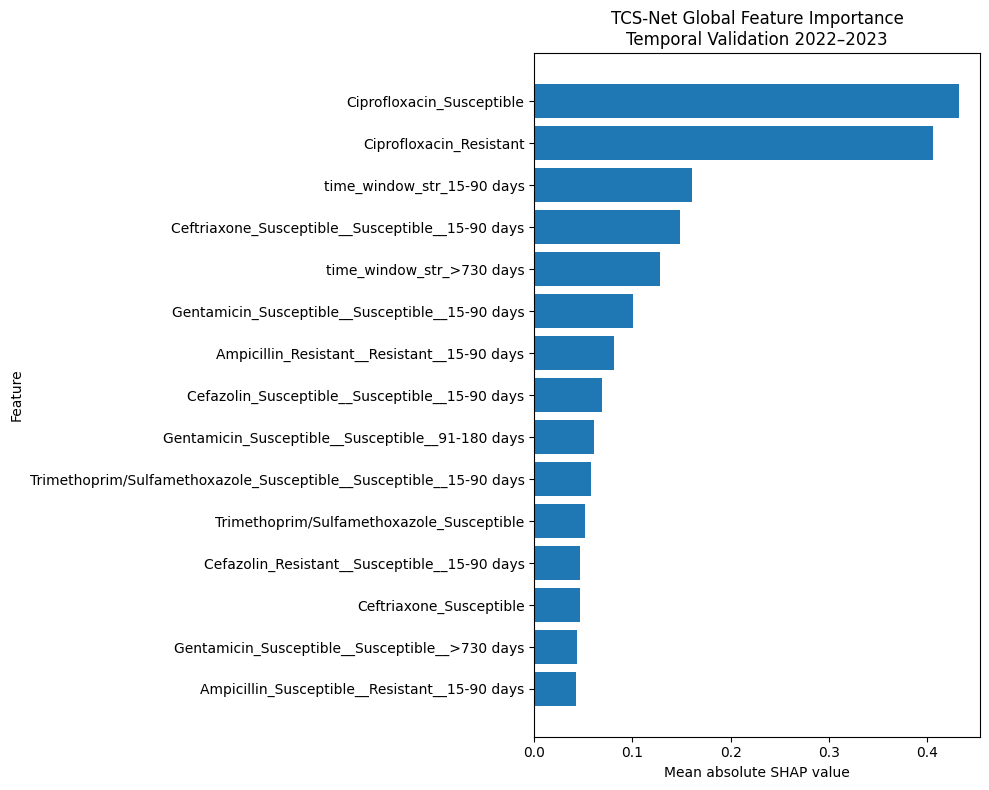

In [61]:
import matplotlib.pyplot as plt

top_n = 15

plot_df = (
    shap_global_df
    .sort_values(
        "mean_abs_SHAP",
        ascending=False
    )
    .head(top_n)
    .copy()
)

# Clean names for presentation
plot_df["clean_feature"] = (
    plot_df["feature"]
    .str.replace(
        "categorical__",
        "",
        regex=False
    )
    .str.replace(
        "INT_",
        "",
        regex=False
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["clean_feature"][::-1],
    plot_df["mean_abs_SHAP"][::-1]
)

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")

plt.title(
    "TCS-Net Global Feature Importance\n"
    "Temporal Validation 2022–2023"
)

plt.tight_layout()
plt.show()

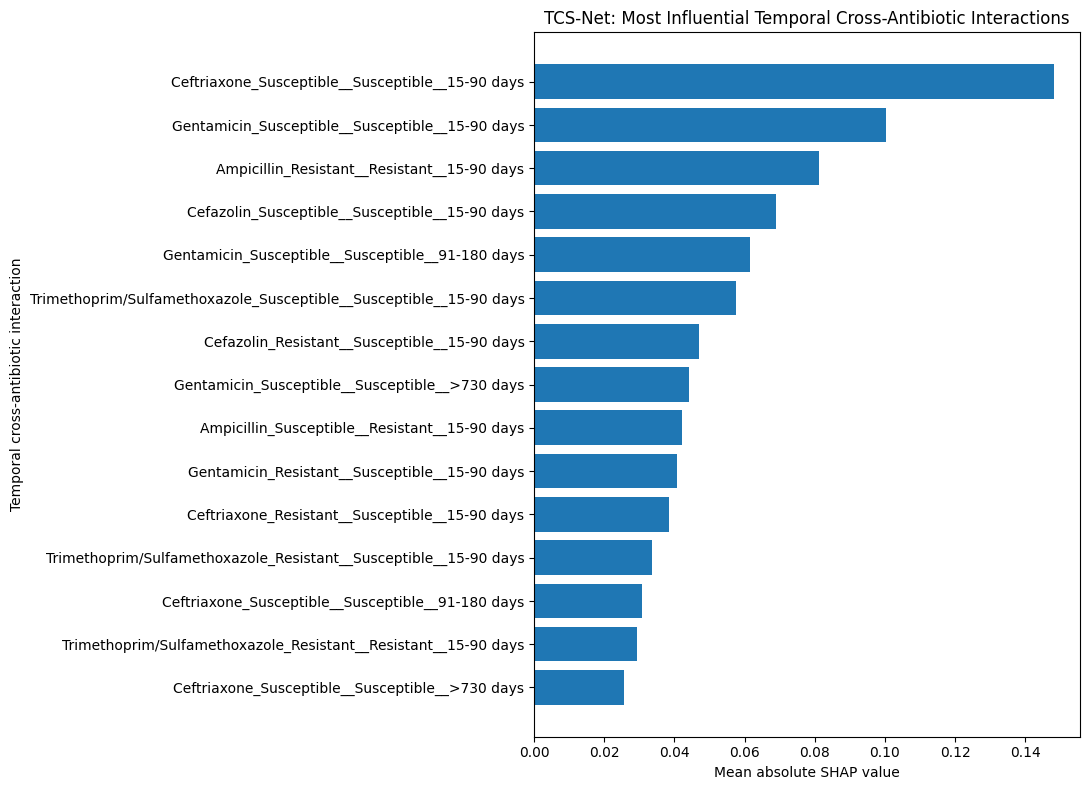

In [62]:
top_interactions_plot = (
    shap_interaction_df
    .sort_values(
        "mean_abs_SHAP",
        ascending=False
    )
    .head(15)
    .copy()
)

top_interactions_plot["clean_feature"] = (
    top_interactions_plot["feature"]
    .str.replace(
        "categorical__INT_",
        "",
        regex=False
    )
)

plt.figure(figsize=(11, 8))

plt.barh(
    top_interactions_plot["clean_feature"][::-1],
    top_interactions_plot["mean_abs_SHAP"][::-1]
)

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Temporal cross-antibiotic interaction")

plt.title(
    "TCS-Net: Most Influential Temporal "
    "Cross-Antibiotic Interactions"
)

plt.tight_layout()
plt.show()

In [63]:
# ==========================================
# Representative Smart-AST cases
# using the STRICT safety pipeline
# ==========================================

local_demo_df = temporal_test.copy()

local_demo_df["calibrated_probability"] = (
    calibrated_prob_2022_23
)

def smart_ast_decision(p):
    if p <= FINAL_LOW_THRESHOLD:
        return "Confident_Susceptible"
    elif p >= FINAL_HIGH_THRESHOLD:
        return "Confident_Resistant"
    else:
        return "ABSTAIN"

local_demo_df["Smart_AST_Decision"] = (
    local_demo_df["calibrated_probability"]
    .apply(smart_ast_decision)
)

print(
    local_demo_df["Smart_AST_Decision"]
    .value_counts()
)

Smart_AST_Decision
Confident_Susceptible    2127
ABSTAIN                  1798
Confident_Resistant       698
Name: count, dtype: int64


In [64]:
representative_rows = []

for decision in [
    "Confident_Susceptible",
    "Confident_Resistant",
    "ABSTAIN"
]:

    group = local_demo_df[
        local_demo_df["Smart_AST_Decision"]
        == decision
    ].copy()

    median_probability = (
        group["calibrated_probability"]
        .median()
    )

    group["distance_to_median"] = (
        group["calibrated_probability"]
        - median_probability
    ).abs()

    selected = (
        group
        .sort_values("distance_to_median")
        .iloc[0]
    )

    representative_rows.append(
        selected
    )


representative_cases = pd.DataFrame(
    representative_rows
).reset_index()

display(
    representative_cases[
        [
            "anon_id",
            "Ciprofloxacin",
            "time_window_str",
            "calibrated_probability",
            "Smart_AST_Decision",
            "target"
        ]
    ]
)

antibiotic,anon_id,Ciprofloxacin,time_window_str,calibrated_probability,Smart_AST_Decision,target
0,JC1477105,Susceptible,91-180 days,0.079318,Confident_Susceptible,0
1,JC938669,Resistant,15-90 days,0.907200,Confident_Resistant,1
2,JC997955,Susceptible,>730 days,0.121710,ABSTAIN,0


In [65]:
# Exact model used before strict calibration
smart_preprocessor = (
    E_dev_model.named_steps["preprocessor"]
)

smart_classifier = (
    E_dev_model.named_steps["classifier"]
)

smart_feature_names = (
    smart_preprocessor
    .get_feature_names_out()
)

# Background from 2008-2019 training data
X_smart_background = (
    smart_preprocessor.transform(
        dev_train[E_features]
    )
)

# Only the 3 representative cases
X_smart_cases = (
    smart_preprocessor.transform(
        representative_cases[E_features]
    )
)

rng = np.random.default_rng(42)

background_indices = rng.choice(
    X_smart_background.shape[0],
    size=min(
        100,
        X_smart_background.shape[0]
    ),
    replace=False
)

smart_explainer = shap.LinearExplainer(
    smart_classifier,
    X_smart_background[
        background_indices
    ]
)

smart_case_shap = smart_explainer(
    X_smart_cases
)

print("✅ Local SHAP ready")
print(
    "Shape:",
    smart_case_shap.values.shape
)

✅ Local SHAP ready
Shape: (3, 239)


In [66]:
import re

def clean_tcs_feature_name(feature_name):

    name = feature_name.replace(
        "categorical__",
        ""
    )

    # Interaction feature
    if name.startswith("INT_"):

        text = name.replace("INT_", "", 1)

        parts = text.split("__")

        if len(parts) == 3:

            first_part, other_status, time_window = parts

            match = re.match(
                r"(.+)_(Susceptible|Resistant|Missing)$",
                first_part
            )

            if match:

                antibiotic = match.group(1)
                previous_cipro = match.group(2)

                return (
                    f"Prev Cipro={previous_cipro} | "
                    f"{antibiotic}={other_status} | "
                    f"{time_window}"
                )

    # Previous Ciprofloxacin
    if name.startswith("Ciprofloxacin_"):
        status = name.replace(
            "Ciprofloxacin_",
            ""
        )
        return f"Previous Cipro = {status}"

    # Time
    if name.startswith("time_window_str_"):
        time = name.replace(
            "time_window_str_",
            ""
        )
        return f"Time = {time}"

    return name


local_shap_tables = {}

for i in range(len(representative_cases)):

    # Encoded values for this patient
    if hasattr(X_smart_cases[i], "toarray"):
        encoded_values = (
            X_smart_cases[i]
            .toarray()
            .ravel()
        )
    else:
        encoded_values = np.asarray(
            X_smart_cases[i]
        ).ravel()

    case_df = pd.DataFrame({
        "feature": smart_feature_names,
        "encoded_value": encoded_values,
        "SHAP_value": smart_case_shap.values[i]
    })

    # For intuitive demo:
    # show only categories actually active for this patient
    active_df = case_df[
        case_df["encoded_value"] > 0
    ].copy()

    active_df["clean_feature"] = (
        active_df["feature"]
        .apply(clean_tcs_feature_name)
    )

    active_df["abs_SHAP"] = (
        active_df["SHAP_value"].abs()
    )

    active_df = active_df.sort_values(
        "abs_SHAP",
        ascending=False
    )

    local_shap_tables[i] = active_df


print("✅ Local active-feature explanations ready")

✅ Local active-feature explanations ready


In [67]:
for i in range(len(representative_cases)):

    row = representative_cases.iloc[i]

    raw_probability = (
        E_dev_model.predict_proba(
            representative_cases.iloc[[i]][E_features]
        )[0, 1]
    )

    print("\n" + "=" * 85)

    print(
        f"CASE {i+1}: "
        f"{row['Smart_AST_Decision']}"
    )

    print("=" * 85)

    print(
        f"Previous Cipro: "
        f"{row['Ciprofloxacin']}"
    )

    print(
        f"Time window: "
        f"{row['time_window_str']}"
    )

    print(
        f"Raw P(Resistance): "
        f"{raw_probability:.4f}"
    )

    print(
        f"Calibrated P(Resistance): "
        f"{row['calibrated_probability']:.4f}"
    )

    print(
        f"Actual outcome: "
        f"{'Resistant' if row['target'] == 1 else 'Susceptible'}"
    )

    case_table = local_shap_tables[i]

    print("\nTOP ACTIVE FACTORS → RESISTANCE")

    display(
        case_table[
            case_table["SHAP_value"] > 0
        ][
            [
                "clean_feature",
                "SHAP_value"
            ]
        ]
        .head(6)
        .round(4)
    )

    print("TOP ACTIVE FACTORS → SUSCEPTIBILITY")

    display(
        case_table[
            case_table["SHAP_value"] < 0
        ][
            [
                "clean_feature",
                "SHAP_value"
            ]
        ]
        .sort_values(
            "SHAP_value"
        )
        .head(6)
        .round(4)
    )


CASE 1: Confident_Susceptible
Previous Cipro: Susceptible
Time window: 91-180 days
Raw P(Resistance): 0.0880
Calibrated P(Resistance): 0.0793
Actual outcome: Susceptible

TOP ACTIVE FACTORS → RESISTANCE


,clean_feature,SHAP_value
108,Prev Cipro=Susceptible | Trimethoprim/Sulfamethoxazole=Susceptible | 91-180 days,0.0241
6,Time = 91-180 days,0.0069


TOP ACTIVE FACTORS → SUSCEPTIBILITY


,clean_feature,SHAP_value
151,Prev Cipro=Susceptible | Gentamicin=Susceptible | 91-180 days,-0.3100
2,Previous Cipro = Susceptible,-0.2693
237,Prev Cipro=Susceptible | Ceftriaxone=Susceptible | 91-180 days,-0.2212
194,Prev Cipro=Susceptible | Cefazolin=Susceptible | 91-180 days,-0.0826
22,Ceftriaxone_Susceptible,-0.0485
13,Trimethoprim/Sulfamethoxazole_Susceptible,-0.0291



CASE 2: Confident_Resistant
Previous Cipro: Resistant
Time window: 15-90 days
Raw P(Resistance): 0.8815
Calibrated P(Resistance): 0.9072
Actual outcome: Resistant

TOP ACTIVE FACTORS → RESISTANCE


...

,clean_feature,SHAP_value
22,Ceftriaxone_Susceptible,-0.0485
13,Trimethoprim/Sulfamethoxazole_Susceptible,-0.0291
10,Ampicillin_Susceptible,-0.0269
19,Cefazolin_Susceptible,-0.0138
16,Gentamicin_Susceptible,-0.0096



CASE 3: ABSTAIN
Previous Cipro: Susceptible
Time window: >730 days
Raw P(Resistance): 0.1298
Calibrated P(Resistance): 0.1217
Actual outcome: Susceptible

TOP ACTIVE FACTORS → RESISTANCE


,clean_feature,SHAP_value
152,Prev Cipro=Susceptible | Gentamicin=Susceptible | >730 days,0.1185
109,Prev Cipro=Susceptible | Trimethoprim/Sulfamethoxazole=Susceptible | >730 days,0.0453
228,Prev Cipro=Susceptible | Ceftriaxone=Missing | >730 days,0.0291


TOP ACTIVE FACTORS → SUSCEPTIBILITY


,clean_feature,SHAP_value
2,Previous Cipro = Susceptible,-0.2693
7,Time = >730 days,-0.2616
65,Prev Cipro=Susceptible | Ampicillin=Susceptible | >730 days,-0.0732
195,Prev Cipro=Susceptible | Cefazolin=Susceptible | >730 days,-0.0521
20,Ceftriaxone_Missing,-0.0476
13,Trimethoprim/Sulfamethoxazole_Susceptible,-0.0291


In [68]:
# ==========================================
# Audit unseen categorical levels
# Strict model train: 2008-2019
# Temporal test: 2022-2023
# ==========================================

smart_encoder = (
    smart_preprocessor
    .named_transformers_["categorical"]
    .named_steps["onehot"]
)

unseen_category_results = []

for feature, known_categories in zip(
    E_features,
    smart_encoder.categories_
):

    known = set(
        pd.Series(known_categories)
        .astype("string")
    )

    test_values = (
        temporal_test[feature]
        .astype("string")
        .fillna("Missing")
    )

    unseen_mask = ~test_values.isin(known)

    unseen_category_results.append({
        "feature": feature,
        "known_categories": len(known),
        "unseen_rows": int(unseen_mask.sum()),
        "unseen_rate": unseen_mask.mean(),
        "unseen_values": sorted(
            test_values[unseen_mask]
            .unique()
            .tolist()
        )
    })

unseen_category_df = pd.DataFrame(
    unseen_category_results
)

display(
    unseen_category_df[
        unseen_category_df["unseen_rows"] > 0
    ].sort_values(
        "unseen_rows",
        ascending=False
    )
)

,feature,known_categories,unseen_rows,unseen_rate,unseen_values
7,INT_Ampicillin,43,8,0.001730,"[Missing__Susceptible__181-365 days, Missing__Susceptible__91-180 days]"
10,INT_Cefazolin,43,5,0.001082,"[Missing__Resistant__181-365 days, Missing__Resistant__>730 days]"
11,INT_Ceftriaxone,43,5,0.001082,"[Missing__Resistant__181-365 days, Missing__Resistant__>730 days]"
9,INT_Gentamicin,43,4,0.000865,"[Missing__Resistant__181-365 days, Missing__Resistant__>730 days]"


In [69]:
row_has_unseen = np.zeros(
    len(temporal_test),
    dtype=bool
)

for feature, known_categories in zip(
    E_features,
    smart_encoder.categories_
):

    known = set(
        pd.Series(known_categories)
        .astype("string")
    )

    values = (
        temporal_test[feature]
        .astype("string")
        .fillna("Missing")
    )

    row_has_unseen |= (
        ~values.isin(known)
    ).to_numpy()


print(
    "Temporal-test rows with >=1 unseen category:",
    row_has_unseen.sum()
)

print(
    "Rate:",
    row_has_unseen.mean() * 100,
    "%"
)

print(
    "Rows with no unseen categories:",
    (~row_has_unseen).sum()
)

Temporal-test rows with >=1 unseen category: 15
Rate: 0.32446463335496434 %
Rows with no unseen categories: 4608


In [70]:
seen_only_mask = ~row_has_unseen

y_seen = temporal_test.loc[
    seen_only_mask,
    "target"
]

p_seen = calibrated_prob_2022_23[
    seen_only_mask
]

print("SEEN-CATEGORY-ONLY TEMPORAL TEST")
print("--------------------------------")
print("Rows:", seen_only_mask.sum())

print(
    "ROC-AUC:",
    roc_auc_score(
        y_seen,
        p_seen
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_seen,
        p_seen
    )
)

print(
    "Brier:",
    brier_score_loss(
        y_seen,
        p_seen
    )
)

seen_smart_ast = selective_metrics_extended(
    y_true=y_seen,
    probabilities=p_seen,
    low_threshold=FINAL_LOW_THRESHOLD,
    high_threshold=FINAL_HIGH_THRESHOLD
)

print("\nSMART-AST")
for key in [
    "coverage",
    "selective_accuracy",
    "false_susceptible_rate",
    "resistant_miss_rate",
    "dangerous_error_overall"
]:
    print(
        key,
        ":",
        round(seen_smart_ast[key], 4)
    )

SEEN-CATEGORY-ONLY TEMPORAL TEST
--------------------------------
Rows: 4608
ROC-AUC: 0.8740832342832051
PR-AUC: 0.7829983184380243
Brier: 0.10184976090489906

SMART-AST
coverage : 0.6131
selective_accuracy : 0.9204
false_susceptible_rate : 0.0715
resistant_miss_rate : 0.1203
dangerous_error_overall : 0.033


In [71]:
import pickle
import gzip
import os
from datetime import datetime

checkpoint_stage2 = {
    # -------------------------
    # Core data
    # -------------------------
    "cipro_data": cipro_data,
    "temporal_train": temporal_train,
    "temporal_test": temporal_test,
    "dev_train": dev_train,
    "dev_valid": dev_valid,
    "calibration_2020": calibration_2020,
    "threshold_2021": threshold_2021,

    # -------------------------
    # Feature definitions
    # -------------------------
    "cross_features": cross_features,
    "temporal_feature_sets": temporal_feature_sets,
    "dev_feature_sets": dev_feature_sets,
    "E_features": E_features,

    # -------------------------
    # Models
    # -------------------------
    "E_dev_model": E_dev_model,
    "final_tuned_models": final_tuned_models,
    "best_C": best_C,

    # -------------------------
    # Calibration
    # -------------------------
    "platt_strict": platt_strict,
    "calibrated_prob_2021": calibrated_prob_2021,
    "calibrated_prob_2022_23": calibrated_prob_2022_23,

    # -------------------------
    # Smart-AST
    # -------------------------
    "FINAL_LOW_THRESHOLD": FINAL_LOW_THRESHOLD,
    "FINAL_HIGH_THRESHOLD": FINAL_HIGH_THRESHOLD,
    "final_smart_ast_df": final_smart_ast_df,
    "smart_ast_bootstrap_ci": smart_ast_bootstrap_ci,
    "fine_threshold_df": fine_threshold_df,

    # -------------------------
    # Results
    # -------------------------
    "temporal_results_df": temporal_results_df,
    "final_tuned_results_df": final_tuned_results_df,
    "tuning_results_df": tuning_results_df,
    "new_patient_results_df": new_patient_results_df,

    # -------------------------
    # Interpretability
    # -------------------------
    "coefficient_df": coefficient_df,
    "interaction_coefficient_df": interaction_coefficient_df,
    "interaction_support_df": interaction_support_df,
    "shap_global_df": shap_global_df,
    "shap_interaction_df": shap_interaction_df,
    "representative_cases": representative_cases,

    # -------------------------
    # Unseen-category audit
    # -------------------------
    "unseen_category_df": unseen_category_df,
    "row_has_unseen": row_has_unseen,

    # -------------------------
    # Metadata
    # -------------------------
    "checkpoint_info": {
        "project": "TCS-Net",
        "stage": "Stage 2 - Temporal validation, calibration, Smart-AST, XAI",
        "created": datetime.now().isoformat(),
        "target": "Future Ciprofloxacin resistance",
        "train_period": "2008-2019",
        "calibration_period": "2020",
        "threshold_period": "2021",
        "temporal_test_period": "2022-2023",
        "low_threshold": FINAL_LOW_THRESHOLD,
        "high_threshold": FINAL_HIGH_THRESHOLD
    }
}

checkpoint_filename = (
    "TCSNet_STAGE2_FULL_CHECKPOINT.pkl.gz"
)

with gzip.open(
    checkpoint_filename,
    "wb"
) as f:
    pickle.dump(
        checkpoint_stage2,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

print("✅ Checkpoint saved")
print(
    "File:",
    checkpoint_filename
)

print(
    "Size:",
    round(
        os.path.getsize(
            checkpoint_filename
        ) / (1024**2),
        2
    ),
    "MB"
)

✅ Checkpoint saved
File: TCSNet_STAGE2_FULL_CHECKPOINT.pkl.gz
Size: 2.11 MB


In [72]:
from google.colab import files

files.download(
    "TCSNet_STAGE2_FULL_CHECKPOINT.pkl.gz"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
# Make sure the master transition dataset still exists
print("transition_dataset exists:", "transition_dataset" in globals())

assert "transition_dataset" in globals(), (
    "transition_dataset is missing from the current runtime."
)

# Add objects needed for replication targets
checkpoint_stage2["transition_dataset"] = transition_dataset

if "primary_antibiotics" in globals():
    checkpoint_stage2["primary_antibiotics"] = primary_antibiotics

# Save a more complete checkpoint
checkpoint_filename_v2 = (
    "TCSNet_STAGE2_PLUS_TRANSITIONS.pkl.gz"
)

with gzip.open(
    checkpoint_filename_v2,
    "wb"
) as f:
    pickle.dump(
        checkpoint_stage2,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

print("✅ Updated checkpoint saved")
print("File:", checkpoint_filename_v2)

print(
    "Size:",
    round(
        os.path.getsize(checkpoint_filename_v2)
        / (1024**2),
        2
    ),
    "MB"
)

transition_dataset exists: True
✅ Updated checkpoint saved
File: TCSNet_STAGE2_PLUS_TRANSITIONS.pkl.gz
Size: 2.67 MB


In [74]:
from google.colab import files

files.download(
    "TCSNet_STAGE2_PLUS_TRANSITIONS.pkl.gz"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
# ==========================================
# AMPICILLIN REPLICATION TARGET
# Same locked TCS-Net architecture
# ==========================================

amp_data = transition_dataset[
    transition_dataset["next_Ampicillin"].isin(
        ["Susceptible", "Resistant"]
    )
].copy()

amp_data["target"] = (
    amp_data["next_Ampicillin"]
    == "Resistant"
).astype(int)

amp_data["target_year"] = (
    pd.to_datetime(
        amp_data["next_culture_time"]
    ).dt.year
)

amp_cross_features = [
    "Ciprofloxacin",
    "Trimethoprim/Sulfamethoxazole",
    "Gentamicin",
    "Cefazolin",
    "Ceftriaxone"
]

print("AMPICILLIN REPLICATION COHORT")
print("-----------------------------")

print("Transitions:", len(amp_data))
print(
    "Patients:",
    amp_data["anon_id"].nunique()
)

print(
    "Resistance cases:",
    amp_data["target"].sum()
)

print(
    "Resistance rate:",
    amp_data["target"].mean() * 100
)

print("\nTarget distribution:")
print(
    amp_data["next_Ampicillin"]
    .value_counts()
)

print("\nYear range:")
print(
    amp_data["target_year"].min(),
    "-",
    amp_data["target_year"].max()
)

AMPICILLIN REPLICATION COHORT
-----------------------------
Transitions: 19945
Patients: 9201
Resistance cases: 9835
Resistance rate: 49.31060416144397

Target distribution:
next_Ampicillin
Susceptible     10110
Resistant        9835
Intermediate        0
Inconclusive        0
Null                0
Synergism           0
Name: count, dtype: int64

Year range:
2008 - 2024


In [76]:
# ==========================================
# AMPICILLIN TEMPORAL REPLICATION SPLIT
# Development/history: <= 2021
# Temporal test:       2022-2023
# 2024 excluded because incomplete
# ==========================================

amp_temporal_train = amp_data[
    amp_data["target_year"] <= 2021
].copy()

amp_temporal_test = amp_data[
    amp_data["target_year"].isin([2022, 2023])
].copy()

print("AMPICILLIN TEMPORAL TRAIN")
print("-------------------------")
print("Transitions:", len(amp_temporal_train))
print("Patients:", amp_temporal_train["anon_id"].nunique())
print(
    "Resistance rate:",
    amp_temporal_train["target"].mean() * 100
)

print("\nAMPICILLIN TEMPORAL TEST")
print("------------------------")
print("Transitions:", len(amp_temporal_test))
print("Patients:", amp_temporal_test["anon_id"].nunique())
print(
    "Resistance rate:",
    amp_temporal_test["target"].mean() * 100
)

train_patients_amp = set(
    amp_temporal_train["anon_id"]
)

test_patients_amp = set(
    amp_temporal_test["anon_id"]
)

overlap_amp = (
    train_patients_amp &
    test_patients_amp
)

print("\nPatient overlap:", len(overlap_amp))

print(
    "Temporal-test patients seen historically:",
    len(overlap_amp)
    / len(test_patients_amp)
    * 100,
    "%"
)

AMPICILLIN TEMPORAL TRAIN
-------------------------
Transitions: 15261
Patients: 7248
Resistance rate: 50.04259222855645

AMPICILLIN TEMPORAL TEST
------------------------
Transitions: 4637
Patients: 2912
Resistance rate: 46.926892387319384

Patient overlap: 979
Temporal-test patients seen historically: 33.619505494505496 %


In [77]:
# ==========================================
# AMPICILLIN TEMPORAL REPLICATION SPLIT
# Development/history: <= 2021
# Temporal test:       2022-2023
# 2024 excluded because incomplete
# ==========================================

amp_temporal_train = amp_data[
    amp_data["target_year"] <= 2021
].copy()

amp_temporal_test = amp_data[
    amp_data["target_year"].isin([2022, 2023])
].copy()

print("AMPICILLIN TEMPORAL TRAIN")
print("-------------------------")
print("Transitions:", len(amp_temporal_train))
print("Patients:", amp_temporal_train["anon_id"].nunique())
print(
    "Resistance rate:",
    amp_temporal_train["target"].mean() * 100
)

print("\nAMPICILLIN TEMPORAL TEST")
print("------------------------")
print("Transitions:", len(amp_temporal_test))
print("Patients:", amp_temporal_test["anon_id"].nunique())
print(
    "Resistance rate:",
    amp_temporal_test["target"].mean() * 100
)

train_patients_amp = set(
    amp_temporal_train["anon_id"]
)

test_patients_amp = set(
    amp_temporal_test["anon_id"]
)

overlap_amp = (
    train_patients_amp &
    test_patients_amp
)

print("\nPatient overlap:", len(overlap_amp))

print(
    "Temporal-test patients seen historically:",
    len(overlap_amp)
    / len(test_patients_amp)
    * 100,
    "%"
)

AMPICILLIN TEMPORAL TRAIN
-------------------------
Transitions: 15261
Patients: 7248
Resistance rate: 50.04259222855645

AMPICILLIN TEMPORAL TEST
------------------------
Transitions: 4637
Patients: 2912
Resistance rate: 46.926892387319384

Patient overlap: 979
Temporal-test patients seen historically: 33.619505494505496 %


In [78]:
# ==========================================
# LOCKED AMPICILLIN TCS-NET FEATURES
# ==========================================

amp_temporal_train["time_window_str"] = (
    amp_temporal_train["time_window"]
    .astype("string")
    .fillna("Missing")
)

amp_temporal_test["time_window_str"] = (
    amp_temporal_test["time_window"]
    .astype("string")
    .fillna("Missing")
)

amp_interaction_columns = []

for antibiotic in amp_cross_features:

    interaction_name = (
        f"INT_{antibiotic}"
    )

    amp_temporal_train[interaction_name] = (
        amp_temporal_train["Ampicillin"]
        .astype("string")
        .fillna("Missing")
        + "__"
        + amp_temporal_train[antibiotic]
        .astype("string")
        .fillna("Missing")
        + "__"
        + amp_temporal_train[
            "time_window_str"
        ]
    )

    amp_temporal_test[interaction_name] = (
        amp_temporal_test["Ampicillin"]
        .astype("string")
        .fillna("Missing")
        + "__"
        + amp_temporal_test[antibiotic]
        .astype("string")
        .fillna("Missing")
        + "__"
        + amp_temporal_test[
            "time_window_str"
        ]
    )

    amp_interaction_columns.append(
        interaction_name
    )


amp_feature_sets = {

    "B2_SameDrug_TimeWindow": [
        "Ampicillin",
        "time_window_str"
    ],

    "D2_Additive_TCSNet": [
        "Ampicillin",
        "time_window_str"
    ] + amp_cross_features,

    "E_Interaction_TCSNet": [
        "Ampicillin",
        "time_window_str"
    ] + amp_cross_features + amp_interaction_columns
}


print("✅ Ampicillin replication features ready")

for name, features in amp_feature_sets.items():
    print(
        name,
        ":",
        len(features),
        "features"
    )

KeyError: 'time_window'

In [79]:
# ==========================================
# Recreate the SAME locked time windows
# used in the Ciprofloxacin analysis
# ==========================================

assert "days_to_next_culture" in amp_temporal_train.columns, (
    "days_to_next_culture column is missing"
)

def create_time_window(df):

    days = df["days_to_next_culture"]

    df["time_window"] = np.select(
        [
            (days > 14) & (days <= 90),
            (days > 90) & (days <= 180),
            (days > 180) & (days <= 365),
            (days > 365) & (days <= 730),
            days > 730
        ],
        [
            "15-90 days",
            "91-180 days",
            "181-365 days",
            "366-730 days",
            ">730 days"
        ],
        default="Missing"
    )

    return df


amp_temporal_train = create_time_window(
    amp_temporal_train
)

amp_temporal_test = create_time_window(
    amp_temporal_test
)


print("TRAIN time windows:")
print(
    amp_temporal_train["time_window"]
    .value_counts()
)

print("\nTEST time windows:")
print(
    amp_temporal_test["time_window"]
    .value_counts()
)

TRAIN time windows:
time_window
15-90 days      4819
>730 days       2951
181-365 days    2632
366-730 days    2436
91-180 days     2423
Name: count, dtype: int64

TEST time windows:
time_window
15-90 days      1457
>730 days       1153
91-180 days      692
181-365 days     691
366-730 days     644
Name: count, dtype: int64


In [80]:
amp_temporal_train["time_window_str"] = (
    amp_temporal_train["time_window"]
    .astype("string")
    .fillna("Missing")
)

amp_temporal_test["time_window_str"] = (
    amp_temporal_test["time_window"]
    .astype("string")
    .fillna("Missing")
)

amp_interaction_columns = []

for antibiotic in amp_cross_features:

    interaction_name = f"INT_{antibiotic}"

    amp_temporal_train[interaction_name] = (
        amp_temporal_train["Ampicillin"]
        .astype("string")
        .fillna("Missing")
        + "__"
        + amp_temporal_train[antibiotic]
        .astype("string")
        .fillna("Missing")
        + "__"
        + amp_temporal_train["time_window_str"]
    )

    amp_temporal_test[interaction_name] = (
        amp_temporal_test["Ampicillin"]
        .astype("string")
        .fillna("Missing")
        + "__"
        + amp_temporal_test[antibiotic]
        .astype("string")
        .fillna("Missing")
        + "__"
        + amp_temporal_test["time_window_str"]
    )

    amp_interaction_columns.append(
        interaction_name
    )


amp_feature_sets = {

    "B2_SameDrug_TimeWindow": [
        "Ampicillin",
        "time_window_str"
    ],

    "D2_Additive_TCSNet": [
        "Ampicillin",
        "time_window_str"
    ] + amp_cross_features,

    "E_Interaction_TCSNet": [
        "Ampicillin",
        "time_window_str"
    ] + amp_cross_features + amp_interaction_columns
}


print("✅ Ampicillin replication features ready")

for name, features in amp_feature_sets.items():
    print(
        name,
        ":",
        len(features),
        "features"
    )

✅ Ampicillin replication features ready
B2_SameDrug_TimeWindow : 2 features
D2_Additive_TCSNet : 7 features
E_Interaction_TCSNet : 12 features


In [81]:
# ==========================================
# LOCKED AMPICILLIN REPLICATION
# Hyperparameters transferred directly
# from the Ciprofloxacin development
# ==========================================

amp_best_C = {
    "B2_SameDrug_TimeWindow": 0.1,
    "D2_Additive_TCSNet": 1.0,
    "E_Interaction_TCSNet": 0.1
}

amp_results = []
amp_models = {}
amp_probabilities = {}

y_train_amp = amp_temporal_train["target"]
y_test_amp = amp_temporal_test["target"]

for model_name, features in amp_feature_sets.items():

    C_value = amp_best_C[model_name]

    print(
        f"Training {model_name} "
        f"with locked C={C_value}..."
    )

    X_train_amp = amp_temporal_train[features]
    X_test_amp = amp_temporal_test[features]

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Missing"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ])

    preprocessor = ColumnTransformer([
        (
            "categorical",
            categorical_pipeline,
            features
        )
    ])

    model = Pipeline([
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                C=C_value,
                max_iter=3000,
                random_state=42
            )
        )
    ])

    model.fit(
        X_train_amp,
        y_train_amp
    )

    probabilities = model.predict_proba(
        X_test_amp
    )[:, 1]

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_amp,
        predictions
    ).ravel()

    amp_results.append({
        "Model": model_name,
        "C": C_value,

        "ROC_AUC": roc_auc_score(
            y_test_amp,
            probabilities
        ),

        "PR_AUC": average_precision_score(
            y_test_amp,
            probabilities
        ),

        "Accuracy": accuracy_score(
            y_test_amp,
            predictions
        ),

        "Precision": precision_score(
            y_test_amp,
            predictions,
            zero_division=0
        ),

        "Sensitivity_Recall": recall_score(
            y_test_amp,
            predictions
        ),

        "Specificity": (
            tn / (tn + fp)
        ),

        "F1": f1_score(
            y_test_amp,
            predictions
        ),

        "Brier_Score": brier_score_loss(
            y_test_amp,
            probabilities
        )
    })

    amp_models[model_name] = model
    amp_probabilities[model_name] = probabilities

    print("✅ Done")


amp_results_df = pd.DataFrame(
    amp_results
).sort_values(
    "ROC_AUC",
    ascending=False
)

print("\n====================================")
print("AMPICILLIN LOCKED TEMPORAL REPLICATION")
print("2022-2023")
print("====================================")

display(
    amp_results_df.round(4)
)

Training B2_SameDrug_TimeWindow with locked C=0.1...
✅ Done
Training D2_Additive_TCSNet with locked C=1.0...
✅ Done
Training E_Interaction_TCSNet with locked C=0.1...
✅ Done

AMPICILLIN LOCKED TEMPORAL REPLICATION
2022-2023


,Model,C,ROC_AUC,PR_AUC,Accuracy,Precision,Sensitivity_Recall,Specificity,F1,Brier_Score
2,E_Interaction_TCSNet,0.1,0.8230,0.8048,0.7634,0.7924,0.6719,0.8444,0.7272,0.1680
1,D2_Additive_TCSNet,1.0,0.7733,0.7784,0.7639,0.7556,0.7344,0.7899,0.7448,0.1792
0,B2_SameDrug_TimeWindow,0.1,0.7720,0.7681,0.7621,0.7527,0.7344,0.7867,0.7434,0.1804


In [82]:
amp_comparison = pd.DataFrame({
    "anon_id": amp_temporal_test["anon_id"].values,
    "target": amp_temporal_test["target"].values,

    "prob_B2": amp_probabilities[
        "B2_SameDrug_TimeWindow"
    ],

    "prob_D2": amp_probabilities[
        "D2_Additive_TCSNet"
    ],

    "prob_E": amp_probabilities[
        "E_Interaction_TCSNet"
    ]
})

print("Rows:", len(amp_comparison))
print(
    "Patients:",
    amp_comparison["anon_id"].nunique()
)

display(
    amp_comparison.head()
)

Rows: 4637
Patients: 2912


,anon_id,target,prob_B2,prob_D2,prob_E
0,JC1000974,1,0.796950,0.748330,0.891243
1,JC1001515,0,0.796950,0.748330,0.891243
2,JC1001771,0,0.694165,0.676454,0.390844
3,JC1007145,1,0.205959,0.197503,0.354854
4,JC1007751,1,0.694165,0.768700,0.628383


In [83]:
amp_E_vs_B2 = paired_model_bootstrap(
    data=amp_comparison,
    baseline_col="prob_B2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)

amp_E_vs_D2 = paired_model_bootstrap(
    data=amp_comparison,
    baseline_col="prob_D2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)

print("================================")
print("AMPICILLIN: E vs B2")
print("================================")
print(amp_E_vs_B2)

print("\n================================")
print("AMPICILLIN: E vs D2")
print("================================")
print(amp_E_vs_D2)

AMPICILLIN: E vs B2
{'ROC_AUC_improvement': {'difference': np.float64(0.05088058838009214), 'CI_low': np.float64(0.04054703455526468), 'CI_high': np.float64(0.06223853317600681)}, 'PR_AUC_improvement': {'difference': np.float64(0.036708744163921926), 'CI_low': np.float64(0.029465302654833575), 'CI_high': np.float64(0.04401162383991727)}, 'Brier_improvement': {'difference': np.float64(0.012280649609469847), 'CI_low': np.float64(0.00941400350064684), 'CI_high': np.float64(0.015262420142109531)}}

AMPICILLIN: E vs D2
{'ROC_AUC_improvement': {'difference': np.float64(0.049771896626887406), 'CI_low': np.float64(0.03851276439314821), 'CI_high': np.float64(0.06091686854967496)}, 'PR_AUC_improvement': {'difference': np.float64(0.026554424521912198), 'CI_low': np.float64(0.017320688972071153), 'CI_high': np.float64(0.035590435827547263)}, 'Brier_improvement': {'difference': np.float64(0.011125759266996353), 'CI_low': np.float64(0.008202070133629235), 'CI_high': np.float64(0.013986404736707472)}

In [84]:
# Patients seen historically in Ampicillin training period
amp_historical_patients = set(
    amp_temporal_train["anon_id"]
)

# Keep only patients never seen in historical Ampicillin train
amp_new_patient_mask = ~amp_comparison[
    "anon_id"
].isin(
    amp_historical_patients
)

amp_new_patient_comparison = amp_comparison[
    amp_new_patient_mask
].copy()

print("AMPICILLIN NEW-PATIENT TEMPORAL REPLICATION")
print("-------------------------------------------")

print(
    "Transitions:",
    len(amp_new_patient_comparison)
)

print(
    "Unique new patients:",
    amp_new_patient_comparison[
        "anon_id"
    ].nunique()
)

print(
    "Resistance cases:",
    amp_new_patient_comparison[
        "target"
    ].sum()
)

print(
    "Resistance rate:",
    amp_new_patient_comparison[
        "target"
    ].mean() * 100
)

AMPICILLIN NEW-PATIENT TEMPORAL REPLICATION
-------------------------------------------
Transitions: 2774
Unique new patients: 1933
Resistance cases: 1283
Resistance rate: 46.25090122566691


In [85]:
amp_new_patient_results = []

for model_name, prob_col in {
    "B2_SameDrug_TimeWindow": "prob_B2",
    "D2_Additive_TCSNet": "prob_D2",
    "E_Interaction_TCSNet": "prob_E"
}.items():

    y_true = amp_new_patient_comparison[
        "target"
    ]

    probs = amp_new_patient_comparison[
        prob_col
    ]

    amp_new_patient_results.append({
        "Model": model_name,

        "ROC_AUC": roc_auc_score(
            y_true,
            probs
        ),

        "PR_AUC": average_precision_score(
            y_true,
            probs
        ),

        "Brier_Score": brier_score_loss(
            y_true,
            probs
        )
    })


amp_new_patient_results_df = pd.DataFrame(
    amp_new_patient_results
).sort_values(
    "ROC_AUC",
    ascending=False
)

display(
    amp_new_patient_results_df.round(4)
)


amp_new_E_vs_B2 = paired_model_bootstrap(
    data=amp_new_patient_comparison,
    baseline_col="prob_B2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)

amp_new_E_vs_D2 = paired_model_bootstrap(
    data=amp_new_patient_comparison,
    baseline_col="prob_D2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)

print("\n================================")
print("NEW PATIENT AMPICILLIN: E vs B2")
print("================================")
print(amp_new_E_vs_B2)

print("\n================================")
print("NEW PATIENT AMPICILLIN: E vs D2")
print("================================")
print(amp_new_E_vs_D2)

,Model,ROC_AUC,PR_AUC,Brier_Score
2,E_Interaction_TCSNet,0.8340,0.8113,0.1627
1,D2_Additive_TCSNet,0.7724,0.7811,0.1772
0,B2_SameDrug_TimeWindow,0.7694,0.7676,0.1786



NEW PATIENT AMPICILLIN: E vs B2
{'ROC_AUC_improvement': {'difference': np.float64(0.06457376645239739), 'CI_low': np.float64(0.05011764948258722), 'CI_high': np.float64(0.08031524450090757)}, 'PR_AUC_improvement': {'difference': np.float64(0.043525841417460596), 'CI_low': np.float64(0.03495368111428591), 'CI_high': np.float64(0.05237416614333633)}, 'Brier_improvement': {'difference': np.float64(0.01589694351878056), 'CI_low': np.float64(0.012091029514044881), 'CI_high': np.float64(0.019781624369082467)}}

NEW PATIENT AMPICILLIN: E vs D2
{'ROC_AUC_improvement': {'difference': np.float64(0.06160794185370773), 'CI_low': np.float64(0.047883174368376746), 'CI_high': np.float64(0.07641116898991158)}, 'PR_AUC_improvement': {'difference': np.float64(0.030387695311857692), 'CI_low': np.float64(0.020833538576787117), 'CI_high': np.float64(0.04149876742546977)}, 'Brier_improvement': {'difference': np.float64(0.014502441234113459), 'CI_low': np.float64(0.010799782677994238), 'CI_high': np.float64

In [86]:
# ==========================================
# FINAL HARMONIZED CIPRO COMPARISON
# Using the selected C values:
# B2=0.1, D2=1.0, E=0.1
# ==========================================

cipro_final_comparison = pd.DataFrame({
    "anon_id": temporal_test["anon_id"].values,
    "target": temporal_test["target"].values,

    "prob_B2": final_tuned_probabilities[
        "B2_SameDrug_TimeWindow"
    ],

    "prob_D2": final_tuned_probabilities[
        "D2_Additive_TCSNet"
    ],

    "prob_E": final_tuned_probabilities[
        "E_Interaction_TCSNet"
    ]
})

# New-patient-only subset
historical_cipro_patients = set(
    temporal_train["anon_id"]
)

cipro_final_new = cipro_final_comparison[
    ~cipro_final_comparison["anon_id"].isin(
        historical_cipro_patients
    )
].copy()


print("FINAL CIPRO TEMPORAL TEST")
print("Rows:", len(cipro_final_comparison))
print(
    "Patients:",
    cipro_final_comparison["anon_id"].nunique()
)

print("\nFINAL CIPRO NEW-PATIENT TEST")
print("Rows:", len(cipro_final_new))
print(
    "Patients:",
    cipro_final_new["anon_id"].nunique()
)

FINAL CIPRO TEMPORAL TEST
Rows: 4623
Patients: 2912

FINAL CIPRO NEW-PATIENT TEST
Rows: 2762
Patients: 1937


In [87]:
# Full temporal 2022-2023
cipro_final_E_vs_B2 = paired_model_bootstrap(
    data=cipro_final_comparison,
    baseline_col="prob_B2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)

cipro_final_E_vs_D2 = paired_model_bootstrap(
    data=cipro_final_comparison,
    baseline_col="prob_D2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)

# New-patient-only
cipro_final_new_E_vs_B2 = paired_model_bootstrap(
    data=cipro_final_new,
    baseline_col="prob_B2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)

cipro_final_new_E_vs_D2 = paired_model_bootstrap(
    data=cipro_final_new,
    baseline_col="prob_D2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)

print("================================")
print("CIPRO FINAL: E vs B2")
print("================================")
print(cipro_final_E_vs_B2)

print("\n================================")
print("CIPRO FINAL: E vs D2")
print("================================")
print(cipro_final_E_vs_D2)

print("\n================================")
print("CIPRO FINAL NEW-PATIENT: E vs B2")
print("================================")
print(cipro_final_new_E_vs_B2)

print("\n================================")
print("CIPRO FINAL NEW-PATIENT: E vs D2")
print("================================")
print(cipro_final_new_E_vs_D2)

CIPRO FINAL: E vs B2
{'ROC_AUC_improvement': {'difference': np.float64(0.05010499845968121), 'CI_low': np.float64(0.036098002306596884), 'CI_high': np.float64(0.06481230689182232)}, 'PR_AUC_improvement': {'difference': np.float64(0.038015355642649955), 'CI_low': np.float64(0.028146334137041325), 'CI_high': np.float64(0.04849040750626757)}, 'Brier_improvement': {'difference': np.float64(0.005310346324060051), 'CI_low': np.float64(0.003546778198016326), 'CI_high': np.float64(0.007104368707784615)}}

CIPRO FINAL: E vs D2
{'ROC_AUC_improvement': {'difference': np.float64(0.04735114367845564), 'CI_low': np.float64(0.033022330500429554), 'CI_high': np.float64(0.0611932202485043)}, 'PR_AUC_improvement': {'difference': np.float64(0.028405881438717386), 'CI_low': np.float64(0.016672215218439666), 'CI_high': np.float64(0.03987880939122483)}, 'Brier_improvement': {'difference': np.float64(0.004984924154858268), 'CI_low': np.float64(0.0033057111321615753), 'CI_high': np.float64(0.00671969652211466

In [88]:
def evaluate_probability_model(data, prob_col):

    y = data["target"]
    p = data[prob_col]

    return {
        "ROC_AUC": roc_auc_score(y, p),
        "PR_AUC": average_precision_score(y, p),
        "Brier_Score": brier_score_loss(y, p)
    }


# ==========================================
# TABLE 1: ABSOLUTE PERFORMANCE
# ==========================================

absolute_rows = []

validation_sets = {
    ("Ciprofloxacin", "Temporal 2022-2023"):
        cipro_final_comparison,

    ("Ciprofloxacin", "New-patient 2022-2023"):
        cipro_final_new,

    ("Ampicillin", "Temporal 2022-2023"):
        amp_comparison,

    ("Ampicillin", "New-patient 2022-2023"):
        amp_new_patient_comparison
}

model_columns = {
    "B2 Same-drug + Time": "prob_B2",
    "D2 Additive TCS-Net": "prob_D2",
    "E Interaction TCS-Net": "prob_E"
}

for (target_name, validation_name), dataset in validation_sets.items():

    for model_name, prob_col in model_columns.items():

        metrics = evaluate_probability_model(
            dataset,
            prob_col
        )

        absolute_rows.append({
            "Target": target_name,
            "Validation": validation_name,
            "Model": model_name,
            "N": len(dataset),
            "Patients": dataset["anon_id"].nunique(),
            **metrics
        })


stanford_absolute_results = pd.DataFrame(
    absolute_rows
)

display(
    stanford_absolute_results.round(4)
)


# ==========================================
# TABLE 2: PAIRED BOOTSTRAP IMPROVEMENTS
# ==========================================

def add_improvement_row(
    rows,
    target,
    validation,
    comparison,
    result
):

    rows.append({
        "Target": target,
        "Validation": validation,
        "Comparison": comparison,

        "Delta_ROC":
            result["ROC_AUC_improvement"]["difference"],

        "ROC_CI_low":
            result["ROC_AUC_improvement"]["CI_low"],

        "ROC_CI_high":
            result["ROC_AUC_improvement"]["CI_high"],

        "Delta_PR":
            result["PR_AUC_improvement"]["difference"],

        "PR_CI_low":
            result["PR_AUC_improvement"]["CI_low"],

        "PR_CI_high":
            result["PR_AUC_improvement"]["CI_high"],

        "Brier_Improvement":
            result["Brier_improvement"]["difference"],

        "Brier_CI_low":
            result["Brier_improvement"]["CI_low"],

        "Brier_CI_high":
            result["Brier_improvement"]["CI_high"]
    })


improvement_rows = []

# Cipro
add_improvement_row(
    improvement_rows,
    "Ciprofloxacin",
    "Temporal 2022-2023",
    "E vs B2",
    cipro_final_E_vs_B2
)

add_improvement_row(
    improvement_rows,
    "Ciprofloxacin",
    "Temporal 2022-2023",
    "E vs D2",
    cipro_final_E_vs_D2
)

add_improvement_row(
    improvement_rows,
    "Ciprofloxacin",
    "New-patient 2022-2023",
    "E vs B2",
    cipro_final_new_E_vs_B2
)

add_improvement_row(
    improvement_rows,
    "Ciprofloxacin",
    "New-patient 2022-2023",
    "E vs D2",
    cipro_final_new_E_vs_D2
)

# Ampicillin
add_improvement_row(
    improvement_rows,
    "Ampicillin",
    "Temporal 2022-2023",
    "E vs B2",
    amp_E_vs_B2
)

add_improvement_row(
    improvement_rows,
    "Ampicillin",
    "Temporal 2022-2023",
    "E vs D2",
    amp_E_vs_D2
)

add_improvement_row(
    improvement_rows,
    "Ampicillin",
    "New-patient 2022-2023",
    "E vs B2",
    amp_new_E_vs_B2
)

add_improvement_row(
    improvement_rows,
    "Ampicillin",
    "New-patient 2022-2023",
    "E vs D2",
    amp_new_E_vs_D2
)


stanford_improvement_results = pd.DataFrame(
    improvement_rows
)

display(
    stanford_improvement_results.round(4)
)

,Target,Validation,Model,N,Patients,ROC_AUC,PR_AUC,Brier_Score
0,Ciprofloxacin,Temporal 2022-2023,B2 Same-drug + Time,4623,2912,0.8235,0.7462,0.1070
1,Ciprofloxacin,Temporal 2022-2023,D2 Additive TCS-Net,4623,2912,0.8262,0.7556,0.1067
2,Ciprofloxacin,Temporal 2022-2023,E Interaction TCS-Net,4623,2912,0.8737,0.7840,0.1017
3,Ciprofloxacin,New-patient 2022-2023,B2 Same-drug + Time,2762,1937,0.8197,0.7420,0.1016
4,Ciprofloxacin,New-patient 2022-2023,D2 Additive TCS-Net,2762,1937,0.8229,0.7523,0.1013
5,Ciprofloxacin,New-patient 2022-2023,E Interaction TCS-Net,2762,1937,0.8750,0.7819,0.0957
6,Ampicillin,Temporal 2022-2023,B2 Same-drug + Time,4637,2912,0.7720,0.7681,0.1804
7,Ampicillin,Temporal 2022-2023,D2 Additive TCS-Net,4637,2912,0.7733,0.7784,0.1792
8,Ampicillin,Temporal 2022-2023,E Interaction TCS-Net,4637,2912,0.8230,0.8048,0.1680
9,Ampicillin,New-patient 2022-2023,B2 Same-drug + Time,2774,1933,0.7694,0.7676,0.1786


,Target,Validation,Comparison,Delta_ROC,ROC_CI_low,ROC_CI_high,Delta_PR,PR_CI_low,PR_CI_high,Brier_Improvement,Brier_CI_low,Brier_CI_high
0,Ciprofloxacin,Temporal 2022-2023,E vs B2,0.0501,0.0361,0.0648,0.0380,0.0281,0.0485,0.0053,0.0035,0.0071
1,Ciprofloxacin,Temporal 2022-2023,E vs D2,0.0474,0.0330,0.0612,0.0284,0.0167,0.0399,0.0050,0.0033,0.0067
2,Ciprofloxacin,New-patient 2022-2023,E vs B2,0.0554,0.0353,0.0757,0.0402,0.0286,0.0531,0.0059,0.0037,0.0082
3,Ciprofloxacin,New-patient 2022-2023,E vs D2,0.0522,0.0327,0.0724,0.0294,0.0161,0.0431,0.0056,0.0035,0.0078
4,Ampicillin,Temporal 2022-2023,E vs B2,0.0509,0.0405,0.0622,0.0367,0.0295,0.0440,0.0123,0.0094,0.0153
5,Ampicillin,Temporal 2022-2023,E vs D2,0.0498,0.0385,0.0609,0.0266,0.0173,0.0356,0.0111,0.0082,0.0140
6,Ampicillin,New-patient 2022-2023,E vs B2,0.0646,0.0501,0.0803,0.0435,0.0350,0.0524,0.0159,0.0121,0.0198
7,Ampicillin,New-patient 2022-2023,E vs D2,0.0616,0.0479,0.0764,0.0304,0.0208,0.0415,0.0145,0.0108,0.0181


In [89]:
checkpoint_stage3 = checkpoint_stage2.copy()

checkpoint_stage3.update({

    # Final harmonized Ciprofloxacin
    "cipro_final_comparison":
        cipro_final_comparison,

    "cipro_final_new":
        cipro_final_new,

    "cipro_final_E_vs_B2":
        cipro_final_E_vs_B2,

    "cipro_final_E_vs_D2":
        cipro_final_E_vs_D2,

    "cipro_final_new_E_vs_B2":
        cipro_final_new_E_vs_B2,

    "cipro_final_new_E_vs_D2":
        cipro_final_new_E_vs_D2,

    # Ampicillin replication
    "amp_data":
        amp_data,

    "amp_temporal_train":
        amp_temporal_train,

    "amp_temporal_test":
        amp_temporal_test,

    "amp_feature_sets":
        amp_feature_sets,

    "amp_models":
        amp_models,

    "amp_probabilities":
        amp_probabilities,

    "amp_results_df":
        amp_results_df,

    "amp_comparison":
        amp_comparison,

    "amp_E_vs_B2":
        amp_E_vs_B2,

    "amp_E_vs_D2":
        amp_E_vs_D2,

    "amp_new_patient_comparison":
        amp_new_patient_comparison,

    "amp_new_patient_results_df":
        amp_new_patient_results_df,

    "amp_new_E_vs_B2":
        amp_new_E_vs_B2,

    "amp_new_E_vs_D2":
        amp_new_E_vs_D2,

    # Final Stanford summary
    "stanford_absolute_results":
        stanford_absolute_results,

    "stanford_improvement_results":
        stanford_improvement_results
})

checkpoint_stage3["checkpoint_info"] = {
    **checkpoint_stage3["checkpoint_info"],

    "stage":
        "Stage 3 - Cross-target internal replication",

    "replication_target":
        "Ampicillin",

    "replication_design":
        "Locked architecture and transferred hyperparameters"
}


checkpoint_stage3_filename = (
    "TCSNet_STAGE3_REPLICATION_CHECKPOINT.pkl.gz"
)

with gzip.open(
    checkpoint_stage3_filename,
    "wb"
) as f:

    pickle.dump(
        checkpoint_stage3,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )


print("✅ Stage 3 checkpoint saved")

print(
    "Size:",
    round(
        os.path.getsize(
            checkpoint_stage3_filename
        ) / (1024**2),
        2
    ),
    "MB"
)

✅ Stage 3 checkpoint saved
Size: 4.07 MB


In [90]:
from google.colab import files

files.download(
    "TCSNet_STAGE3_REPLICATION_CHECKPOINT.pkl.gz"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [91]:
import pandas as pd
import os

utsw_filename = "microbiology_cultures_cohort.csv"

print("Exists:", os.path.exists(utsw_filename))
print(
    "Size MB:",
    round(os.path.getsize(utsw_filename) / (1024**2), 2)
)

utsw_raw = pd.read_csv(
    utsw_filename,
    low_memory=False
)

print("\nShape:")
print(utsw_raw.shape)

print("\nColumns:")
print(utsw_raw.columns.tolist())

display(
    utsw_raw.head()
)

print("\nCulture descriptions:")
print(
    utsw_raw["culture_description"]
    .value_counts(dropna=False)
    .head(15)
)

print("\nTop organisms:")
print(
    utsw_raw["organism"]
    .value_counts(dropna=False)
    .head(20)
)

print("\nSusceptibility values:")
print(
    utsw_raw["susceptibility"]
    .value_counts(dropna=False)
)

print("\nTop antibiotics:")
print(
    utsw_raw["antibiotic"]
    .value_counts(dropna=False)
    .head(30)
)

Exists: False


FileNotFoundError: [Errno 2] No such file or directory: 'microbiology_cultures_cohort.csv'

In [92]:
from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

In [93]:
import pandas as pd
import os

utsw_filename = "/content/microbiology_cultures_cohort.csv"

print("Exists:", os.path.exists(utsw_filename))

print(
    "Size MB:",
    round(
        os.path.getsize(utsw_filename) / (1024**2),
        2
    )
)

utsw_raw = pd.read_csv(
    utsw_filename,
    low_memory=False
)

print("\nShape:")
print(utsw_raw.shape)

print("\nColumns:")
print(utsw_raw.columns.tolist())

display(utsw_raw.head())

Exists: False


FileNotFoundError: [Errno 2] No such file or directory: '/content/microbiology_cultures_cohort.csv'

In [94]:
import os
import glob

print("Files in /content:")
for f in os.listdir("/content"):
    print("-", f)

print("\nSearching for microbiology files:")
matches = glob.glob("/content/**/*microbiology*culture*cohort*", recursive=True)

for m in matches:
    print(m)

Files in /content:
- .config
- doi_10_5061_dryad_jq2bvq8kp__v20251022.zip
- TCSNet_FULL_CHECKPOINT.pkl.gz
- TCSNet_FULL_CHECKPOINT.pkl (1).gz
- TCSNet_STAGE3_REPLICATION_CHECKPOINT.pkl.gz
- TCSNet_STAGE2_PLUS_TRANSITIONS.pkl.gz
- TCSNet_STAGE2_FULL_CHECKPOINT.pkl.gz
- sample_data

Searching for microbiology files:


In [95]:
import os
import glob

print("UTSW candidates:")

for f in glob.glob("/content/*"):
    if "microbiology_cultures_cohort" in f:
        print(
            f,
            round(os.path.getsize(f)/(1024**2), 2),
            "MB"
        )

UTSW candidates:
/content/microbiology_cultures_cohort.csv 192.92 MB


In [96]:
import pandas as pd
import os

utsw_filename = "/content/microbiology_cultures_cohort.csv"

print("File exists:", os.path.exists(utsw_filename))
print(
    "Size:",
    round(os.path.getsize(utsw_filename) / (1024**2), 2),
    "MB"
)

# Read only a few rows first
utsw_preview = pd.read_csv(
    utsw_filename,
    nrows=5,
    low_memory=False
)

print("\nNumber of columns:")
print(len(utsw_preview.columns))

print("\nColumns:")
print(utsw_preview.columns.tolist())

print("\nPreview:")
display(utsw_preview)


File exists: True
Size: 192.92 MB

Number of columns:
10

Columns:
['anon_id', 'pat_enc_csn_id_coded', 'order_proc_id_coded', 'order_time_jittered', 'ordering_mode', 'culture_description', 'was_positive', 'organism', 'antibiotic', 'susceptibility']

Preview:


,anon_id,pat_enc_csn_id_coded,order_proc_id_coded,order_time_jittered,ordering_mode,culture_description,was_positive,organism,antibiotic,susceptibility
0,AC13886383,1000320495,2100450314,2008-01-16 18:30:00,Outpatient,BLOOD,0,Null,Null,Null
1,AC13886383,1000320495,2100450315,2008-01-16 18:30:00,Outpatient,BLOOD,0,Null,Null,Null
2,JJ80389552,1000320496,2100450316,2005-10-25 16:39:00,Outpatient,URINE,0,Null,Null,Null
3,EX31305827,1000320497,2100450317,2009-03-09 09:34:00,Inpatient,URINE,0,Null,Null,Null
4,GI26152696,1000320498,2100450318,2007-05-01 09:59:00,Outpatient,URINE,0,Null,Null,Null


In [97]:
# ==========================================
# UTSW FULL RAW AUDIT
# No preprocessing yet
# ==========================================

utsw_raw = pd.read_csv(
    utsw_filename,
    low_memory=False
)

# Parse time ONLY for auditing date range
utsw_raw["order_time_jittered"] = pd.to_datetime(
    utsw_raw["order_time_jittered"],
    errors="coerce"
)

print("====================================")
print("UTSW RAW DATASET")
print("====================================")

print("Shape:", utsw_raw.shape)

print(
    "Unique patients:",
    utsw_raw["anon_id"].nunique()
)

print(
    "Unique cultures:",
    utsw_raw["order_proc_id_coded"].nunique()
)

print(
    "Date range:",
    utsw_raw["order_time_jittered"].min(),
    "→",
    utsw_raw["order_time_jittered"].max()
)

print("\n====================================")
print("WAS_POSITIVE")
print("====================================")
print(
    utsw_raw["was_positive"]
    .value_counts(dropna=False)
)

print("\n====================================")
print("CULTURE DESCRIPTIONS")
print("====================================")
print(
    utsw_raw["culture_description"]
    .value_counts(dropna=False)
    .head(20)
)

print("\n====================================")
print("TOP ORGANISMS")
print("====================================")
print(
    utsw_raw["organism"]
    .value_counts(dropna=False)
    .head(30)
)

print("\n====================================")
print("SUSCEPTIBILITY VALUES")
print("====================================")
print(
    utsw_raw["susceptibility"]
    .value_counts(dropna=False)
)

print("\n====================================")
print("TOP ANTIBIOTICS")
print("====================================")
print(
    utsw_raw["antibiotic"]
    .value_counts(dropna=False)
    .head(50)
)

print("\n====================================")
print("E. COLI STRING CHECK")
print("====================================")

ecoli_strings = (
    utsw_raw.loc[
        utsw_raw["organism"]
        .astype(str)
        .str.contains(
            "ESCHERICHIA|E. COLI|ECOLI",
            case=False,
            regex=True,
            na=False
        ),
        "organism"
    ]
    .value_counts()
)

print(ecoli_strings.head(20))

UTSW RAW DATASET
Shape: (1893548, 10)
Unique patients: 237258
Unique cultures: 774149
Date range: 2004-12-01 14:13:00 → 2025-02-28 08:33:00

WAS_POSITIVE
was_positive
1    1220485
0     673063
Name: count, dtype: int64

CULTURE DESCRIPTIONS
culture_description
URINE          1360633
BLOOD           353138
RESPIRATORY     179777
Name: count, dtype: int64

TOP ORGANISMS
organism
Null                                           697713
ESCHERICHIA COLI                               594694
KLEBSIELLA PNEUMONIAE                          141760
PSEUDOMONAS AERUGINOSA                         113534
ENTEROCOCCUS FAECALIS                           50168
PROTEUS MIRABILIS                               48573
STAPHYLOCOCCUS AUREUS                           30140
METHICILLIN RESISTANT STAPHYLOCOCCUS AUREUS     22603
STAPHYLOCOCCUS EPIDERMIDIS                      22097
ESBL ESCHERICHIA COLI                           17925
KLEBSIELLA OXYTOCA                              14262
CITROBACTER FREUNDII COMPL

In [98]:
# ==========================================
# UTSW PRIMARY EXTERNAL COHORT
# Match Stanford cohort definition
# ==========================================

utsw_ecoli = utsw_raw[
    (utsw_raw["was_positive"] == 1) &
    (utsw_raw["culture_description"] == "URINE") &
    (utsw_raw["organism"] == "ESCHERICHIA COLI") &
    (utsw_raw["susceptibility"].isin(
        ["Susceptible", "Resistant"]
    ))
].copy()

# Harmonize only an obvious antibiotic naming alias
utsw_ecoli["antibiotic"] = (
    utsw_ecoli["antibiotic"]
    .replace({
        "Trimeth/sulf":
            "Trimethoprim/Sulfamethoxazole",
        "Trimethoprim/sulfamethoxazole":
            "Trimethoprim/Sulfamethoxazole"
    })
)

print("UTSW E. COLI URINE BINARY AST")
print("--------------------------------")

print("AST rows:", len(utsw_ecoli))
print(
    "Patients:",
    utsw_ecoli["anon_id"].nunique()
)
print(
    "Cultures:",
    utsw_ecoli["order_proc_id_coded"].nunique()
)

print("\nSusceptibility:")
print(
    utsw_ecoli["susceptibility"]
    .value_counts()
)

print("\nDate range:")
print(
    utsw_ecoli["order_time_jittered"].min(),
    "→",
    utsw_ecoli["order_time_jittered"].max()
)


UTSW E. COLI URINE BINARY AST
--------------------------------
AST rows: 551375
Patients: 23936
Cultures: 35805

Susceptibility:
susceptibility
Susceptible    469768
Resistant       81607
Name: count, dtype: int64

Date range:
2006-05-11 20:00:00 → 2025-02-22 16:52:00


In [99]:
external_panel = [
    "Ampicillin",
    "Trimethoprim/Sulfamethoxazole",
    "Ciprofloxacin",
    "Gentamicin",
    "Cefazolin",
    "Ceftriaxone"
]

panel_audit = []

for drug in external_panel:

    temp = utsw_ecoli[
        utsw_ecoli["antibiotic"] == drug
    ]

    panel_audit.append({
        "Antibiotic": drug,
        "AST_rows": len(temp),
        "Patients": temp["anon_id"].nunique(),
        "Cultures": temp["order_proc_id_coded"].nunique(),
        "Resistant": (
            temp["susceptibility"] == "Resistant"
        ).sum(),
        "Susceptible": (
            temp["susceptibility"] == "Susceptible"
        ).sum(),
        "Resistance_rate": (
            (temp["susceptibility"] == "Resistant").mean()
            if len(temp) > 0 else np.nan
        )
    })

panel_audit_df = pd.DataFrame(panel_audit)

display(
    panel_audit_df.round(4)
)

,Antibiotic,AST_rows,Patients,Cultures,Resistant,Susceptible,Resistance_rate
0,Ampicillin,34502,23244,34398,17496,17006,0.5071
1,Trimethoprim/Sulfamethoxazole,35893,23922,35780,11681,24212,0.3254
2,Ciprofloxacin,30590,20534,30493,8424,22166,0.2754
3,Gentamicin,35792,23876,35682,4079,31713,0.1140
4,Cefazolin,26998,18834,26927,2563,24435,0.0949
5,Ceftriaxone,29425,19942,29337,1382,28043,0.0470


In [100]:
# ==========================================
# UTSW CONFLICT AUDIT
# Same rule used for Stanford
# ==========================================

utsw_grouped_ast = (
    utsw_ecoli
    .groupby(
        [
            "anon_id",
            "order_proc_id_coded",
            "antibiotic"
        ]
    )
    .agg(
        n_rows=("susceptibility", "size"),
        n_status=("susceptibility", "nunique")
    )
    .reset_index()
)

# Same culture + antibiotic but conflicting S/R
utsw_conflicts = utsw_grouped_ast[
    utsw_grouped_ast["n_status"] > 1
].copy()

# Same status duplicated multiple times
utsw_same_status_duplicates = utsw_grouped_ast[
    (utsw_grouped_ast["n_rows"] > 1) &
    (utsw_grouped_ast["n_status"] == 1)
].copy()

print("UTSW AST CONFLICT AUDIT")
print("-----------------------")

print(
    "Conflicting culture-antibiotic combinations:",
    len(utsw_conflicts)
)

print(
    "Rows involved in conflicting combinations:",
    utsw_conflicts["n_rows"].sum()
)

print(
    "Same-status duplicate combinations:",
    len(utsw_same_status_duplicates)
)

print(
    "Maximum rows in one culture-antibiotic group:",
    utsw_grouped_ast["n_rows"].max()
)

display(
    utsw_conflicts.head(10)
)

UTSW AST CONFLICT AUDIT
-----------------------
Conflicting culture-antibiotic combinations: 198
Rows involved in conflicting combinations: 396
Same-status duplicate combinations: 1452
Maximum rows in one culture-antibiotic group: 2


,anon_id,order_proc_id_coded,antibiotic,n_rows,n_status
6181,AG8800757,2100476815,Levofloxacin,2,2
6184,AG8800757,2100476815,Tobramycin rm,2,2
7529,AI2185718,2100730073,Gentamicin,2,2
7533,AI2185718,2100730073,Tetracycline,2,2
7535,AI2185718,2100730073,Trimethoprim/Sulfamethoxazole,2,2
9978,AK34001003,2100333280,Aztreonam,2,2
36900,BQ7278137,2100769081,Ciprofloxacin,2,2
44037,CA4864598,2100369825,Amikacin,2,2
61313,CV4911084,2100032369,Cefazolin,2,2
61314,CV4911084,2100032369,Cefepime,2,2


In [101]:
# ==========================================
# REMOVE CONFLICTS
# ==========================================

conflict_keys = utsw_conflicts[
    [
        "anon_id",
        "order_proc_id_coded",
        "antibiotic"
    ]
].copy()

conflict_keys["is_conflict"] = 1

utsw_clean = utsw_ecoli.merge(
    conflict_keys,
    on=[
        "anon_id",
        "order_proc_id_coded",
        "antibiotic"
    ],
    how="left"
)

utsw_clean = utsw_clean[
    utsw_clean["is_conflict"].isna()
].drop(
    columns="is_conflict"
).copy()


# ==========================================
# RECURRENT PATIENTS >= 2 DISTINCT CULTURES
# ==========================================

utsw_cultures_per_patient = (
    utsw_clean
    .groupby("anon_id")[
        "order_proc_id_coded"
    ]
    .nunique()
)

utsw_recurrent_patients = (
    utsw_cultures_per_patient[
        utsw_cultures_per_patient >= 2
    ]
    .index
)

utsw_recurrent = utsw_clean[
    utsw_clean["anon_id"].isin(
        utsw_recurrent_patients
    )
].copy()


print("UTSW CLEAN / RECURRENT COHORT")
print("-----------------------------")

print(
    "Clean AST rows:",
    len(utsw_clean)
)

print(
    "Patients with >=2 cultures:",
    len(utsw_recurrent_patients)
)

print(
    "Recurrent cultures:",
    utsw_recurrent[
        "order_proc_id_coded"
    ].nunique()
)

print(
    "Recurrent AST rows:",
    len(utsw_recurrent)
)

print("\nCultures per patient:")
print(
    utsw_cultures_per_patient.describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
    )
)

UTSW CLEAN / RECURRENT COHORT
-----------------------------
Clean AST rows: 550979
Patients with >=2 cultures: 5840
Recurrent cultures: 17709
Recurrent AST rows: 275336

Cultures per patient:
count    23936.000000
mean         1.495864
std          1.296096
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
90%          3.000000
95%          4.000000
max         29.000000
Name: order_proc_id_coded, dtype: float64


In [102]:
# ==========================================
# UTSW SAME-STATUS DEDUPLICATION
# + CULTURE TIME CONSISTENCY AUDIT
# ==========================================

# After removing conflicts, any repeated
# patient-culture-antibiotic combination
# should have the SAME susceptibility.
utsw_recurrent_dedup = (
    utsw_recurrent
    .sort_values([
        "anon_id",
        "order_proc_id_coded",
        "antibiotic",
        "order_time_jittered"
    ])
    .drop_duplicates(
        subset=[
            "anon_id",
            "order_proc_id_coded",
            "antibiotic"
        ],
        keep="first"
    )
    .copy()
)

print("Before same-status dedup:", len(utsw_recurrent))
print("After same-status dedup :", len(utsw_recurrent_dedup))
print(
    "Rows removed:",
    len(utsw_recurrent) - len(utsw_recurrent_dedup)
)

# Audit whether one culture ID has >1 timestamp
culture_time_audit = (
    utsw_recurrent_dedup
    .groupby([
        "anon_id",
        "order_proc_id_coded"
    ])["order_time_jittered"]
    .nunique()
)

print(
    "\nCultures with >1 timestamp:",
    (culture_time_audit > 1).sum()
)

print(
    "Maximum timestamps per culture:",
    culture_time_audit.max()
)

Before same-status dedup: 275336
After same-status dedup : 274554
Rows removed: 782

Cultures with >1 timestamp: 0
Maximum timestamps per culture: 1


In [103]:
# ==========================================
# UTSW AST MATRIX
# ==========================================

utsw_ast_matrix = (
    utsw_recurrent_dedup
    .pivot(
        index=[
            "anon_id",
            "order_proc_id_coded",
            "order_time_jittered"
        ],
        columns="antibiotic",
        values="susceptibility"
    )
    .reset_index()
)

utsw_ast_matrix.columns.name = None

print("AST matrix shape:", utsw_ast_matrix.shape)
print(
    "Cultures:",
    len(utsw_ast_matrix)
)
print(
    "Patients:",
    utsw_ast_matrix["anon_id"].nunique()
)


# ==========================================
# SORT WITHIN PATIENT
# ==========================================

utsw_ast_temporal = (
    utsw_ast_matrix
    .sort_values([
        "anon_id",
        "order_time_jittered",
        "order_proc_id_coded"
    ])
    .copy()
)

# Next culture identifiers/time
utsw_ast_temporal["next_culture_id"] = (
    utsw_ast_temporal
    .groupby("anon_id")["order_proc_id_coded"]
    .shift(-1)
)

utsw_ast_temporal["next_culture_time"] = (
    utsw_ast_temporal
    .groupby("anon_id")["order_time_jittered"]
    .shift(-1)
)

# Days between consecutive cultures
utsw_ast_temporal["days_to_next_culture"] = (
    (
        utsw_ast_temporal["next_culture_time"]
        - utsw_ast_temporal["order_time_jittered"]
    )
    .dt.total_seconds()
    / 86400
)

# Add next-culture AST for the locked six-drug panel
for drug in external_panel:

    utsw_ast_temporal[
        f"next_{drug}"
    ] = (
        utsw_ast_temporal
        .groupby("anon_id")[drug]
        .shift(-1)
    )

# Keep rows that actually have a following culture
utsw_transitions_all = utsw_ast_temporal[
    utsw_ast_temporal["next_culture_time"].notna()
].copy()

print("\nCONSECUTIVE UTSW TRANSITIONS")
print("----------------------------")

print(
    "Transitions before >14-day filter:",
    len(utsw_transitions_all)
)

print(
    "Patients:",
    utsw_transitions_all["anon_id"].nunique()
)

print("\nTime-gap summary:")
print(
    utsw_transitions_all[
        "days_to_next_culture"
    ].describe(
        percentiles=[
            0.10, 0.25, 0.50,
            0.75, 0.90, 0.95, 0.99
        ]
    )
)

print("\nShort-gap counts:")
for d in [0, 1, 7, 14, 30, 90, 180, 365]:
    print(
        f"<= {d} days:",
        (
            utsw_transitions_all[
                "days_to_next_culture"
            ] <= d
        ).sum()
    )

AST matrix shape: (17709, 44)
Cultures: 17709
Patients: 5840

CONSECUTIVE UTSW TRANSITIONS
----------------------------
Transitions before >14-day filter: 11869
Patients: 5840

Time-gap summary:
count    11869.000000
mean       546.826475
std        773.648917
min          0.000000
10%         31.524167
25%         75.095833
50%        232.155556
75%        672.095139
90%       1496.542917
95%       2209.060139
99%       3770.197778
max       5941.023611
Name: days_to_next_culture, dtype: float64

Short-gap counts:
<= 0 days: 14
<= 1 days: 14
<= 7 days: 14
<= 14 days: 68
<= 30 days: 1122
<= 90 days: 3370
<= 180 days: 5190
<= 365 days: 7160


In [104]:
# ==========================================
# UTSW LOCKED TEMPORAL FILTER
# Same rule as Stanford: >14 days
# ==========================================

utsw_transitions = utsw_transitions_all[
    utsw_transitions_all["days_to_next_culture"] > 14
].copy()

# Same locked time windows
def create_external_time_window(df):

    days = df["days_to_next_culture"]

    df["time_window_str"] = np.select(
        [
            (days > 14) & (days <= 90),
            (days > 90) & (days <= 180),
            (days > 180) & (days <= 365),
            (days > 365) & (days <= 730),
            days > 730
        ],
        [
            "15-90 days",
            "91-180 days",
            "181-365 days",
            "366-730 days",
            ">730 days"
        ],
        default="Missing"
    )

    return df


utsw_transitions = create_external_time_window(
    utsw_transitions
)

print("UTSW VALID TEMPORAL TRANSITIONS")
print("--------------------------------")

print("Transitions:", len(utsw_transitions))
print(
    "Patients:",
    utsw_transitions["anon_id"].nunique()
)

print("\nTime windows:")
print(
    utsw_transitions["time_window_str"]
    .value_counts()
)

UTSW VALID TEMPORAL TRANSITIONS
--------------------------------
Transitions: 11801
Patients: 5813

Time windows:
time_window_str
15-90 days      3302
>730 days       2754
181-365 days    1970
366-730 days    1955
91-180 days     1820
Name: count, dtype: int64


In [105]:
# ==========================================
# EXTERNAL TARGET COHORTS
# No tuning, no architecture changes
# ==========================================

# --------------------------
# Ciprofloxacin
# --------------------------

utsw_cipro = utsw_transitions[
    utsw_transitions["next_Ciprofloxacin"].isin(
        ["Susceptible", "Resistant"]
    )
].copy()

utsw_cipro["target"] = (
    utsw_cipro["next_Ciprofloxacin"]
    == "Resistant"
).astype(int)


# --------------------------
# Ampicillin
# --------------------------

utsw_amp = utsw_transitions[
    utsw_transitions["next_Ampicillin"].isin(
        ["Susceptible", "Resistant"]
    )
].copy()

utsw_amp["target"] = (
    utsw_amp["next_Ampicillin"]
    == "Resistant"
).astype(int)


print("================================")
print("UTSW CIPROFLOXACIN EXTERNAL")
print("================================")

print("Transitions:", len(utsw_cipro))
print("Patients:", utsw_cipro["anon_id"].nunique())
print("Resistant:", utsw_cipro["target"].sum())
print(
    "Resistance rate:",
    utsw_cipro["target"].mean() * 100
)


print("\n================================")
print("UTSW AMPICILLIN EXTERNAL")
print("================================")

print("Transitions:", len(utsw_amp))
print("Patients:", utsw_amp["anon_id"].nunique())
print("Resistant:", utsw_amp["target"].sum())
print(
    "Resistance rate:",
    utsw_amp["target"].mean() * 100
)


# ==========================================
# FEATURE AVAILABILITY AUDIT
# ==========================================

cipro_external_features = [
    "Ciprofloxacin",
    "Ampicillin",
    "Trimethoprim/Sulfamethoxazole",
    "Gentamicin",
    "Cefazolin",
    "Ceftriaxone"
]

amp_external_features = [
    "Ampicillin",
    "Ciprofloxacin",
    "Trimethoprim/Sulfamethoxazole",
    "Gentamicin",
    "Cefazolin",
    "Ceftriaxone"
]


print("\nCIPRO FEATURE MISSINGNESS")
for feature in cipro_external_features:
    print(
        feature,
        ":",
        round(
            utsw_cipro[feature].isna().mean() * 100,
            2
        ),
        "%"
    )


print("\nAMPICILLIN FEATURE MISSINGNESS")
for feature in amp_external_features:
    print(
        feature,
        ":",
        round(
            utsw_amp[feature].isna().mean() * 100,
            2
        ),
        "%"
    )

UTSW CIPROFLOXACIN EXTERNAL
Transitions: 10699
Patients: 5403
Resistant: 3745
Resistance rate: 35.00327133376951

UTSW AMPICILLIN EXTERNAL
Transitions: 11205
Patients: 5624
Resistant: 5994
Resistance rate: 53.493975903614455

CIPRO FEATURE MISSINGNESS
Ciprofloxacin : 8.08 %
Ampicillin : 4.87 %
Trimethoprim/Sulfamethoxazole : 0.07 %
Gentamicin : 0.35 %
Cefazolin : 28.64 %
Ceftriaxone : 12.31 %

AMPICILLIN FEATURE MISSINGNESS
Ampicillin : 2.29 %
Ciprofloxacin : 16.14 %
Trimethoprim/Sulfamethoxazole : 0.08 %
Gentamicin : 0.4 %
Cefazolin : 26.32 %
Ceftriaxone : 17.96 %


In [106]:
# ==========================================
# CREATE LOCKED TCS-NET FEATURES ON UTSW
# No tuning / no UTSW-specific changes
# ==========================================

# ---------- CIPROFLOXACIN ----------
utsw_cipro_cross = [
    "Ampicillin",
    "Trimethoprim/Sulfamethoxazole",
    "Gentamicin",
    "Cefazolin",
    "Ceftriaxone"
]

for drug in utsw_cipro_cross:

    interaction_name = f"INT_{drug}"

    utsw_cipro[interaction_name] = (
        utsw_cipro["Ciprofloxacin"]
        .astype("string")
        .fillna("Missing")
        + "__"
        + utsw_cipro[drug]
        .astype("string")
        .fillna("Missing")
        + "__"
        + utsw_cipro["time_window_str"]
        .astype("string")
        .fillna("Missing")
    )


# ---------- AMPICILLIN ----------
utsw_amp_cross = [
    "Ciprofloxacin",
    "Trimethoprim/Sulfamethoxazole",
    "Gentamicin",
    "Cefazolin",
    "Ceftriaxone"
]

for drug in utsw_amp_cross:

    interaction_name = f"INT_{drug}"

    utsw_amp[interaction_name] = (
        utsw_amp["Ampicillin"]
        .astype("string")
        .fillna("Missing")
        + "__"
        + utsw_amp[drug]
        .astype("string")
        .fillna("Missing")
        + "__"
        + utsw_amp["time_window_str"]
        .astype("string")
        .fillna("Missing")
    )


print("✅ UTSW locked interaction features ready")

print(
    "Cipro interactions:",
    [f"INT_{d}" for d in utsw_cipro_cross]
)

print(
    "Ampicillin interactions:",
    [f"INT_{d}" for d in utsw_amp_cross]
)

✅ UTSW locked interaction features ready
Cipro interactions: ['INT_Ampicillin', 'INT_Trimethoprim/Sulfamethoxazole', 'INT_Gentamicin', 'INT_Cefazolin', 'INT_Ceftriaxone']
Ampicillin interactions: ['INT_Ciprofloxacin', 'INT_Trimethoprim/Sulfamethoxazole', 'INT_Gentamicin', 'INT_Cefazolin', 'INT_Ceftriaxone']


In [107]:
# ==========================================
# LOCKED EXTERNAL VALIDATION — UTSW
# Stanford-trained models applied directly
# ==========================================

external_results = []
external_probabilities = {}


# ==========================================
# CIPROFLOXACIN
# ==========================================

print("================================")
print("UTSW EXTERNAL: CIPROFLOXACIN")
print("================================")

for model_name, model in final_tuned_models.items():

    features = temporal_feature_sets[
        model_name
    ]

    probs = model.predict_proba(
        utsw_cipro[features]
    )[:, 1]

    preds = (
        probs >= 0.5
    ).astype(int)

    y_true = utsw_cipro["target"]

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        preds
    ).ravel()

    external_results.append({
        "Target": "Ciprofloxacin",
        "Model": model_name,
        "N": len(utsw_cipro),
        "Patients": utsw_cipro["anon_id"].nunique(),

        "ROC_AUC": roc_auc_score(
            y_true,
            probs
        ),

        "PR_AUC": average_precision_score(
            y_true,
            probs
        ),

        "Accuracy": accuracy_score(
            y_true,
            preds
        ),

        "Precision": precision_score(
            y_true,
            preds,
            zero_division=0
        ),

        "Sensitivity_Recall": recall_score(
            y_true,
            preds
        ),

        "Specificity": tn / (tn + fp),

        "F1": f1_score(
            y_true,
            preds
        ),

        "Brier_Score": brier_score_loss(
            y_true,
            probs
        )
    })

    external_probabilities[
        ("Ciprofloxacin", model_name)
    ] = probs

    print("✅", model_name)


# ==========================================
# AMPICILLIN
# ==========================================

print("\n================================")
print("UTSW EXTERNAL: AMPICILLIN")
print("================================")

for model_name, model in amp_models.items():

    features = amp_feature_sets[
        model_name
    ]

    probs = model.predict_proba(
        utsw_amp[features]
    )[:, 1]

    preds = (
        probs >= 0.5
    ).astype(int)

    y_true = utsw_amp["target"]

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        preds
    ).ravel()

    external_results.append({
        "Target": "Ampicillin",
        "Model": model_name,
        "N": len(utsw_amp),
        "Patients": utsw_amp["anon_id"].nunique(),

        "ROC_AUC": roc_auc_score(
            y_true,
            probs
        ),

        "PR_AUC": average_precision_score(
            y_true,
            probs
        ),

        "Accuracy": accuracy_score(
            y_true,
            preds
        ),

        "Precision": precision_score(
            y_true,
            preds,
            zero_division=0
        ),

        "Sensitivity_Recall": recall_score(
            y_true,
            preds
        ),

        "Specificity": tn / (tn + fp),

        "F1": f1_score(
            y_true,
            preds
        ),

        "Brier_Score": brier_score_loss(
            y_true,
            probs
        )
    })

    external_probabilities[
        ("Ampicillin", model_name)
    ] = probs

    print("✅", model_name)


external_results_df = pd.DataFrame(
    external_results
).sort_values(
    ["Target", "ROC_AUC"],
    ascending=[True, False]
)

print("\n================================")
print("UTSW LOCKED EXTERNAL VALIDATION")
print("================================")

display(
    external_results_df.round(4)
)

UTSW EXTERNAL: CIPROFLOXACIN
✅ B2_SameDrug_TimeWindow
✅ D2_Additive_TCSNet
✅ E_Interaction_TCSNet

UTSW EXTERNAL: AMPICILLIN
✅ B2_SameDrug_TimeWindow
✅ D2_Additive_TCSNet
✅ E_Interaction_TCSNet

UTSW LOCKED EXTERNAL VALIDATION


,Target,Model,N,Patients,ROC_AUC,PR_AUC,Accuracy,Precision,Sensitivity_Recall,Specificity,F1,Brier_Score
5,Ampicillin,E_Interaction_TCSNet,11205,5624,0.7974,0.8152,0.7327,0.7754,0.7044,0.7653,0.7382,0.1825
4,Ampicillin,D2_Additive_TCSNet,11205,5624,0.7623,0.7958,0.7346,0.7514,0.7529,0.7135,0.7522,0.1925
3,Ampicillin,B2_SameDrug_TimeWindow,11205,5624,0.7613,0.7859,0.7345,0.7507,0.7541,0.7120,0.7524,0.1931
2,Ciprofloxacin,E_Interaction_TCSNet,10699,5403,0.8566,0.8001,0.8295,0.8167,0.6614,0.9200,0.7309,0.1305
1,Ciprofloxacin,D2_Additive_TCSNet,10699,5403,0.8292,0.7841,0.8311,0.7867,0.7100,0.8963,0.7464,0.1350
0,Ciprofloxacin,B2_SameDrug_TimeWindow,10699,5403,0.8263,0.7696,0.8302,0.7866,0.7065,0.8968,0.7444,0.1354


In [108]:
# ==========================================
# UTSW EXTERNAL COMPARISON TABLES
# ==========================================

utsw_cipro_comparison = pd.DataFrame({
    "anon_id": utsw_cipro["anon_id"].values,
    "target": utsw_cipro["target"].values,

    "prob_B2": external_probabilities[
        ("Ciprofloxacin", "B2_SameDrug_TimeWindow")
    ],

    "prob_D2": external_probabilities[
        ("Ciprofloxacin", "D2_Additive_TCSNet")
    ],

    "prob_E": external_probabilities[
        ("Ciprofloxacin", "E_Interaction_TCSNet")
    ]
})


utsw_amp_comparison = pd.DataFrame({
    "anon_id": utsw_amp["anon_id"].values,
    "target": utsw_amp["target"].values,

    "prob_B2": external_probabilities[
        ("Ampicillin", "B2_SameDrug_TimeWindow")
    ],

    "prob_D2": external_probabilities[
        ("Ampicillin", "D2_Additive_TCSNet")
    ],

    "prob_E": external_probabilities[
        ("Ampicillin", "E_Interaction_TCSNet")
    ]
})


print("UTSW CIPRO")
print(
    len(utsw_cipro_comparison),
    "transitions |",
    utsw_cipro_comparison["anon_id"].nunique(),
    "patients"
)

print("\nUTSW AMPICILLIN")
print(
    len(utsw_amp_comparison),
    "transitions |",
    utsw_amp_comparison["anon_id"].nunique(),
    "patients"
)

UTSW CIPRO
10699 transitions | 5403 patients

UTSW AMPICILLIN
11205 transitions | 5624 patients


In [109]:
# ==========================================
# CIPROFLOXACIN
# ==========================================

utsw_cipro_E_vs_B2 = paired_model_bootstrap(
    data=utsw_cipro_comparison,
    baseline_col="prob_B2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)

utsw_cipro_E_vs_D2 = paired_model_bootstrap(
    data=utsw_cipro_comparison,
    baseline_col="prob_D2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)


# ==========================================
# AMPICILLIN
# ==========================================

utsw_amp_E_vs_B2 = paired_model_bootstrap(
    data=utsw_amp_comparison,
    baseline_col="prob_B2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)

utsw_amp_E_vs_D2 = paired_model_bootstrap(
    data=utsw_amp_comparison,
    baseline_col="prob_D2",
    new_model_col="prob_E",
    n_bootstrap=1000,
    random_state=42
)


print("================================")
print("UTSW CIPRO: E vs B2")
print("================================")
print(utsw_cipro_E_vs_B2)

print("\n================================")
print("UTSW CIPRO: E vs D2")
print("================================")
print(utsw_cipro_E_vs_D2)

print("\n================================")
print("UTSW AMPICILLIN: E vs B2")
print("================================")
print(utsw_amp_E_vs_B2)

print("\n================================")
print("UTSW AMPICILLIN: E vs D2")
print("================================")
print(utsw_amp_E_vs_D2)

UTSW CIPRO: E vs B2
{'ROC_AUC_improvement': {'difference': np.float64(0.030273795342713704), 'CI_low': np.float64(0.022972916474207607), 'CI_high': np.float64(0.037739187201349694)}, 'PR_AUC_improvement': {'difference': np.float64(0.030569095232659434), 'CI_low': np.float64(0.02522524031495178), 'CI_high': np.float64(0.035600181354255925)}, 'Brier_improvement': {'difference': np.float64(0.0048614392482090995), 'CI_low': np.float64(0.003570100993639875), 'CI_high': np.float64(0.006190057748608099)}}

UTSW CIPRO: E vs D2
{'ROC_AUC_improvement': {'difference': np.float64(0.027393385619546646), 'CI_low': np.float64(0.020532848357159593), 'CI_high': np.float64(0.034278943646920565)}, 'PR_AUC_improvement': {'difference': np.float64(0.016081560446546773), 'CI_low': np.float64(0.011196536989104677), 'CI_high': np.float64(0.020877448470080318)}, 'Brier_improvement': {'difference': np.float64(0.004511346238322121), 'CI_low': np.float64(0.0032207961881338216), 'CI_high': np.float64(0.005760760845

In [110]:
# ==========================================
# EXTERNAL SMART-AST VALIDATION
# Stanford safety pipeline applied unchanged
# to UTSW Ciprofloxacin
#
# Model:       trained 2008-2019 Stanford
# Calibration: fitted on 2020 Stanford
# Thresholds:  selected on 2021 Stanford
# External:    UTSW
# ==========================================

# Raw prediction from the exact model
# used to develop Smart-AST
utsw_cipro_raw_safety_prob = (
    E_dev_model.predict_proba(
        utsw_cipro[E_features]
    )[:, 1]
)

# Apply the Stanford Platt calibrator unchanged
utsw_cipro_calibrated_prob = apply_platt(
    utsw_cipro_raw_safety_prob,
    platt_strict
)

print("================================")
print("UTSW CIPRO CALIBRATION TRANSFER")
print("================================")

print(
    "Raw Brier:",
    brier_score_loss(
        utsw_cipro["target"],
        utsw_cipro_raw_safety_prob
    )
)

print(
    "Stanford-calibrated Brier:",
    brier_score_loss(
        utsw_cipro["target"],
        utsw_cipro_calibrated_prob
    )
)

print(
    "Raw Log Loss:",
    log_loss(
        utsw_cipro["target"],
        utsw_cipro_raw_safety_prob
    )
)

print(
    "Stanford-calibrated Log Loss:",
    log_loss(
        utsw_cipro["target"],
        utsw_cipro_calibrated_prob
    )
)


# Apply the EXACT Stanford thresholds
utsw_smart_ast_result = selective_metrics_extended(
    y_true=utsw_cipro["target"],
    probabilities=utsw_cipro_calibrated_prob,
    low_threshold=FINAL_LOW_THRESHOLD,      # 0.10
    high_threshold=FINAL_HIGH_THRESHOLD     # 0.80
)

utsw_smart_ast_df = pd.DataFrame([
    utsw_smart_ast_result
])

print("\n================================")
print("UTSW EXTERNAL SMART-AST")
print("================================")

display(
    utsw_smart_ast_df[
        [
            "low_threshold",
            "high_threshold",
            "coverage",
            "abstention_rate",
            "selective_accuracy",
            "susceptible_calls",
            "resistant_calls",
            "false_susceptible_rate",
            "resistant_miss_rate",
            "dangerous_error_overall",
            "false_resistant_rate",
            "false_susceptible_count"
        ]
    ].round(4)
)

UTSW CIPRO CALIBRATION TRANSFER
Raw Brier: 0.13027972403674
Stanford-calibrated Brier: 0.13035376072390104
Raw Log Loss: 0.42261111609539725
Stanford-calibrated Log Loss: 0.42379529270517

UTSW EXTERNAL SMART-AST


,low_threshold,high_threshold,coverage,abstention_rate,selective_accuracy,susceptible_calls,resistant_calls,false_susceptible_rate,resistant_miss_rate,dangerous_error_overall,false_resistant_rate,false_susceptible_count
0,0.1,0.8,0.525,0.475,0.8996,3767,1850,0.0977,0.0983,0.0344,0.1059,368


In [111]:
utsw_smart_ast_bootstrap_ci = (
    bootstrap_selective_metrics_by_patient(
        data=utsw_cipro,
        probabilities=utsw_cipro_calibrated_prob,
        low_threshold=FINAL_LOW_THRESHOLD,
        high_threshold=FINAL_HIGH_THRESHOLD,
        n_bootstrap=1000,
        random_state=42
    )
)

print("================================")
print("UTSW SMART-AST 95% PATIENT BOOTSTRAP CI")
print("================================")

display(
    utsw_smart_ast_bootstrap_ci.round(4)
)

UTSW SMART-AST 95% PATIENT BOOTSTRAP CI


,Metric,Mean,CI_low,CI_high
0,coverage,0.5249,0.5134,0.5362
1,selective_accuracy,0.8996,0.8895,0.9088
2,false_susceptible_rate,0.0978,0.0875,0.1083
3,resistant_miss_rate,0.0983,0.0875,0.1085
4,dangerous_error_overall,0.0344,0.0309,0.0380


In [112]:
# ==========================================
# UTSW EXTERNAL CALIBRATION DIAGNOSTIC
# Diagnostic only — NOT used to modify model
# ==========================================

eps = 1e-6

p_ext = np.clip(
    utsw_cipro_raw_safety_prob,
    eps,
    1 - eps
)

logit_ext = np.log(
    p_ext / (1 - p_ext)
).reshape(-1, 1)

external_calibration_model = LogisticRegression(
    C=1e6,
    solver="lbfgs",
    max_iter=2000
)

external_calibration_model.fit(
    logit_ext,
    utsw_cipro["target"]
)

external_intercept = (
    external_calibration_model.intercept_[0]
)

external_slope = (
    external_calibration_model.coef_[0][0]
)

print("UTSW CALIBRATION DIAGNOSTIC")
print("---------------------------")
print("Calibration intercept:", external_intercept)
print("Calibration slope:", external_slope)

print("\nReference:")
print("Ideal intercept ≈ 0")
print("Ideal slope ≈ 1")

UTSW CALIBRATION DIAGNOSTIC
---------------------------
Calibration intercept: 0.15413462255536467
Calibration slope: 0.9748807636351031

Reference:
Ideal intercept ≈ 0
Ideal slope ≈ 1


In [113]:
smart_ast_site_comparison = pd.DataFrame({

    "Site": [
        "Stanford 2022-2023",
        "UTSW External"
    ],

    "Coverage": [
        final_smart_ast_result["coverage"],
        utsw_smart_ast_result["coverage"]
    ],

    "Abstention_Rate": [
        final_smart_ast_result["abstention_rate"],
        utsw_smart_ast_result["abstention_rate"]
    ],

    "Selective_Accuracy": [
        final_smart_ast_result["selective_accuracy"],
        utsw_smart_ast_result["selective_accuracy"]
    ],

    "False_Susceptible_Rate": [
        final_smart_ast_result["false_susceptible_rate"],
        utsw_smart_ast_result["false_susceptible_rate"]
    ],

    "Resistant_Miss_Rate": [
        final_smart_ast_result["resistant_miss_rate"],
        utsw_smart_ast_result["resistant_miss_rate"]
    ],

    "Dangerous_Error_Overall": [
        final_smart_ast_result["dangerous_error_overall"],
        utsw_smart_ast_result["dangerous_error_overall"]
    ]
})

display(
    smart_ast_site_comparison.round(4)
)

,Site,Coverage,Abstention_Rate,Selective_Accuracy,False_Susceptible_Rate,Resistant_Miss_Rate,Dangerous_Error_Overall
0,Stanford 2022-2023,0.6111,0.3889,0.9204,0.0715,0.1199,0.0329
1,UTSW External,0.5250,0.4750,0.8996,0.0977,0.0983,0.0344


In [114]:
checkpoint_stage4 = checkpoint_stage3.copy()

checkpoint_stage4.update({

    # =====================================
    # UTSW processed cohorts
    # =====================================
    "utsw_transitions":
        utsw_transitions,

    "utsw_cipro":
        utsw_cipro,

    "utsw_amp":
        utsw_amp,

    # =====================================
    # UTSW external model results
    # =====================================
    "external_results_df":
        external_results_df,

    "utsw_cipro_comparison":
        utsw_cipro_comparison,

    "utsw_amp_comparison":
        utsw_amp_comparison,

    # =====================================
    # External bootstrap comparisons
    # =====================================
    "utsw_cipro_E_vs_B2":
        utsw_cipro_E_vs_B2,

    "utsw_cipro_E_vs_D2":
        utsw_cipro_E_vs_D2,

    "utsw_amp_E_vs_B2":
        utsw_amp_E_vs_B2,

    "utsw_amp_E_vs_D2":
        utsw_amp_E_vs_D2,

    # =====================================
    # External Smart-AST
    # =====================================
    "utsw_cipro_raw_safety_prob":
        utsw_cipro_raw_safety_prob,

    "utsw_cipro_calibrated_prob":
        utsw_cipro_calibrated_prob,

    "utsw_smart_ast_df":
        utsw_smart_ast_df,

    "utsw_smart_ast_bootstrap_ci":
        utsw_smart_ast_bootstrap_ci,

    "smart_ast_site_comparison":
        smart_ast_site_comparison,

    # =====================================
    # External calibration diagnostic
    # =====================================
    "external_calibration_intercept":
        external_intercept,

    "external_calibration_slope":
        external_slope
})

checkpoint_stage4["checkpoint_info"] = {
    **checkpoint_stage4["checkpoint_info"],

    "stage":
        "Stage 4 - Independent External Validation",

    "external_site":
        "UTSW",

    "external_targets":
        [
            "Ciprofloxacin",
            "Ampicillin"
        ],

    "external_training":
        "None - Stanford models transferred unchanged",

    "external_calibration_note":
        "Diagnostic only; no UTSW recalibration used"
}


stage4_filename = (
    "TCSNet_STAGE4_EXTERNAL_VALIDATION.pkl.gz"
)

with gzip.open(
    stage4_filename,
    "wb"
) as f:

    pickle.dump(
        checkpoint_stage4,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )


print("✅ Stage 4 checkpoint saved")

print(
    "File:",
    stage4_filename
)

print(
    "Size:",
    round(
        os.path.getsize(stage4_filename)
        / (1024**2),
        2
    ),
    "MB"
)

✅ Stage 4 checkpoint saved
File: TCSNet_STAGE4_EXTERNAL_VALIDATION.pkl.gz
Size: 5.56 MB


In [115]:
from google.colab import files

files.download(
    "TCSNet_STAGE4_EXTERNAL_VALIDATION.pkl.gz"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [116]:
# ==========================================
# FINAL FIGURES — TABLE SCHEMA CHECK
# ==========================================

print("STANFORD ABSOLUTE RESULTS")
print("-------------------------")
print(stanford_absolute_results.columns.tolist())
display(stanford_absolute_results)

print("\nUTSW EXTERNAL RESULTS")
print("---------------------")
print(external_results_df.columns.tolist())
display(external_results_df)

STANFORD ABSOLUTE RESULTS
-------------------------
['Target', 'Validation', 'Model', 'N', 'Patients', 'ROC_AUC', 'PR_AUC', 'Brier_Score']


,Target,Validation,Model,N,Patients,ROC_AUC,PR_AUC,Brier_Score
0,Ciprofloxacin,Temporal 2022-2023,B2 Same-drug + Time,4623,2912,0.823487,0.746174,0.106989
1,Ciprofloxacin,Temporal 2022-2023,D2 Additive TCS-Net,4623,2912,0.826177,0.755610,0.106669
2,Ciprofloxacin,Temporal 2022-2023,E Interaction TCS-Net,4623,2912,0.873741,0.783964,0.101678
3,Ciprofloxacin,New-patient 2022-2023,B2 Same-drug + Time,2762,1937,0.819710,0.741975,0.101596
4,Ciprofloxacin,New-patient 2022-2023,D2 Additive TCS-Net,2762,1937,0.822915,0.752274,0.101323
5,Ciprofloxacin,New-patient 2022-2023,E Interaction TCS-Net,2762,1937,0.875000,0.781917,0.095662
6,Ampicillin,Temporal 2022-2023,B2 Same-drug + Time,4637,2912,0.772020,0.768103,0.180363
7,Ampicillin,Temporal 2022-2023,D2 Additive TCS-Net,4637,2912,0.773268,0.778381,0.179181
8,Ampicillin,Temporal 2022-2023,E Interaction TCS-Net,4637,2912,0.823033,0.804846,0.168043
9,Ampicillin,New-patient 2022-2023,B2 Same-drug + Time,2774,1933,0.769367,0.767596,0.178555



UTSW EXTERNAL RESULTS
---------------------
['Target', 'Model', 'N', 'Patients', 'ROC_AUC', 'PR_AUC', 'Accuracy', 'Precision', 'Sensitivity_Recall', 'Specificity', 'F1', 'Brier_Score']


,Target,Model,N,Patients,ROC_AUC,PR_AUC,Accuracy,Precision,Sensitivity_Recall,Specificity,F1,Brier_Score
5,Ampicillin,E_Interaction_TCSNet,11205,5624,0.797359,0.815196,0.732709,0.775390,0.704371,0.765304,0.738176,0.182452
4,Ampicillin,D2_Additive_TCSNet,11205,5624,0.762301,0.795755,0.734583,0.751415,0.752920,0.713491,0.752167,0.192511
3,Ampicillin,B2_SameDrug_TimeWindow,11205,5624,0.761270,0.785894,0.734494,0.750706,0.754087,0.711955,0.752393,0.193054
2,Ciprofloxacin,E_Interaction_TCSNet,10699,5403,0.856635,0.800143,0.829517,0.816683,0.661415,0.920046,0.730894,0.130503
1,Ciprofloxacin,D2_Additive_TCSNet,10699,5403,0.829223,0.784090,0.831106,0.786686,0.710013,0.896319,0.746386,0.134999
0,Ciprofloxacin,B2_SameDrug_TimeWindow,10699,5403,0.826321,0.769645,0.830171,0.786564,0.706542,0.896750,0.744408,0.135353


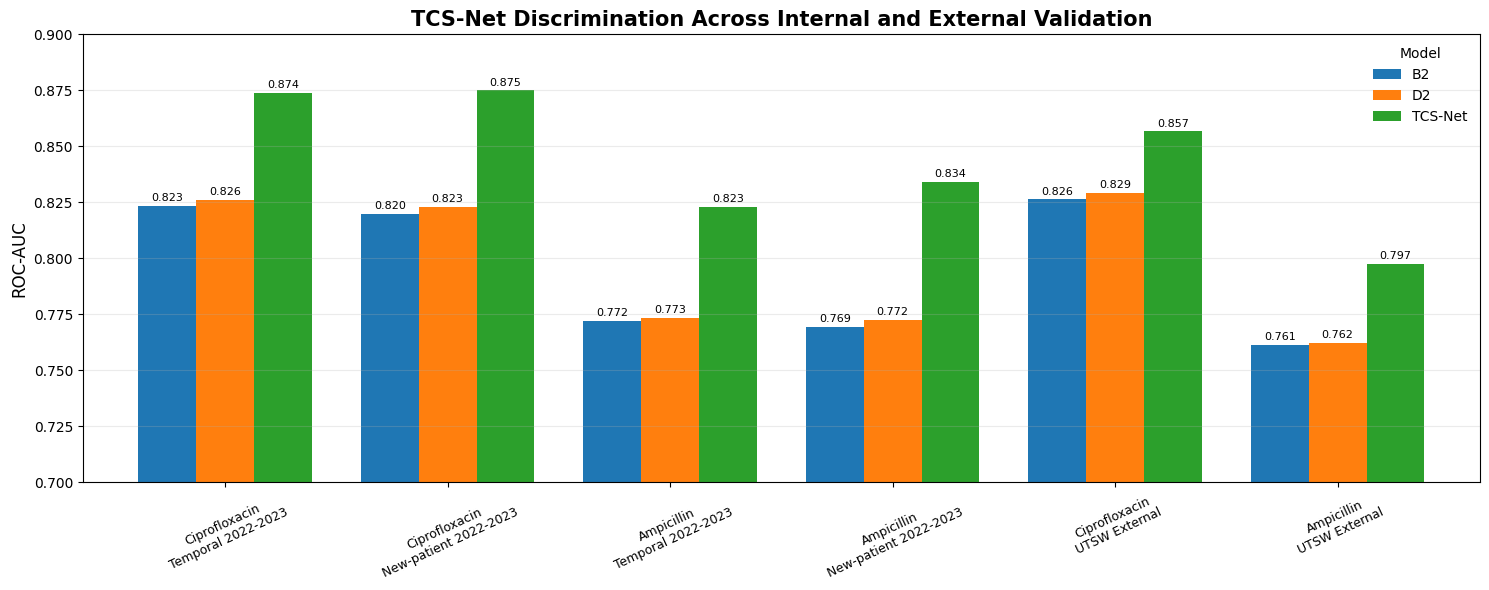

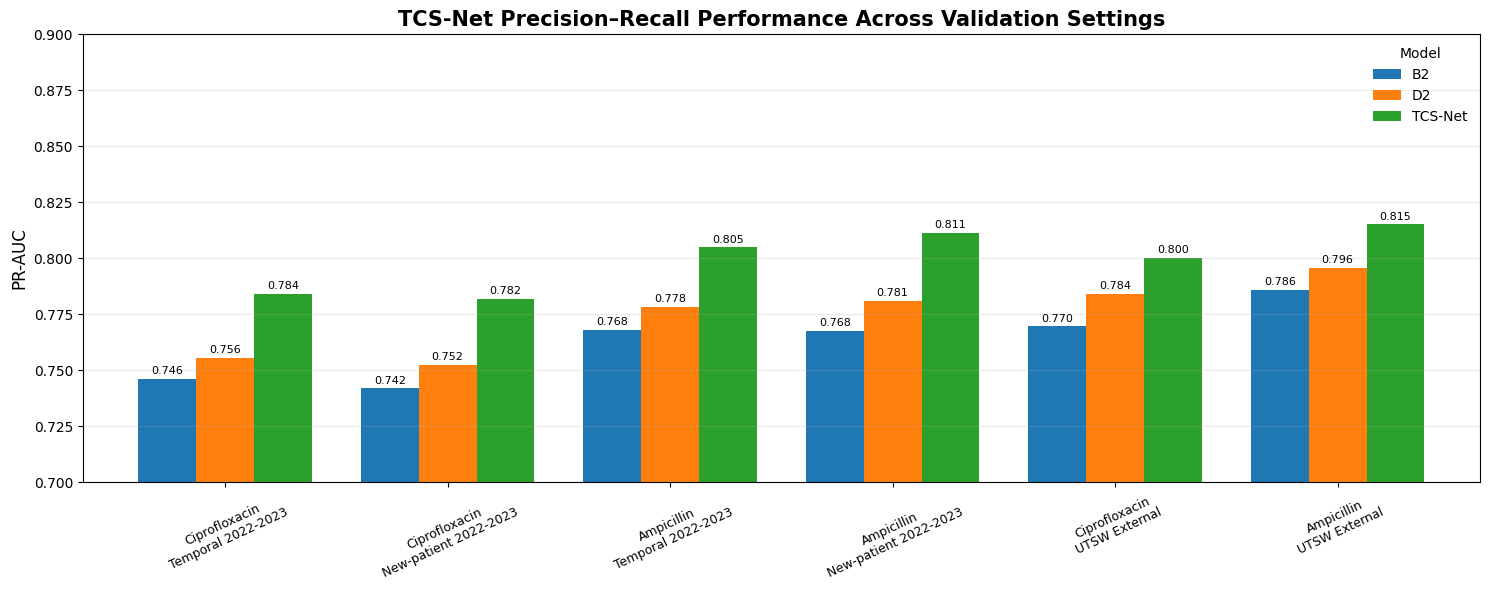

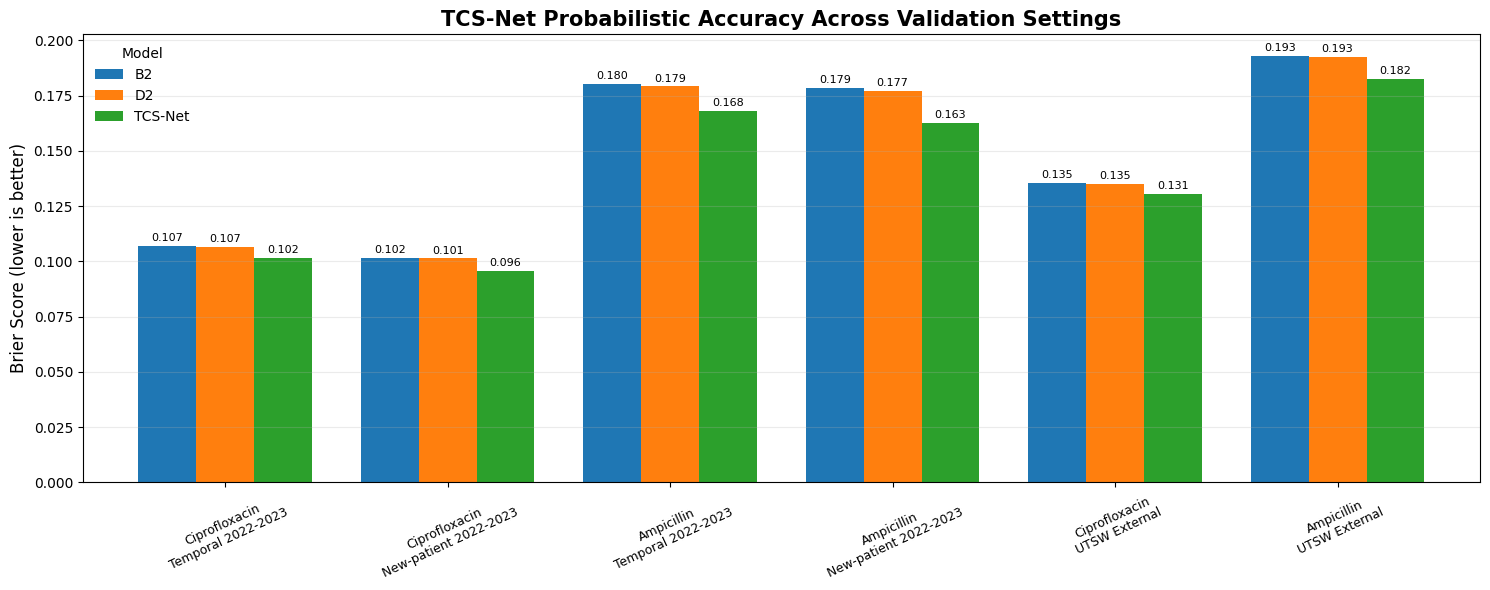

✅ Figure 1 files saved:
Figure_1A_ROC_AUC.png / .pdf
Figure_1B_PR_AUC.png / .pdf
Figure_1C_Brier.png / .pdf


In [117]:
# ==========================================
# FIGURE 1
# TCS-Net performance across internal
# and external validation settings
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# 1) Stanford results
# -----------------------------
fig1_stanford = stanford_absolute_results.copy()

fig1_stanford["Model_clean"] = (
    fig1_stanford["Model"]
    .replace({
        "B2 Same-drug + Time": "B2",
        "D2 Additive TCS-Net": "D2",
        "E Interaction TCS-Net": "TCS-Net"
    })
)

fig1_stanford["Scenario"] = (
    fig1_stanford["Target"]
    + "\n"
    + fig1_stanford["Validation"]
)


# -----------------------------
# 2) UTSW results
# -----------------------------
fig1_utsw = external_results_df.copy()

fig1_utsw["Model_clean"] = (
    fig1_utsw["Model"]
    .replace({
        "B2_SameDrug_TimeWindow": "B2",
        "D2_Additive_TCSNet": "D2",
        "E_Interaction_TCSNet": "TCS-Net"
    })
)

fig1_utsw["Scenario"] = (
    fig1_utsw["Target"]
    + "\nUTSW External"
)


# -----------------------------
# 3) Combine
# -----------------------------
figure1_data = pd.concat(
    [
        fig1_stanford[
            [
                "Scenario",
                "Model_clean",
                "ROC_AUC",
                "PR_AUC",
                "Brier_Score"
            ]
        ],
        fig1_utsw[
            [
                "Scenario",
                "Model_clean",
                "ROC_AUC",
                "PR_AUC",
                "Brier_Score"
            ]
        ]
    ],
    ignore_index=True
)


# Locked order for final presentation
scenario_order = [
    "Ciprofloxacin\nTemporal 2022-2023",
    "Ciprofloxacin\nNew-patient 2022-2023",
    "Ampicillin\nTemporal 2022-2023",
    "Ampicillin\nNew-patient 2022-2023",
    "Ciprofloxacin\nUTSW External",
    "Ampicillin\nUTSW External"
]

model_order = [
    "B2",
    "D2",
    "TCS-Net"
]


# ==========================================
# Plot helper
# ==========================================

def plot_metric(
    data,
    metric,
    ylabel,
    title,
    filename,
    higher_is_better=True
):

    pivot = (
        data
        .pivot(
            index="Scenario",
            columns="Model_clean",
            values=metric
        )
        .reindex(
            index=scenario_order,
            columns=model_order
        )
    )

    ax = pivot.plot(
        kind="bar",
        figsize=(15, 6),
        width=0.78
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold"
    )

    ax.set_ylabel(
        ylabel,
        fontsize=12
    )

    ax.set_xlabel("")

    ax.tick_params(
        axis="x",
        rotation=25,
        labelsize=9
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    ax.legend(
        title="Model",
        frameon=False
    )

    # Numeric labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.3f",
            padding=2,
            fontsize=8
        )

    # Sensible y-axis
    if metric in ["ROC_AUC", "PR_AUC"]:
        ax.set_ylim(0.70, 0.90)

    plt.tight_layout()

    plt.savefig(
        filename + ".png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        filename + ".pdf",
        bbox_inches="tight"
    )

    plt.show()


# ==========================================
# FIGURE 1A — ROC-AUC
# ==========================================

plot_metric(
    figure1_data,
    metric="ROC_AUC",
    ylabel="ROC-AUC",
    title=(
        "TCS-Net Discrimination Across "
        "Internal and External Validation"
    ),
    filename="Figure_1A_ROC_AUC"
)


# ==========================================
# FIGURE 1B — PR-AUC
# ==========================================

plot_metric(
    figure1_data,
    metric="PR_AUC",
    ylabel="PR-AUC",
    title=(
        "TCS-Net Precision–Recall Performance "
        "Across Validation Settings"
    ),
    filename="Figure_1B_PR_AUC"
)


# ==========================================
# FIGURE 1C — Brier Score
# Lower is better
# ==========================================

plot_metric(
    figure1_data,
    metric="Brier_Score",
    ylabel="Brier Score (lower is better)",
    title=(
        "TCS-Net Probabilistic Accuracy "
        "Across Validation Settings"
    ),
    filename="Figure_1C_Brier"
)


print("✅ Figure 1 files saved:")
print("Figure_1A_ROC_AUC.png / .pdf")
print("Figure_1B_PR_AUC.png / .pdf")
print("Figure_1C_Brier.png / .pdf")

In [118]:
# ==========================================
# FIGURE 2 PREPARATION
# Inspect Stanford bootstrap-results schema
# ==========================================

print("STANFORD IMPROVEMENT RESULTS")
print("----------------------------")

print(
    stanford_improvement_results.columns.tolist()
)

display(
    stanford_improvement_results
)

STANFORD IMPROVEMENT RESULTS
----------------------------
['Target', 'Validation', 'Comparison', 'Delta_ROC', 'ROC_CI_low', 'ROC_CI_high', 'Delta_PR', 'PR_CI_low', 'PR_CI_high', 'Brier_Improvement', 'Brier_CI_low', 'Brier_CI_high']


,Target,Validation,Comparison,Delta_ROC,ROC_CI_low,ROC_CI_high,Delta_PR,PR_CI_low,PR_CI_high,Brier_Improvement,Brier_CI_low,Brier_CI_high
0,Ciprofloxacin,Temporal 2022-2023,E vs B2,0.050105,0.036098,0.064812,0.038015,0.028146,0.048490,0.005310,0.003547,0.007104
1,Ciprofloxacin,Temporal 2022-2023,E vs D2,0.047351,0.033022,0.061193,0.028406,0.016672,0.039879,0.004985,0.003306,0.006720
2,Ciprofloxacin,New-patient 2022-2023,E vs B2,0.055444,0.035343,0.075658,0.040171,0.028614,0.053074,0.005872,0.003673,0.008175
3,Ciprofloxacin,New-patient 2022-2023,E vs D2,0.052172,0.032680,0.072442,0.029410,0.016070,0.043141,0.005601,0.003472,0.007844
4,Ampicillin,Temporal 2022-2023,E vs B2,0.050881,0.040547,0.062239,0.036709,0.029465,0.044012,0.012281,0.009414,0.015262
5,Ampicillin,Temporal 2022-2023,E vs D2,0.049772,0.038513,0.060917,0.026554,0.017321,0.035590,0.011126,0.008202,0.013986
6,Ampicillin,New-patient 2022-2023,E vs B2,0.064574,0.050118,0.080315,0.043526,0.034954,0.052374,0.015897,0.012091,0.019782
7,Ampicillin,New-patient 2022-2023,E vs D2,0.061608,0.047883,0.076411,0.030388,0.020834,0.041499,0.014502,0.010800,0.018098


In [119]:
# ==========================================
# FIGURE 2 DATA
# TCS-Net (E) vs B2
# Stanford + Independent UTSW
# ==========================================

# Stanford: keep E vs B2 only
figure2_stanford = (
    stanford_improvement_results[
        stanford_improvement_results["Comparison"] == "E vs B2"
    ]
    .copy()
)

figure2_stanford["Scenario"] = (
    figure2_stanford["Target"]
    + "\n"
    + figure2_stanford["Validation"]
)


# ------------------------------------------
# Helper: convert UTSW bootstrap dictionary
# into one result row
# ------------------------------------------

def external_bootstrap_row(
    target,
    bootstrap_result
):

    return {
        "Target": target,
        "Validation": "UTSW External",
        "Comparison": "E vs B2",

        "Delta_ROC":
            bootstrap_result[
                "ROC_AUC_improvement"
            ]["difference"],

        "ROC_CI_low":
            bootstrap_result[
                "ROC_AUC_improvement"
            ]["CI_low"],

        "ROC_CI_high":
            bootstrap_result[
                "ROC_AUC_improvement"
            ]["CI_high"],

        "Delta_PR":
            bootstrap_result[
                "PR_AUC_improvement"
            ]["difference"],

        "PR_CI_low":
            bootstrap_result[
                "PR_AUC_improvement"
            ]["CI_low"],

        "PR_CI_high":
            bootstrap_result[
                "PR_AUC_improvement"
            ]["CI_high"],

        "Brier_Improvement":
            bootstrap_result[
                "Brier_improvement"
            ]["difference"],

        "Brier_CI_low":
            bootstrap_result[
                "Brier_improvement"
            ]["CI_low"],

        "Brier_CI_high":
            bootstrap_result[
                "Brier_improvement"
            ]["CI_high"]
    }


figure2_utsw = pd.DataFrame([
    external_bootstrap_row(
        "Ciprofloxacin",
        utsw_cipro_E_vs_B2
    ),

    external_bootstrap_row(
        "Ampicillin",
        utsw_amp_E_vs_B2
    )
])

figure2_utsw["Scenario"] = (
    figure2_utsw["Target"]
    + "\nUTSW External"
)


# ------------------------------------------
# Combine
# ------------------------------------------

figure2_data = pd.concat(
    [
        figure2_stanford,
        figure2_utsw
    ],
    ignore_index=True
)


scenario_order = [
    "Ciprofloxacin\nTemporal 2022-2023",
    "Ciprofloxacin\nNew-patient 2022-2023",
    "Ampicillin\nTemporal 2022-2023",
    "Ampicillin\nNew-patient 2022-2023",
    "Ciprofloxacin\nUTSW External",
    "Ampicillin\nUTSW External"
]

figure2_data["Scenario"] = pd.Categorical(
    figure2_data["Scenario"],
    categories=scenario_order,
    ordered=True
)

figure2_data = (
    figure2_data
    .sort_values("Scenario")
    .reset_index(drop=True)
)

display(
    figure2_data[
        [
            "Scenario",
            "Delta_ROC",
            "ROC_CI_low",
            "ROC_CI_high",
            "Delta_PR",
            "PR_CI_low",
            "PR_CI_high",
            "Brier_Improvement",
            "Brier_CI_low",
            "Brier_CI_high"
        ]
    ].round(4)
)

,Scenario,Delta_ROC,ROC_CI_low,ROC_CI_high,Delta_PR,PR_CI_low,PR_CI_high,Brier_Improvement,Brier_CI_low,Brier_CI_high
0,Ciprofloxacin\nTemporal 2022-2023,0.0501,0.0361,0.0648,0.0380,0.0281,0.0485,0.0053,0.0035,0.0071
1,Ciprofloxacin\nNew-patient 2022-2023,0.0554,0.0353,0.0757,0.0402,0.0286,0.0531,0.0059,0.0037,0.0082
2,Ampicillin\nTemporal 2022-2023,0.0509,0.0405,0.0622,0.0367,0.0295,0.0440,0.0123,0.0094,0.0153
3,Ampicillin\nNew-patient 2022-2023,0.0646,0.0501,0.0803,0.0435,0.0350,0.0524,0.0159,0.0121,0.0198
4,Ciprofloxacin\nUTSW External,0.0303,0.0230,0.0377,0.0306,0.0252,0.0356,0.0049,0.0036,0.0062
5,Ampicillin\nUTSW External,0.0361,0.0298,0.0430,0.0293,0.0243,0.0341,0.0106,0.0087,0.0127


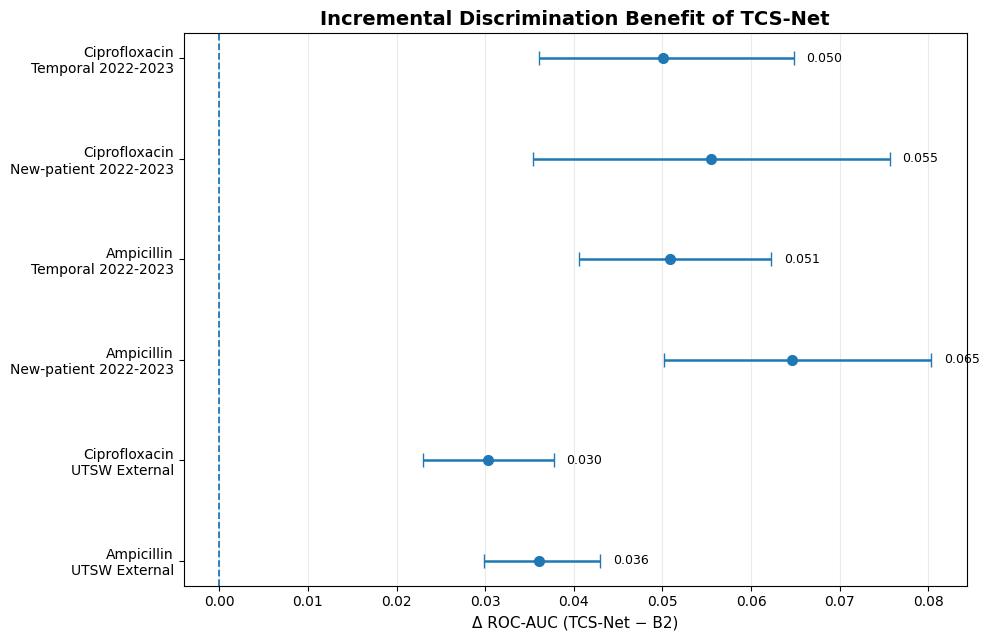

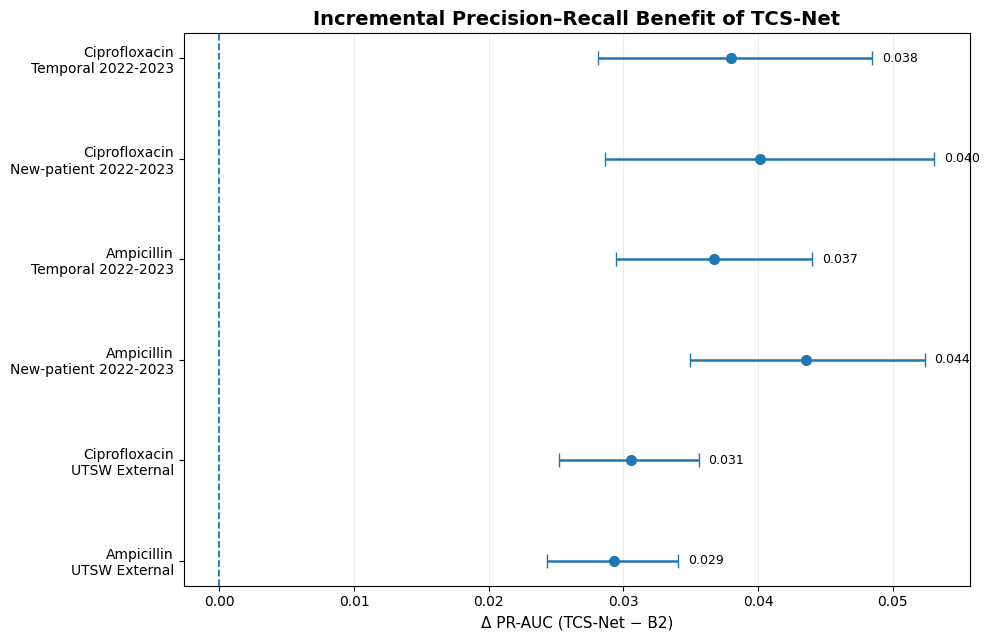

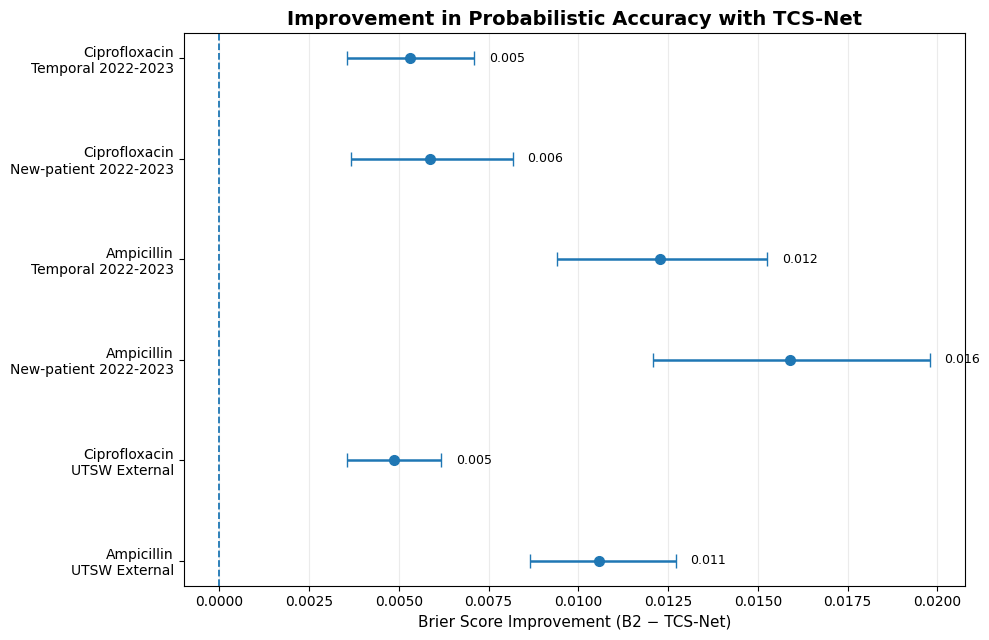

✅ Figure 2 saved:
Figure_2A_Delta_ROC.png / .pdf
Figure_2B_Delta_PR.png / .pdf
Figure_2C_Brier_Improvement.png / .pdf


In [120]:
# ==========================================
# FIGURE 2
# Patient-level bootstrap improvement
# TCS-Net vs B2
# ==========================================

import matplotlib.pyplot as plt
import numpy as np


def forest_plot(
    data,
    estimate_col,
    low_col,
    high_col,
    xlabel,
    title,
    filename
):

    plot_df = data.copy()

    # Reverse so first scenario appears at top
    plot_df = plot_df.iloc[::-1].reset_index(drop=True)

    y = np.arange(len(plot_df))

    estimates = plot_df[estimate_col].values
    lows = plot_df[low_col].values
    highs = plot_df[high_col].values

    lower_error = estimates - lows
    upper_error = highs - estimates

    fig, ax = plt.subplots(
        figsize=(10, 6.5)
    )

    ax.errorbar(
        estimates,
        y,
        xerr=[
            lower_error,
            upper_error
        ],
        fmt="o",
        capsize=5,
        markersize=7,
        linewidth=1.8
    )

    # Null effect
    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.3
    )

    ax.set_yticks(y)

    ax.set_yticklabels(
        plot_df["Scenario"],
        fontsize=10
    )

    ax.set_xlabel(
        xlabel,
        fontsize=11
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.grid(
        axis="x",
        alpha=0.25
    )

    # Add effect estimate labels
    offset = (
        highs.max() - lows.min()
    ) * 0.025

    for i in range(len(plot_df)):

        ax.text(
            highs[i] + offset,
            y[i],
            f"{estimates[i]:.3f}",
            va="center",
            fontsize=9
        )

    plt.tight_layout()

    plt.savefig(
        filename + ".png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        filename + ".pdf",
        bbox_inches="tight"
    )

    plt.show()


# ==========================================
# Figure 2A — ROC-AUC improvement
# ==========================================

forest_plot(
    figure2_data,
    estimate_col="Delta_ROC",
    low_col="ROC_CI_low",
    high_col="ROC_CI_high",
    xlabel="Δ ROC-AUC (TCS-Net − B2)",
    title=(
        "Incremental Discrimination Benefit "
        "of TCS-Net"
    ),
    filename="Figure_2A_Delta_ROC"
)


# ==========================================
# Figure 2B — PR-AUC improvement
# ==========================================

forest_plot(
    figure2_data,
    estimate_col="Delta_PR",
    low_col="PR_CI_low",
    high_col="PR_CI_high",
    xlabel="Δ PR-AUC (TCS-Net − B2)",
    title=(
        "Incremental Precision–Recall Benefit "
        "of TCS-Net"
    ),
    filename="Figure_2B_Delta_PR"
)


# ==========================================
# Figure 2C — Brier improvement
# Positive = better
# ==========================================

forest_plot(
    figure2_data,
    estimate_col="Brier_Improvement",
    low_col="Brier_CI_low",
    high_col="Brier_CI_high",
    xlabel="Brier Score Improvement (B2 − TCS-Net)",
    title=(
        "Improvement in Probabilistic Accuracy "
        "with TCS-Net"
    ),
    filename="Figure_2C_Brier_Improvement"
)


print("✅ Figure 2 saved:")
print("Figure_2A_Delta_ROC.png / .pdf")
print("Figure_2B_Delta_PR.png / .pdf")
print("Figure_2C_Brier_Improvement.png / .pdf")

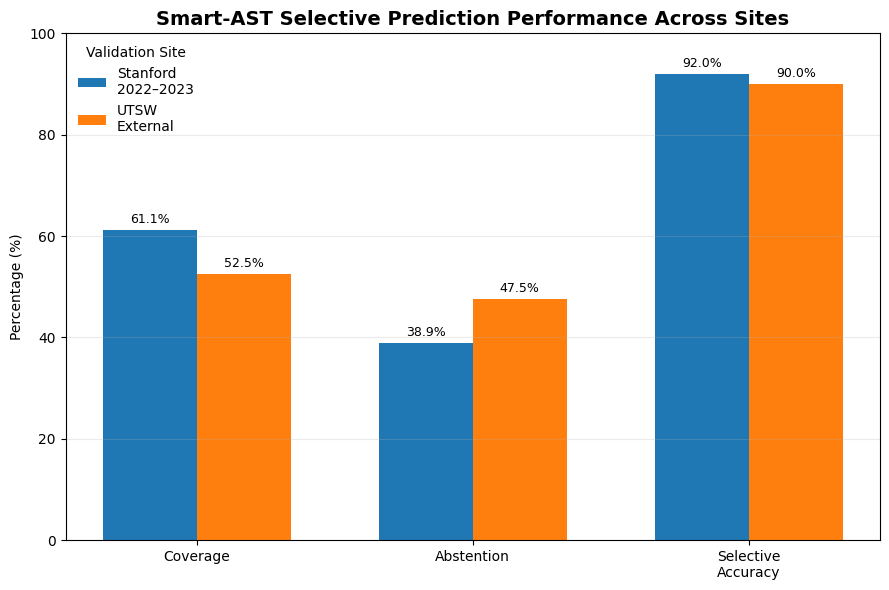

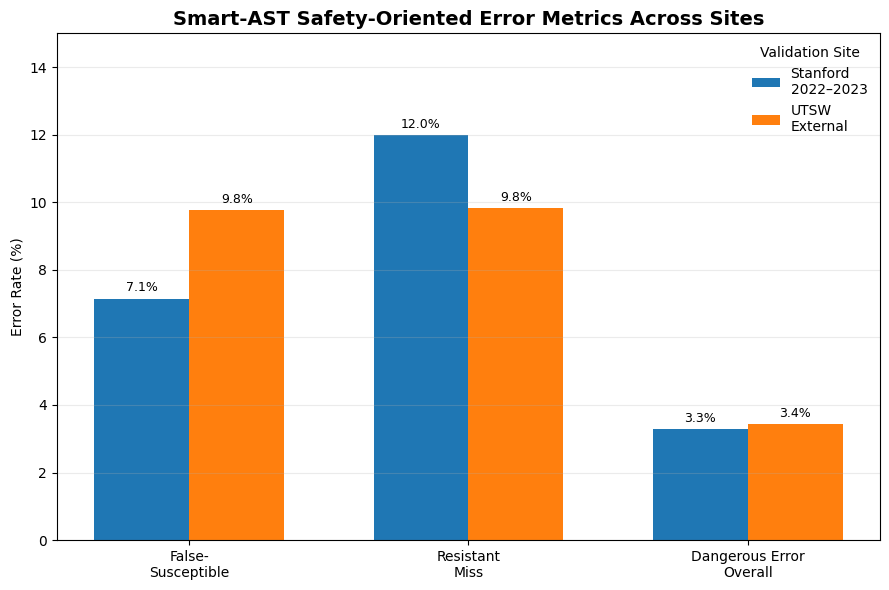

✅ Figure 3 saved:
Figure_3A_SmartAST_Performance.png / .pdf
Figure_3B_SmartAST_Safety.png / .pdf


In [121]:
# ==========================================
# FIGURE 3
# Smart-AST transportability
# Stanford vs independent UTSW
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

smart_plot = smart_ast_site_comparison.copy()

smart_plot["Site"] = smart_plot["Site"].replace({
    "Stanford 2022-2023": "Stanford\n2022–2023",
    "UTSW External": "UTSW\nExternal"
})


# ==========================================
# FIGURE 3A
# Coverage, abstention, selective accuracy
# ==========================================

metrics_a = [
    "Coverage",
    "Abstention_Rate",
    "Selective_Accuracy"
]

labels_a = [
    "Coverage",
    "Abstention",
    "Selective\nAccuracy"
]

x = np.arange(len(labels_a))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 6))

for i, (_, row) in enumerate(smart_plot.iterrows()):

    values = [
        row["Coverage"],
        row["Abstention_Rate"],
        row["Selective_Accuracy"]
    ]

    bars = ax.bar(
        x + (i - 0.5) * width,
        np.array(values) * 100,
        width,
        label=row["Site"]
    )

    ax.bar_label(
        bars,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

ax.set_xticks(x)
ax.set_xticklabels(labels_a)

ax.set_ylabel("Percentage (%)")

ax.set_title(
    "Smart-AST Selective Prediction Performance Across Sites",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylim(0, 100)

ax.legend(
    title="Validation Site",
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "Figure_3A_SmartAST_Performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_3A_SmartAST_Performance.pdf",
    bbox_inches="tight"
)

plt.show()


# ==========================================
# FIGURE 3B
# Safety-oriented error metrics
# ==========================================

metrics_b = [
    "False_Susceptible_Rate",
    "Resistant_Miss_Rate",
    "Dangerous_Error_Overall"
]

labels_b = [
    "False-\nSusceptible",
    "Resistant\nMiss",
    "Dangerous Error\nOverall"
]

x = np.arange(len(labels_b))

fig, ax = plt.subplots(figsize=(9, 6))

for i, (_, row) in enumerate(smart_plot.iterrows()):

    values = [
        row["False_Susceptible_Rate"],
        row["Resistant_Miss_Rate"],
        row["Dangerous_Error_Overall"]
    ]

    bars = ax.bar(
        x + (i - 0.5) * width,
        np.array(values) * 100,
        width,
        label=row["Site"]
    )

    ax.bar_label(
        bars,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

ax.set_xticks(x)
ax.set_xticklabels(labels_b)

ax.set_ylabel("Error Rate (%)")

ax.set_title(
    "Smart-AST Safety-Oriented Error Metrics Across Sites",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylim(0, 15)

ax.legend(
    title="Validation Site",
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "Figure_3B_SmartAST_Safety.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_3B_SmartAST_Safety.pdf",
    bbox_inches="tight"
)

plt.show()


print("✅ Figure 3 saved:")
print("Figure_3A_SmartAST_Performance.png / .pdf")
print("Figure_3B_SmartAST_Safety.png / .pdf")

,Ciprofloxacin,time_window,N,Future_Resistance_Rate
0,Inconclusive,15-90 days,0,NaN
1,Inconclusive,91-180 days,0,NaN
2,Inconclusive,181-365 days,0,NaN
3,Inconclusive,366-730 days,0,NaN
4,Inconclusive,>730 days,0,NaN
5,Intermediate,15-90 days,0,NaN
6,Intermediate,91-180 days,0,NaN
7,Intermediate,181-365 days,0,NaN
8,Intermediate,366-730 days,0,NaN
9,Intermediate,>730 days,0,NaN


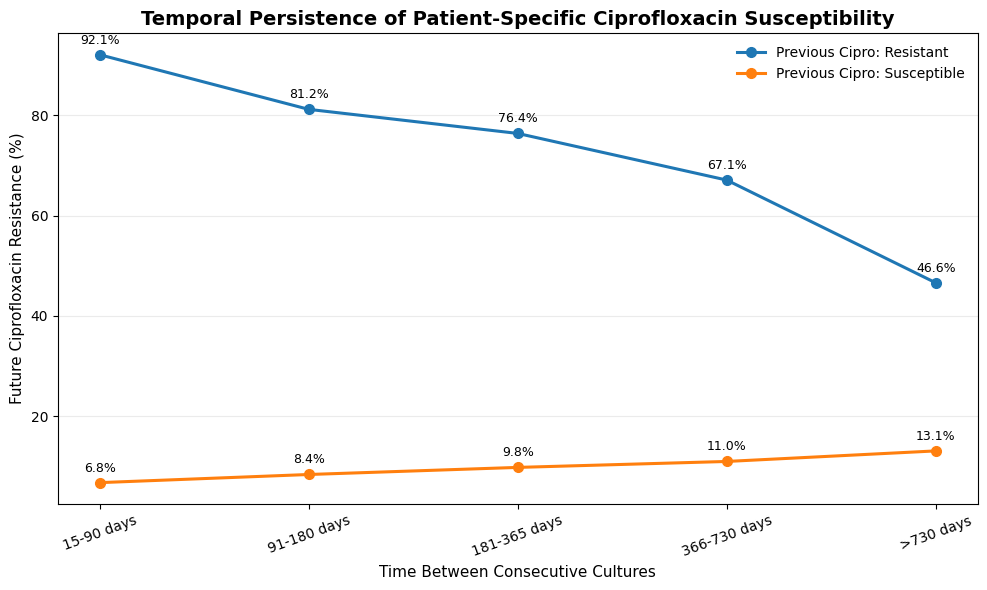

✅ Figure 4 saved: Figure_4_Temporal_Cipro_Memory.png / .pdf


In [122]:
# ==========================================
# FIGURE 4
# Patient-level temporal susceptibility memory
# Ciprofloxacin
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------
# Robustly identify target
# ------------------------------------------

if "target" in cipro_data.columns:
    fig4_data = cipro_data.copy()
    fig4_data["Future_Cipro_R"] = fig4_data["target"]

elif "next_Ciprofloxacin" in cipro_data.columns:
    fig4_data = cipro_data.copy()
    fig4_data["Future_Cipro_R"] = (
        fig4_data["next_Ciprofloxacin"] == "Resistant"
    ).astype(int)

else:
    raise ValueError(
        "Could not identify future Ciprofloxacin target."
    )


# ------------------------------------------
# Time-window column
# ------------------------------------------

if "time_window_str" in fig4_data.columns:
    time_col = "time_window_str"

elif "time_window" in fig4_data.columns:
    time_col = "time_window"

else:
    raise ValueError(
        "Could not identify time-window column."
    )


window_order = [
    "15-90 days",
    "91-180 days",
    "181-365 days",
    "366-730 days",
    ">730 days"
]


# ------------------------------------------
# Summarize
# ------------------------------------------

temporal_memory = (
    fig4_data[
        fig4_data["Ciprofloxacin"].isin(
            ["Susceptible", "Resistant"]
        )
    ]
    .groupby(
        [
            "Ciprofloxacin",
            time_col
        ],
        observed=False
    )
    .agg(
        N=("Future_Cipro_R", "size"),
        Future_Resistance_Rate=(
            "Future_Cipro_R",
            "mean"
        )
    )
    .reset_index()
)


temporal_memory[time_col] = pd.Categorical(
    temporal_memory[time_col],
    categories=window_order,
    ordered=True
)

temporal_memory = temporal_memory.sort_values(
    [
        "Ciprofloxacin",
        time_col
    ]
)

display(
    temporal_memory.round(4)
)


# ==========================================
# Plot
# ==========================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for previous_status in [
    "Resistant",
    "Susceptible"
]:

    temp = temporal_memory[
        temporal_memory["Ciprofloxacin"]
        == previous_status
    ]

    ax.plot(
        temp[time_col].astype(str),
        temp["Future_Resistance_Rate"] * 100,
        marker="o",
        linewidth=2.2,
        markersize=7,
        label=f"Previous Cipro: {previous_status}"
    )

    for _, row in temp.iterrows():

        ax.annotate(
            f"{row['Future_Resistance_Rate']*100:.1f}%",
            (
                str(row[time_col]),
                row["Future_Resistance_Rate"] * 100
            ),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9
        )


ax.set_ylabel(
    "Future Ciprofloxacin Resistance (%)",
    fontsize=11
)

ax.set_xlabel(
    "Time Between Consecutive Cultures",
    fontsize=11
)

ax.set_title(
    "Temporal Persistence of Patient-Specific "
    "Ciprofloxacin Susceptibility",
    fontsize=14,
    fontweight="bold"
)

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    "Figure_4_Temporal_Cipro_Memory.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_4_Temporal_Cipro_Memory.pdf",
    bbox_inches="tight"
)

plt.show()

print(
    "✅ Figure 4 saved: "
    "Figure_4_Temporal_Cipro_Memory.png / .pdf"
)

In [123]:
# ==========================================
# STREAMLIT DEMO — MODEL AUDIT
# ==========================================

print("E_dev_model type:")
print(type(E_dev_model))

print("\nplatt_strict type:")
print(type(platt_strict))

print("\nE_features:")
print(E_features)

print("\nThresholds:")
print("LOW :", FINAL_LOW_THRESHOLD)
print("HIGH:", FINAL_HIGH_THRESHOLD)

print("\nModel pipeline:")
print(E_dev_model)

E_dev_model type:
<class 'sklearn.pipeline.Pipeline'>

platt_strict type:
<class 'sklearn.linear_model._logistic.LogisticRegression'>

E_features:
['Ciprofloxacin', 'time_window_str', 'Ampicillin', 'Trimethoprim/Sulfamethoxazole', 'Gentamicin', 'Cefazolin', 'Ceftriaxone', 'INT_Ampicillin', 'INT_Trimethoprim/Sulfamethoxazole', 'INT_Gentamicin', 'INT_Cefazolin', 'INT_Ceftriaxone']

Thresholds:
LOW : 0.1
HIGH: 0.8

Model pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))])

In [124]:
print("\nPlatt object:")
print(platt_strict)

if hasattr(platt_strict, "coef_"):
    print("coef_:", platt_strict.coef_)

if hasattr(platt_strict, "intercept_"):
    print("intercept_:", platt_strict.intercept_)


Platt object:
LogisticRegression(C=1000000.0, max_iter=2000)
coef_: [[1.088757]]
intercept_: [0.09480485]


In [125]:
# ==========================================
# STREAMLIT APP BUNDLE
# Exact Stanford Smart-AST pipeline
# ==========================================

import pickle

tcsnet_app_bundle = {
    "model": E_dev_model,
    "platt_calibrator": platt_strict,
    "features": E_features,
    "low_threshold": FINAL_LOW_THRESHOLD,
    "high_threshold": FINAL_HIGH_THRESHOLD,

    "target": "Ciprofloxacin",

    "cross_antibiotics": [
        "Ampicillin",
        "Trimethoprim/Sulfamethoxazole",
        "Gentamicin",
        "Cefazolin",
        "Ceftriaxone"
    ],

    "time_windows": [
        "15-90 days",
        "91-180 days",
        "181-365 days",
        "366-730 days",
        ">730 days"
    ],

    "metadata": {
        "model_name":
            "TCS-Net Interaction Model",

        "training_site":
            "Stanford",

        "model_training_period":
            "2008-2019",

        "calibration_period":
            "2020",

        "threshold_selection_period":
            "2021",

        "low_threshold":
            0.10,

        "high_threshold":
            0.80,

        "note":
            "Research demonstration only. "
            "Not for clinical decision-making."
    }
}


with open(
    "tcsnet_app_bundle.pkl",
    "wb"
) as f:

    pickle.dump(
        tcsnet_app_bundle,
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )


print("✅ App bundle saved")
print("File: tcsnet_app_bundle.pkl")
print("Target: Ciprofloxacin")
print("Low threshold :", FINAL_LOW_THRESHOLD)
print("High threshold:", FINAL_HIGH_THRESHOLD)

✅ App bundle saved
File: tcsnet_app_bundle.pkl
Target: Ciprofloxacin
Low threshold : 0.1
High threshold: 0.8


In [126]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import pickle


# ==========================================
# PAGE CONFIG
# ==========================================

st.set_page_config(
    page_title="TCS-Net Smart-AST",
    page_icon="🧬",
    layout="wide"
)


# ==========================================
# LOAD MODEL
# ==========================================

@st.cache_resource
def load_bundle():

    with open(
        "tcsnet_app_bundle.pkl",
        "rb"
    ) as f:

        return pickle.load(f)


bundle = load_bundle()

model = bundle["model"]
platt = bundle["platt_calibrator"]

FEATURES = bundle["features"]

LOW_THRESHOLD = bundle["low_threshold"]
HIGH_THRESHOLD = bundle["high_threshold"]

cross_antibiotics = bundle[
    "cross_antibiotics"
]


# ==========================================
# FUNCTIONS
# ==========================================

def apply_platt_calibration(
    raw_probability
):

    eps = 1e-6

    p = np.clip(
        raw_probability,
        eps,
        1 - eps
    )

    logit = np.log(
        p / (1 - p)
    )

    calibrated = (
        platt.predict_proba(
            np.array([[logit]])
        )[0, 1]
    )

    return calibrated


def create_interactions(
    row
):

    previous_cipro = row[
        "Ciprofloxacin"
    ]

    time_window = row[
        "time_window_str"
    ]

    for drug in cross_antibiotics:

        drug_status = row[drug]

        row[
            f"INT_{drug}"
        ] = (
            f"{previous_cipro}"
            f"__{drug_status}"
            f"__{time_window}"
        )

    return row


def smart_ast_decision(
    probability
):

    if probability <= LOW_THRESHOLD:

        return (
            "Likely Susceptible",
            "High-confidence susceptible-region prediction"
        )

    elif probability >= HIGH_THRESHOLD:

        return (
            "Likely Resistant",
            "High-confidence resistant-region prediction"
        )

    else:

        return (
            "Laboratory AST Required",
            "Prediction lies in the abstention region"
        )


# ==========================================
# HEADER
# ==========================================

st.title(
    "🧬 TCS-Net: Temporal Cross-Antibiotic Susceptibility Network"
)

st.markdown(
    """
    **Research demonstration of patient-specific temporal
    cross-antibiotic susceptibility prediction.**

    TCS-Net estimates the probability that a **future/recurrent
    E. coli urine isolate will be resistant to Ciprofloxacin**
    using the patient's previous AST profile and time between cultures.
    """
)

st.warning(
    "Research demo only — not a clinical recommendation, "
    "not a replacement for laboratory AST, and not validated "
    "for treatment selection."
)


# ==========================================
# SIDEBAR
# ==========================================

with st.sidebar:

    st.header("Model Information")

    st.write(
        "**Target:** Ciprofloxacin resistance"
    )

    st.write(
        "**Model:** TCS-Net interaction model"
    )

    st.write(
        "**Development site:** Stanford"
    )

    st.write(
        "**External validation:** UTSW"
    )

    st.write(
        f"**Smart-AST thresholds:** "
        f"{LOW_THRESHOLD:.2f} / "
        f"{HIGH_THRESHOLD:.2f}"
    )

    st.divider()

    st.caption(
        "A low-confidence prediction triggers "
        "abstention: Laboratory AST Required."
    )


# ==========================================
# USER INPUT
# ==========================================

st.header(
    "1. Previous Patient AST Profile"
)

status_options = [
    "Susceptible",
    "Resistant",
    "Missing"
]


col1, col2, col3 = st.columns(3)


with col1:

    previous_cipro = st.selectbox(
        "Previous Ciprofloxacin",
        status_options,
        index=0
    )

    ampicillin = st.selectbox(
        "Previous Ampicillin",
        status_options,
        index=0
    )


with col2:

    tmpsmx = st.selectbox(
        "Previous TMP-SMX",
        status_options,
        index=0
    )

    gentamicin = st.selectbox(
        "Previous Gentamicin",
        status_options,
        index=0
    )


with col3:

    cefazolin = st.selectbox(
        "Previous Cefazolin",
        status_options,
        index=0
    )

    ceftriaxone = st.selectbox(
        "Previous Ceftriaxone",
        status_options,
        index=0
    )


st.header(
    "2. Time Since Previous Culture"
)

time_window = st.selectbox(
    "Time interval",
    bundle["time_windows"],
    index=0
)


# ==========================================
# PREDICTION
# ==========================================

st.divider()

if st.button(
    "Run TCS-Net Prediction",
    type="primary",
    use_container_width=True
):

    input_row = {
        "Ciprofloxacin":
            previous_cipro,

        "time_window_str":
            time_window,

        "Ampicillin":
            ampicillin,

        "Trimethoprim/Sulfamethoxazole":
            tmpsmx,

        "Gentamicin":
            gentamicin,

        "Cefazolin":
            cefazolin,

        "Ceftriaxone":
            ceftriaxone
    }


    # --------------------------------------
    # Create locked interaction features
    # --------------------------------------

    input_row = create_interactions(
        input_row
    )

    input_df = pd.DataFrame([
        input_row
    ])

    input_df = input_df[
        FEATURES
    ]


    # --------------------------------------
    # Raw Stanford model probability
    # --------------------------------------

    raw_probability = (
        model.predict_proba(
            input_df
        )[0, 1]
    )


    # --------------------------------------
    # Stanford Platt calibration
    # --------------------------------------

    calibrated_probability = (
        apply_platt_calibration(
            raw_probability
        )
    )


    decision, explanation = (
        smart_ast_decision(
            calibrated_probability
        )
    )


    # ======================================
    # RESULTS
    # ======================================

    st.header(
        "3. Prediction Result"
    )

    metric1, metric2, metric3 = (
        st.columns(3)
    )


    with metric1:

        st.metric(
            "Raw P(Resistance)",
            f"{raw_probability:.1%}"
        )


    with metric2:

        st.metric(
            "Calibrated P(Resistance)",
            f"{calibrated_probability:.1%}"
        )


    with metric3:

        st.metric(
            "Smart-AST Decision",
            decision
        )


    # --------------------------------------
    # Visual probability
    # --------------------------------------

    st.progress(
        float(
            calibrated_probability
        )
    )


    # --------------------------------------
    # Decision explanation
    # --------------------------------------

    if decision == "Likely Susceptible":

        st.success(
            "Smart-AST result: "
            "**Likely Susceptible**"
        )

    elif decision == "Likely Resistant":

        st.error(
            "Smart-AST result: "
            "**Likely Resistant**"
        )

    else:

        st.warning(
            "Smart-AST abstains: "
            "**Laboratory AST Required**"
        )


    st.caption(
        explanation
    )


    # ======================================
    # THRESHOLD EXPLANATION
    # ======================================

    st.subheader(
        "Smart-AST Safety Layer"
    )

    threshold_table = pd.DataFrame({
        "Probability Region": [
            f"≤ {LOW_THRESHOLD:.2f}",
            (
                f"{LOW_THRESHOLD:.2f} "
                f"to {HIGH_THRESHOLD:.2f}"
            ),
            f"≥ {HIGH_THRESHOLD:.2f}"
        ],

        "System Action": [
            "Likely Susceptible",
            "Laboratory AST Required",
            "Likely Resistant"
        ]
    })

    st.dataframe(
        threshold_table,
        use_container_width=True,
        hide_index=True
    )


    # ======================================
    # INPUT SUMMARY
    # ======================================

    with st.expander(
        "View model input"
    ):

        display_input = pd.DataFrame({
            "Variable": [
                "Previous Ciprofloxacin",
                "Previous Ampicillin",
                "Previous TMP-SMX",
                "Previous Gentamicin",
                "Previous Cefazolin",
                "Previous Ceftriaxone",
                "Time interval"
            ],

            "Value": [
                previous_cipro,
                ampicillin,
                tmpsmx,
                gentamicin,
                cefazolin,
                ceftriaxone,
                time_window
            ]
        })

        st.dataframe(
            display_input,
            use_container_width=True,
            hide_index=True
        )


# ==========================================
# FOOTER
# ==========================================

st.divider()

st.caption(
    "TCS-Net models patient-level temporal "
    "cross-antibiotic susceptibility associations. "
    "Same species does not imply the same bacterial lineage, "
    "and predictions should not be interpreted causally."
)

Writing app.py


In [127]:
!ls -lh app.py tcsnet_app_bundle.pkl

-rw-r--r-- 1 root root 9.2K Aug 17 17:15 app.py
-rw-r--r-- 1 root root  14K Aug 17 17:15 tcsnet_app_bundle.pkl


In [128]:
!ls -lh app.py tcsnet_app_bundle.pkl


-rw-r--r-- 1 root root 9.2K Aug 17 17:15 app.py
-rw-r--r-- 1 root root  14K Aug 17 17:15 tcsnet_app_bundle.pkl


In [129]:
!pip -q install streamlit

import subprocess
import time

# Stop any old Streamlit process
!pkill -f streamlit || true

# Start app in background
streamlit_process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port",
        "8501",
        "--server.headless",
        "true"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

time.sleep(5)

print("✅ Streamlit server started on port 8501")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 70.5 MB/s eta 0:00:00
^C
✅ Streamlit server started on port 8501


In [130]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 \
    -O /usr/local/bin/cloudflared

!chmod +x /usr/local/bin/cloudflared

import subprocess
import re
import time

tunnel_process = subprocess.Popen(
    [
        "cloudflared",
        "tunnel",
        "--url",
        "http://localhost:8501"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

public_url = None

for _ in range(40):
    line = tunnel_process.stdout.readline()

    if line:
        print(line.strip())

        match = re.search(
            r"https://[a-zA-Z0-9\-]+\.trycloudflare\.com",
            line
        )

        if match:
            public_url = match.group(0)
            break

    time.sleep(0.5)

if public_url:
    print("\n🚀 TCS-Net Live Demo:")
    print(public_url)
else:
    print(
        "\n⚠️ URL not detected yet. "
        "Run the next diagnostic cell."
    )

2026-08-17T17:23:11Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-17T17:23:11Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-17T17:23:19Z INF +--------------------------------------------------------------------------------------------+
2026-08-17T17:23:19Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-17T17:23:19Z INF |  https://reproduce-incl-does-reflections.trycloudflare

In [131]:
# ==========================================
# FIND 3 CLEAN DEMO PROFILES
# Susceptible / Abstain / Resistant
# ==========================================

import itertools
import pandas as pd
import numpy as np

statuses = [
    "Susceptible",
    "Resistant"
]

time_windows_demo = [
    "15-90 days",
    "91-180 days",
    "181-365 days",
    "366-730 days",
    ">730 days"
]

rows = []

for values in itertools.product(
    statuses,
    statuses,
    statuses,
    statuses,
    statuses,
    statuses,
    time_windows_demo
):

    (
        cipro,
        amp,
        tmpsmx,
        gent,
        cefaz,
        ceftriax,
        window
    ) = values

    row = {
        "Ciprofloxacin": cipro,
        "time_window_str": window,
        "Ampicillin": amp,
        "Trimethoprim/Sulfamethoxazole": tmpsmx,
        "Gentamicin": gent,
        "Cefazolin": cefaz,
        "Ceftriaxone": ceftriax
    }

    for drug in [
        "Ampicillin",
        "Trimethoprim/Sulfamethoxazole",
        "Gentamicin",
        "Cefazolin",
        "Ceftriaxone"
    ]:

        row[f"INT_{drug}"] = (
            f"{cipro}__"
            f"{row[drug]}__"
            f"{window}"
        )

    rows.append(row)


demo_grid = pd.DataFrame(rows)

raw_prob = E_dev_model.predict_proba(
    demo_grid[E_features]
)[:, 1]

# Strict Stanford Platt calibration
eps = 1e-6

raw_clip = np.clip(
    raw_prob,
    eps,
    1 - eps
)

raw_logit = np.log(
    raw_clip / (1 - raw_clip)
).reshape(-1, 1)

cal_prob = platt_strict.predict_proba(
    raw_logit
)[:, 1]

demo_grid["P_Resistance"] = cal_prob


def demo_decision(p):

    if p <= FINAL_LOW_THRESHOLD:
        return "Likely Susceptible"

    elif p >= FINAL_HIGH_THRESHOLD:
        return "Likely Resistant"

    else:
        return "Laboratory AST Required"


demo_grid["Decision"] = (
    demo_grid["P_Resistance"]
    .apply(demo_decision)
)


# Select representative examples
targets = {
    "Likely Susceptible": 0.05,
    "Laboratory AST Required": 0.45,
    "Likely Resistant": 0.90
}

selected_cases = []

for decision, target_p in targets.items():

    temp = demo_grid[
        demo_grid["Decision"] == decision
    ].copy()

    temp["distance"] = abs(
        temp["P_Resistance"] - target_p
    )

    selected_cases.append(
        temp.sort_values("distance").iloc[0]
    )


demo_cases = pd.DataFrame(
    selected_cases
).drop(
    columns="distance"
)

display(
    demo_cases[
        [
            "Decision",
            "P_Resistance",
            "Ciprofloxacin",
            "Ampicillin",
            "Trimethoprim/Sulfamethoxazole",
            "Gentamicin",
            "Cefazolin",
            "Ceftriaxone",
            "time_window_str"
        ]
    ].round({
        "P_Resistance": 4
    })
)

,Decision,P_Resistance,Ciprofloxacin,Ampicillin,Trimethoprim/Sulfamethoxazole,Gentamicin,Cefazolin,Ceftriaxone,time_window_str
121,Likely Susceptible,0.0513,Susceptible,Resistant,Resistant,Susceptible,Susceptible,Susceptible,91-180 days
199,Laboratory AST Required,0.4496,Resistant,Susceptible,Susceptible,Resistant,Resistant,Resistant,>730 days
205,Likely Resistant,0.9030,Resistant,Susceptible,Resistant,Susceptible,Susceptible,Resistant,15-90 days


In [132]:
# ==========================================
# CLEAN STREAMLIT UI
# Hide Streamlit branding + remove sidebar
# ==========================================

app_path = "app.py"

with open(app_path, "r") as f:
    app_code = f.read()


# ------------------------------------------
# 1) Add clean UI CSS after set_page_config
# ------------------------------------------

marker = '''st.set_page_config(
    page_title="TCS-Net Smart-AST",
    page_icon="🧬",
    layout="wide"
)
'''

clean_css = marker + '''

# ==========================================
# CLEAN PRESENTATION UI
# ==========================================

st.markdown(
    """
    <style>

    /* Hide Streamlit toolbar / menu */
    [data-testid="stToolbar"] {
        display: none !important;
    }

    /* Hide Streamlit footer */
    footer {
        visibility: hidden !important;
    }

    /* Hide top decoration */
    [data-testid="stDecoration"] {
        display: none !important;
    }

    /* Reduce unnecessary top spacing */
    .block-container {
        padding-top: 2rem;
    }

    </style>
    """,
    unsafe_allow_html=True
)
'''

if "CLEAN PRESENTATION UI" not in app_code:
    app_code = app_code.replace(
        marker,
        clean_css
    )


# ------------------------------------------
# 2) Remove Model Information sidebar
# ------------------------------------------

sidebar_start = app_code.find(
    "# ==========================================\n# SIDEBAR"
)

sidebar_end = app_code.find(
    "# ==========================================\n# USER INPUT"
)

if sidebar_start != -1 and sidebar_end != -1:

    app_code = (
        app_code[:sidebar_start]
        +
        "# ==========================================\n"
        "# USER INPUT\n"
        "# ==========================================\n\n"
        +
        app_code[
            sidebar_end +
            len(
                "# ==========================================\n"
                "# USER INPUT\n"
                "# ==========================================\n"
            ):
        ]
    )


with open(app_path, "w") as f:
    f.write(app_code)


print("✅ Streamlit branding hidden")
print("✅ Model-information sidebar removed")
print("✅ Clean presentation UI ready")

✅ Streamlit branding hidden
✅ Model-information sidebar removed
✅ Clean presentation UI ready


In [133]:
!pkill -f streamlit || true

import subprocess
import time

streamlit_process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port",
        "8501",
        "--server.headless",
        "true"
    ]
)

time.sleep(4)

print("✅ Updated TCS-Net app running")

^C
✅ Updated TCS-Net app running


In [134]:
# ==========================================
# FINAL PROJECT PACKAGING — FILE AUDIT
# ==========================================

import os
from pathlib import Path

content_dir = Path("/content")

important_extensions = {
    ".py", ".pkl", ".gz",
    ".png", ".pdf", ".csv",
    ".ipynb", ".md"
}

files_found = []

for path in content_dir.iterdir():

    if (
        path.is_file()
        and any(
            str(path.name).endswith(ext)
            for ext in important_extensions
        )
    ):
        files_found.append({
            "File": path.name,
            "Size_MB": round(
                path.stat().st_size / (1024**2),
                3
            )
        })

files_found = sorted(
    files_found,
    key=lambda x: x["File"]
)

print("FILES CURRENTLY IN /content")
print("============================")

for item in files_found:
    print(
        f"{item['File']:<55}"
        f"{item['Size_MB']:>8.3f} MB"
    )

FILES CURRENTLY IN /content
Figure_1A_ROC_AUC.pdf                                     0.024 MB
Figure_1A_ROC_AUC.png                                     0.277 MB
Figure_1B_PR_AUC.pdf                                      0.025 MB
Figure_1B_PR_AUC.png                                      0.278 MB
Figure_1C_Brier.pdf                                       0.025 MB
Figure_1C_Brier.png                                       0.283 MB
Figure_2A_Delta_ROC.pdf                                   0.023 MB
Figure_2A_Delta_ROC.png                                   0.187 MB
Figure_2B_Delta_PR.pdf                                    0.023 MB
Figure_2B_Delta_PR.png                                    0.185 MB
Figure_2C_Brier_Improvement.pdf                           0.023 MB
Figure_2C_Brier_Improvement.png                           0.195 MB
Figure_3A_SmartAST_Performance.pdf                        0.023 MB
Figure_3A_SmartAST_Performance.png                        0.139 MB
Figure_3B_SmartAST_Safety.pdf     

In [135]:
# ==========================================
# CREATE FINAL TCS-NET PROJECT STRUCTURE
# ==========================================

from pathlib import Path

PROJECT_ROOT = Path(
    "/content/TCS-Net"
)

folders = [
    PROJECT_ROOT,
    PROJECT_ROOT / "notebooks",
    PROJECT_ROOT / "src",
    PROJECT_ROOT / "data",
    PROJECT_ROOT / "models",
    PROJECT_ROOT / "figures",
    PROJECT_ROOT / "results",
    PROJECT_ROOT / "report",
    PROJECT_ROOT / "presentation",
    PROJECT_ROOT / "app_assets"
]

for folder in folders:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("✅ TCS-Net project structure created\n")

for folder in folders:
    print(folder)

✅ TCS-Net project structure created

/content/TCS-Net
/content/TCS-Net/notebooks
/content/TCS-Net/src
/content/TCS-Net/data
/content/TCS-Net/models
/content/TCS-Net/figures
/content/TCS-Net/results
/content/TCS-Net/report
/content/TCS-Net/presentation
/content/TCS-Net/app_assets


In [136]:
# ==========================================
# PACKAGE APP, MODEL, AND FIGURES
# ==========================================

import shutil
from pathlib import Path

PROJECT_ROOT = Path("/content/TCS-Net")


# ------------------------------------------
# 1) Streamlit app
# ------------------------------------------

shutil.copy2(
    "/content/app.py",
    PROJECT_ROOT / "app.py"
)


# ------------------------------------------
# 2) Deployment model bundle
# ------------------------------------------

shutil.copy2(
    "/content/tcsnet_app_bundle.pkl",
    PROJECT_ROOT / "models" / "tcsnet_app_bundle.pkl"
)


# ------------------------------------------
# 3) Final scientific figures
# PNG + PDF
# ------------------------------------------

figure_files = sorted(
    list(Path("/content").glob("Figure_*.png"))
    +
    list(Path("/content").glob("Figure_*.pdf"))
)

for file in figure_files:

    shutil.copy2(
        file,
        PROJECT_ROOT / "figures" / file.name
    )


print("✅ app.py copied")
print("✅ model bundle copied")
print(
    f"✅ {len(figure_files)} figure files copied"
)

print("\nCurrent packaged files:")
print("-----------------------")

for folder in [
    "models",
    "figures"
]:

    print(f"\n{folder}/")

    for f in sorted(
        (PROJECT_ROOT / folder).iterdir()
    ):
        print("  ", f.name)

✅ app.py copied
✅ model bundle copied
✅ 18 figure files copied

Current packaged files:
-----------------------

models/
   tcsnet_app_bundle.pkl

figures/
   Figure_1A_ROC_AUC.pdf
   Figure_1A_ROC_AUC.png
   Figure_1B_PR_AUC.pdf
   Figure_1B_PR_AUC.png
   Figure_1C_Brier.pdf
   Figure_1C_Brier.png
   Figure_2A_Delta_ROC.pdf
   Figure_2A_Delta_ROC.png
   Figure_2B_Delta_PR.pdf
   Figure_2B_Delta_PR.png
   Figure_2C_Brier_Improvement.pdf
   Figure_2C_Brier_Improvement.png
   Figure_3A_SmartAST_Performance.pdf
   Figure_3A_SmartAST_Performance.png
   Figure_3B_SmartAST_Safety.pdf
   Figure_3B_SmartAST_Safety.png
   Figure_4_Temporal_Cipro_Memory.pdf
   Figure_4_Temporal_Cipro_Memory.png


In [137]:
# ==========================================
# EXPORT FINAL RESULTS
# ==========================================

RESULTS_DIR = PROJECT_ROOT / "results"


# Stanford absolute results
stanford_absolute_results.to_csv(
    RESULTS_DIR / "stanford_absolute_performance.csv",
    index=False
)


# Stanford bootstrap improvement results
stanford_improvement_results.to_csv(
    RESULTS_DIR / "stanford_bootstrap_improvements.csv",
    index=False
)


# UTSW external absolute results
external_results_df.to_csv(
    RESULTS_DIR / "utsw_external_performance.csv",
    index=False
)


# Combined E vs B2 bootstrap figure table
figure2_data.to_csv(
    RESULTS_DIR / "tcsnet_vs_baseline_bootstrap_summary.csv",
    index=False
)


# Smart-AST cross-site comparison
smart_ast_site_comparison.to_csv(
    RESULTS_DIR / "smart_ast_site_comparison.csv",
    index=False
)


# UTSW Smart-AST patient bootstrap CI
utsw_smart_ast_bootstrap_ci.to_csv(
    RESULTS_DIR / "utsw_smart_ast_bootstrap_ci.csv",
    index=False
)


# ==========================================
# REQUIREMENTS.TXT
# Pin current environment versions
# ==========================================

from importlib.metadata import version

packages = [
    "numpy",
    "pandas",
    "scikit-learn",
    "scipy",
    "matplotlib",
    "shap",
    "streamlit"
]

requirements = []

for package in packages:

    try:
        requirements.append(
            f"{package}=={version(package)}"
        )

    except Exception:
        requirements.append(package)


with open(
    PROJECT_ROOT / "requirements.txt",
    "w"
) as f:

    f.write(
        "\n".join(requirements)
        + "\n"
    )


# ==========================================
# DATA README
# No raw datasets committed to GitHub
# ==========================================

data_readme = """# Data

Raw microbiology datasets are **not included in this repository** because
of their size and source-specific distribution requirements.

## Development Dataset

**Stanford Antibiotic Resistance Microbiology Dataset (ARMD)**

Primary analysis cohort:
- Positive urine cultures
- *Escherichia coli*
- Direct measured antimicrobial susceptibility results only
- Susceptible / Resistant outcomes
- Recurrent patients with at least two cultures
- Conflicting culture-antibiotic results removed
- Consecutive cultures separated by more than 14 days

## External Validation Dataset

**UT Southwestern (UTSW) ARMD**

Dryad DOI:

10.5061/dryad.0rxwdbsd5

The UTSW cohort was processed using the same locked cohort definition
and temporal rules used for the Stanford development cohort.

## Important

No implied susceptibility rules were used.

Only directly measured AST results were analyzed.

Raw data files should be downloaded from their original repositories
and are intentionally excluded from GitHub.
"""

with open(
    PROJECT_ROOT / "data" / "README.md",
    "w"
) as f:

    f.write(data_readme)


# ==========================================
# VERIFY
# ==========================================

print("✅ Final results exported")
print("✅ requirements.txt created")
print("✅ data/README.md created")

print("\nRESULT FILES")
print("============")

for f in sorted(RESULTS_DIR.iterdir()):
    print(f.name)

print("\nREQUIREMENTS")
print("============")

print(
    (PROJECT_ROOT / "requirements.txt")
    .read_text()
)

✅ Final results exported
✅ requirements.txt created
✅ data/README.md created

RESULT FILES
smart_ast_site_comparison.csv
stanford_absolute_performance.csv
stanford_bootstrap_improvements.csv
tcsnet_vs_baseline_bootstrap_summary.csv
utsw_external_performance.csv
utsw_smart_ast_bootstrap_ci.csv

REQUIREMENTS
numpy==2.0.2
pandas==2.2.2
scikit-learn==1.6.1
scipy==1.16.3
matplotlib==3.10.0
shap==0.52.0
streamlit==1.61.1



In [139]:
# ==========================================
# CREATE FINAL README.md
# ==========================================

readme_text = r"""
# TCS-Net
## Patient-Specific Temporal Cross-Antibiotic Susceptibility Modeling with an Uncertainty-Aware Safety Layer

TCS-Net is a machine-learning framework for predicting antimicrobial
susceptibility in recurrent *Escherichia coli* urine cultures using the
patient's previous antimicrobial susceptibility testing (AST) profile
and the time between cultures.

The central hypothesis is that cross-antibiotic susceptibility
relationships are not only patient-specific, but also time-dependent.

---

## Project Objective

Given a patient with a previous positive *E. coli* urine culture,
TCS-Net estimates the probability that a later recurrent isolate will
be resistant to a target antibiotic.

The model uses:

- Previous susceptibility of the target antibiotic
- Previous susceptibility to other antibiotics
- Time between consecutive cultures
- Explicit temporal cross-antibiotic interaction features

The primary target was **Ciprofloxacin resistance**.

A locked replication analysis was additionally performed for
**Ampicillin resistance**.

---

## Core Idea

A simple model may use:

> Previous Ciprofloxacin susceptibility + time

TCS-Net additionally models interactions such as:

> Previous Ciprofloxacin status
> × Previous Ceftriaxone status
> × Time between cultures

This allows the effect of another antibiotic's susceptibility state to
depend on both the patient's previous target-drug state and elapsed time.

---

## Datasets

### Stanford ARMD

Stanford Antibiotic Resistance Microbiology Dataset.

Dryad DOI:

`10.5061/dryad.jq2bvq8kp`

Primary cohort definition:

- Positive urine cultures
- *Escherichia coli*
- Direct measured AST only
- Susceptible / Resistant outcomes
- Recurrent patients with at least two cultures
- Conflicting culture-antibiotic results removed
- Consecutive cultures separated by more than 14 days

### Independent External Validation — UTSW

UT Southwestern ARMD.

Dryad DOI:

`10.5061/dryad.0rxwdbsd5`

The UTSW cohort was processed using the same locked cohort and temporal
rules used for the Stanford analysis.

No UTSW-specific model retraining or hyperparameter tuning was performed
for the primary external transport evaluation.

---

## Temporal Windows

The interval between consecutive cultures was categorized as:

- 15–90 days
- 91–180 days
- 181–365 days
- 366–730 days
- >730 days

---

## Models Compared

The project includes conventional course ML algorithms and the proposed
interaction framework.

### Course Baselines

1. Logistic Regression
2. Decision Tree
3. Random Forest

### Main TCS-Net Comparisons

**B2 — Same-drug + Time**

Uses previous susceptibility of the target antibiotic and time window.

**D2 — Additive TCS-Net**

Adds previous susceptibility to cross-antibiotics without explicit
interaction terms.

**E — Interaction TCS-Net**

Adds explicit temporal cross-antibiotic interaction features.

---

# Main Results

## Ciprofloxacin — Stanford Temporal Validation

2022–2023 temporal evaluation:

| Model | ROC-AUC | PR-AUC | Brier |
|---|---:|---:|---:|
| B2 | 0.8235 | 0.7462 | 0.1070 |
| D2 | 0.8262 | 0.7556 | 0.1067 |
| **TCS-Net** | **0.8737** | **0.7840** | **0.1017** |

TCS-Net vs B2:

- Δ ROC-AUC: **+0.0501**
- 95% CI: **0.0361 to 0.0648**
- Δ PR-AUC: **+0.0380**
- Brier improvement: **+0.0053**

---

## Ampicillin — Locked Cross-Target Replication

Stanford 2022–2023:

| Model | ROC-AUC | PR-AUC | Brier |
|---|---:|---:|---:|
| B2 | 0.7720 | 0.7681 | 0.1804 |
| D2 | 0.7733 | 0.7784 | 0.1792 |
| **TCS-Net** | **0.8230** | **0.8048** | **0.1680** |

No Ampicillin-specific hyperparameter tuning was performed.

---

# Independent External Validation

Stanford-trained models were transferred directly to UTSW.

## Ciprofloxacin — UTSW

| Model | ROC-AUC | PR-AUC | Brier |
|---|---:|---:|---:|
| B2 | 0.8263 | 0.7696 | 0.1354 |
| D2 | 0.8292 | 0.7841 | 0.1350 |
| **TCS-Net** | **0.8566** | **0.8001** | **0.1305** |

TCS-Net vs B2:

- Δ ROC-AUC: **+0.0303**
- 95% CI: **0.0230 to 0.0377**
- Δ PR-AUC: **+0.0306**
- Brier improvement: **+0.0049**

---

## Ampicillin — UTSW

| Model | ROC-AUC | PR-AUC | Brier |
|---|---:|---:|---:|
| B2 | 0.7613 | 0.7859 | 0.1931 |
| D2 | 0.7623 | 0.7958 | 0.1925 |
| **TCS-Net** | **0.7974** | **0.8152** | **0.1825** |

TCS-Net vs B2:

- Δ ROC-AUC: **+0.0361**
- 95% CI: **0.0298 to 0.0430**
- Δ PR-AUC: **+0.0293**
- Brier improvement: **+0.0106**

---

# Smart-AST Safety Layer

TCS-Net includes an uncertainty-aware abstention layer.

For calibrated Ciprofloxacin resistance probability:

| Probability | Action |
|---|---|
| ≤ 0.10 | Likely Susceptible |
| 0.10–0.80 | Laboratory AST Required |
| ≥ 0.80 | Likely Resistant |

The thresholds were selected using Stanford development data and are
intended as a research operating point, not a clinically validated
decision threshold.

### Stanford 2022–2023

- Coverage: **61.1%**
- Abstention: **38.9%**
- Selective accuracy: **92.0%**
- False-susceptible rate: **7.15%**
- Dangerous error overall: **3.29%**

### UTSW External

- Coverage: **52.5%**
- Abstention: **47.5%**
- Selective accuracy: **90.0%**
- False-susceptible rate: **9.77%**
- Dangerous error overall: **3.44%**

The discrimination performance transported well across institutions,
while calibration and operating characteristics showed partial
site-specific shift.

This supports recalibration before any potential deployment.

---

# Temporal Resistance Memory

Previous same-drug susceptibility carried strong temporal information.

For patients whose previous Ciprofloxacin result was Resistant:

- 15–90 days: approximately **92.1%** future resistance
- >730 days: approximately **46.6%** future resistance

For patients whose previous Ciprofloxacin result was Susceptible:

- 15–90 days: approximately **6.8%** future resistance
- >730 days: approximately **13.1%** future resistance

These are predictive temporal associations and should not be interpreted
as evidence of bacterial lineage evolution or causality.

---

# Explainability

SHAP and model-coefficient analyses were used to examine:

- Previous same-drug susceptibility
- Time-window effects
- Cross-antibiotic susceptibility features
- Temporal interaction terms

Interpretability results describe predictive model behavior only and
should not be interpreted as causal biological effects.

---

# Streamlit Demo

The repository includes an interactive Streamlit research application.

Run locally with:

```bash
pip install -r requirements.txt
streamlit run app.py

SyntaxError: incomplete input (511804749.py, line 5)

In [140]:
# Create the final README

readme_text = """
# TCS-Net

### Patient-Specific Temporal Cross-Antibiotic Susceptibility Modeling

TCS-Net is my CBIO313 Data Mining & Machine Learning project.

The main goal of the project is to test whether previous antibiotic
susceptibility results from the same patient can help predict resistance
in a later recurrent E. coli urine culture.

The primary prediction target is Ciprofloxacin resistance.
Ampicillin was also used as a second target to test whether the same
modeling idea could work for another antibiotic.

## Idea

A previous AST result can contain useful information about a later culture,
but this information may change with time.

For example, the model does not only use the previous Ciprofloxacin result.
It also uses the previous susceptibility results of other antibiotics and
the time between the two cultures.

The main TCS-Net model includes interactions between:

- Previous target-antibiotic susceptibility
- Previous susceptibility to other antibiotics
- Time since the previous culture

This allows the model to learn patterns such as:

Previous Ciprofloxacin status + Ceftriaxone status + time interval.

## Data

Two microbiology datasets were used.

### Stanford ARMD

Stanford Antibiotic Resistance Microbiology Dataset.

Dryad DOI: `10.5061/dryad.jq2bvq8kp`

The main cohort included:

- Positive urine cultures
- E. coli
- Directly measured AST results
- Susceptible and Resistant results only
- Patients with at least two cultures
- Consecutive cultures more than 14 days apart

After preprocessing, the Stanford dataset contained 20,368 valid
consecutive culture transitions.

### UTSW ARMD

UT Southwestern data was used as an independent external validation set.

Dryad DOI: `10.5061/dryad.0rxwdbsd5`

The same main preprocessing rules were applied to the UTSW data.

After preprocessing, the UTSW dataset contained 11,801 valid
consecutive culture transitions.

The Stanford-trained models were applied directly to UTSW without
UTSW-specific retraining for the main external validation.

## Time intervals

Time between consecutive cultures was divided into:

- 15-90 days
- 91-180 days
- 181-365 days
- 366-730 days
- More than 730 days

## Models

The project includes the main machine-learning algorithms required in
the course:

- Logistic Regression
- Decision Tree
- Random Forest

The final TCS-Net analysis also compares three feature designs:

### B2
Previous same-drug susceptibility + time.

### D2
Previous same-drug susceptibility + time + previous results from other antibiotics.

### TCS-Net Interaction Model
The D2 features plus explicit temporal cross-antibiotic interaction features.

## Main results

### Ciprofloxacin - Stanford temporal test

| Model | ROC-AUC | PR-AUC | Brier Score |
|---|---:|---:|---:|
| B2 | 0.8235 | 0.7462 | 0.1070 |
| D2 | 0.8262 | 0.7556 | 0.1067 |
| TCS-Net | **0.8737** | **0.7840** | **0.1017** |

Compared with B2, TCS-Net improved ROC-AUC by 0.0501.

### Ampicillin - Stanford temporal test

| Model | ROC-AUC | PR-AUC | Brier Score |
|---|---:|---:|---:|
| B2 | 0.7720 | 0.7681 | 0.1804 |
| D2 | 0.7733 | 0.7784 | 0.1792 |
| TCS-Net | **0.8230** | **0.8048** | **0.1680** |

The same interaction design was used without Ampicillin-specific
hyperparameter tuning.

## External validation

### Ciprofloxacin - UTSW

| Model | ROC-AUC | PR-AUC | Brier Score |
|---|---:|---:|---:|
| B2 | 0.8263 | 0.7696 | 0.1354 |
| D2 | 0.8292 | 0.7841 | 0.1350 |
| TCS-Net | **0.8566** | **0.8001** | **0.1305** |

### Ampicillin - UTSW

| Model | ROC-AUC | PR-AUC | Brier Score |
|---|---:|---:|---:|
| B2 | 0.7613 | 0.7859 | 0.1931 |
| D2 | 0.7623 | 0.7958 | 0.1925 |
| TCS-Net | **0.7974** | **0.8152** | **0.1825** |

The interaction model remained better than the simpler baselines on
both external targets.

## Temporal pattern

The previous same-drug result was strongly related to the later result,
but the relationship changed with time.

For patients with a previous Ciprofloxacin Resistant result:

- 15-90 days: about 92% later resistance
- More than 730 days: about 47% later resistance

This is a predictive association only. It does not prove that the same
bacterial strain persisted or that a biological evolutionary mechanism
caused the change.

## Smart-AST

The Ciprofloxacin model also includes an abstention layer.

Using the calibrated resistance probability:

- Probability <= 0.10: Likely Susceptible
- Probability >= 0.80: Likely Resistant
- Probability between the two thresholds: Laboratory AST Required

The purpose is to avoid forcing the model to make a high-confidence
classification when the predicted probability is uncertain.

On the Stanford 2022-2023 test set:

- Coverage: 61.1%
- Selective accuracy: 92.0%

On UTSW:

- Coverage: 52.5%
- Selective accuracy: 90.0%

The external results also showed that calibration can shift between
institutions, so these thresholds should not be treated as clinical cutoffs.

## Explainability

SHAP and model coefficients were used to inspect which features and
interaction terms contributed most to the model predictions.

These explanations describe model behavior and should not be interpreted
as causal effects.

## Streamlit demo

The project includes a Streamlit application for the Ciprofloxacin model.

The user enters the previous AST profile and the time since the previous
culture. The application returns:

- Raw probability of resistance
- Calibrated probability of resistance
- Smart-AST decision

To run the app:

```bash
pip install -r requirements.txt
streamlit run app.py

SyntaxError: incomplete input (2607237445.py, line 3)

In [141]:
from pathlib import Path

PROJECT_ROOT = Path("/content/TCS-Net")

readme_text = '''
# TCS-Net

## Patient-Specific Temporal Cross-Antibiotic Susceptibility Modeling

TCS-Net is a CBIO313 Data Mining & Machine Learning project that investigates
whether previous antibiotic susceptibility results from the same patient can
help predict resistance in a later recurrent E. coli urine culture.

The main prediction target is Ciprofloxacin resistance. Ampicillin was also
used as a second target to test whether the same modeling approach could
generalize to another antibiotic.

## Project idea

A previous AST result can contain useful information about a later culture,
but the value of this information may change with time.

The model uses:

- Previous susceptibility of the target antibiotic
- Previous susceptibility to other antibiotics
- Time between consecutive cultures
- Interactions between susceptibility results and time

For example, the model can learn a pattern based on:

Previous Ciprofloxacin status + Ceftriaxone status + time interval.

## Data

Two microbiology datasets were used.

### Stanford ARMD

Dryad DOI: `10.5061/dryad.jq2bvq8kp`

The main cohort included:

- Positive urine cultures
- E. coli
- Directly measured AST results
- Susceptible and Resistant results only
- Patients with at least two cultures
- Conflicting AST results removed
- Consecutive cultures more than 14 days apart

After preprocessing, 20,368 valid consecutive culture transitions were
available.

### UTSW ARMD

UT Southwestern data was used for independent external validation.

Dryad DOI: `10.5061/dryad.0rxwdbsd5`

The same main preprocessing rules were applied.

After preprocessing, 11,801 valid consecutive culture transitions were
available.

Stanford-trained models were applied directly to UTSW without site-specific
retraining in the main external validation.

## Time intervals

Time between cultures was divided into:

- 15-90 days
- 91-180 days
- 181-365 days
- 366-730 days
- More than 730 days

## Models

The project includes:

- Logistic Regression
- Decision Tree
- Random Forest

The final analysis compares three feature designs.

### B2

Previous same-drug susceptibility and time.

### D2

B2 features plus previous susceptibility results from other antibiotics.

### TCS-Net

D2 features plus explicit temporal cross-antibiotic interaction terms.

## Main results

### Ciprofloxacin - Stanford temporal validation

| Model | ROC-AUC | PR-AUC | Brier Score |
|---|---:|---:|---:|
| B2 | 0.8235 | 0.7462 | 0.1070 |
| D2 | 0.8262 | 0.7556 | 0.1067 |
| TCS-Net | **0.8737** | **0.7840** | **0.1017** |

TCS-Net improved ROC-AUC by 0.0501 compared with B2.

### Ampicillin - Stanford temporal validation

| Model | ROC-AUC | PR-AUC | Brier Score |
|---|---:|---:|---:|
| B2 | 0.7720 | 0.7681 | 0.1804 |
| D2 | 0.7733 | 0.7784 | 0.1792 |
| TCS-Net | **0.8230** | **0.8048** | **0.1680** |

The same interaction design was used without Ampicillin-specific
hyperparameter tuning.

## External validation

### Ciprofloxacin - UTSW

| Model | ROC-AUC | PR-AUC | Brier Score |
|---|---:|---:|---:|
| B2 | 0.8263 | 0.7696 | 0.1354 |
| D2 | 0.8292 | 0.7841 | 0.1350 |
| TCS-Net | **0.8566** | **0.8001** | **0.1305** |

### Ampicillin - UTSW

| Model | ROC-AUC | PR-AUC | Brier Score |
|---|---:|---:|---:|
| B2 | 0.7613 | 0.7859 | 0.1931 |
| D2 | 0.7623 | 0.7958 | 0.1925 |
| TCS-Net | **0.7974** | **0.8152** | **0.1825** |

The interaction model remained better than the simpler baselines on both
external targets.

## Temporal pattern

Previous Ciprofloxacin susceptibility showed a strong relationship with the
later result, and this relationship changed with time.

For patients with a previous Resistant Ciprofloxacin result:

- 15-90 days: about 92% later resistance
- More than 730 days: about 47% later resistance

These results describe predictive associations only. They do not prove that
the same bacterial strain persisted or that the relationship is causal.

## Smart-AST

The Ciprofloxacin model includes an abstention layer.

Using calibrated resistance probability:

- Probability <= 0.10: Likely Susceptible
- Probability between 0.10 and 0.80: Laboratory AST Required
- Probability >= 0.80: Likely Resistant

Stanford 2022-2023:

- Coverage: 61.1%
- Selective accuracy: 92.0%

UTSW external validation:

- Coverage: 52.5%
- Selective accuracy: 90.0%

The thresholds are research operating points and are not clinical cutoffs.

## Explainability

SHAP and model coefficients were used to examine the contribution of
previous susceptibility results, time, and interaction features.

The explanations describe model behavior and should not be interpreted as
causal biological effects.

## Streamlit demo

The project includes an interactive Streamlit application.

The user enters the previous AST profile and time since the previous culture.
The application returns:

- Raw probability of Ciprofloxacin resistance
- Calibrated probability of resistance
- Smart-AST decision

To run the application:

```bash
pip install -r requirements.txt
streamlit run app.py
```

## Repository structure

```text
TCS-Net/
├── app.py
├── README.md
├── requirements.txt
├── data/
├── figures/
├── models/
├── notebooks/
├── presentation/
├── report/
├── results/
└── src/
```

Raw microbiology datasets are not included in the repository because of
their size. Data source information is available in `data/README.md`.

## Limitations

- Same species does not necessarily mean the same bacterial strain.
- The analysis is observational and does not establish causality.
- AST missingness may not be random.
- Laboratory practices may differ between institutions and over time.
- Recurrent-culture patients are a selected patient population.
- Calibration may shift between institutions.
- Smart-AST thresholds are not clinical treatment thresholds.

## Note

This project is for research and educational purposes. It is not intended
to prescribe antibiotics or replace laboratory AST.

## Course

CBIO313 - Data Mining & Machine Learning
'''

readme_path = PROJECT_ROOT / "README.md"

readme_path.write_text(
    readme_text.strip() + "\n",
    encoding="utf-8"
)

print("README.md created successfully")
print("Size:", round(readme_path.stat().st_size / 1024, 1), "KB")
print("Path:", readme_path)

README.md created successfully
Size: 5.9 KB
Path: /content/TCS-Net/README.md


In [142]:
# Create .gitignore

gitignore_text = """
# Python
__pycache__/
*.py[cod]
.ipynb_checkpoints/

# Virtual environments
venv/
.venv/
.env/

# OS files
.DS_Store
Thumbs.db

# Raw datasets
*.zip
microbiology_cultures_cohort.csv
data/*.csv
data/*.zip

# Research checkpoints
*TCSNet*CHECKPOINT*.pkl*
*.pkl.gz

# Temporary files
*.tmp
*.log

# Streamlit secrets
.streamlit/secrets.toml
"""

gitignore_path = PROJECT_ROOT / ".gitignore"

gitignore_path.write_text(
    gitignore_text.strip() + "\n",
    encoding="utf-8"
)

print(".gitignore created successfully")
print("Path:", gitignore_path)

.gitignore created successfully
Path: /content/TCS-Net/.gitignore


In [143]:
# Inspect final repository structure

print("TCS-Net repository")
print("==================")

for path in sorted(PROJECT_ROOT.rglob("*")):

    relative = path.relative_to(PROJECT_ROOT)
    depth = len(relative.parts) - 1
    indent = "    " * depth

    if path.is_dir():
        print(f"{indent}[DIR]  {path.name}/")
    else:
        size_kb = path.stat().st_size / 1024
        print(
            f"{indent}[FILE] {path.name} "
            f"({size_kb:.1f} KB)"
        )

TCS-Net repository
[FILE] .gitignore (0.3 KB)
[FILE] README.md (5.9 KB)
[FILE] app.py (9.0 KB)
[DIR]  app_assets/
[DIR]  data/
    [FILE] README.md (1.0 KB)
[DIR]  figures/
    [FILE] Figure_1A_ROC_AUC.pdf (24.5 KB)
    [FILE] Figure_1A_ROC_AUC.png (283.8 KB)
    [FILE] Figure_1B_PR_AUC.pdf (25.2 KB)
    [FILE] Figure_1B_PR_AUC.png (284.6 KB)
    [FILE] Figure_1C_Brier.pdf (25.4 KB)
    [FILE] Figure_1C_Brier.png (289.8 KB)
    [FILE] Figure_2A_Delta_ROC.pdf (23.5 KB)
    [FILE] Figure_2A_Delta_ROC.png (191.9 KB)
    [FILE] Figure_2B_Delta_PR.pdf (23.9 KB)
    [FILE] Figure_2B_Delta_PR.png (189.2 KB)
    [FILE] Figure_2C_Brier_Improvement.pdf (23.6 KB)
    [FILE] Figure_2C_Brier_Improvement.png (199.3 KB)
    [FILE] Figure_3A_SmartAST_Performance.pdf (23.5 KB)
    [FILE] Figure_3A_SmartAST_Performance.png (141.9 KB)
    [FILE] Figure_3B_SmartAST_Safety.pdf (24.4 KB)
    [FILE] Figure_3B_SmartAST_Safety.png (137.1 KB)
    [FILE] Figure_4_Temporal_Cipro_Memory.pdf (26.4 KB)
    [FILE] Fi